# MV Oberrhein State Estimation Uncertainty Quantification

## Goal

This notebook compares six uncertainty-quantification paths on the MV Oberrhein medium-voltage network from the [pandapower network library](https://pandapower.readthedocs.io/en/latest/networks/mv_oberrhein.html):

> **Monte Carlo sample counts:** PGM MC ILSE and PGM MC NRSE each use **1,000 attempted samples** per sensor layout. Pandapower MC WLS uses **100 attempted samples per sensor layout**; its voltage-plus-current layout is explicitly reported as unavailable rather than assigned a sigma.

1. analytical UQ with iterative-linear state estimation (ILSE);
2. analytical UQ with Newton–Raphson state estimation (NRSE);
3. conventional gain-inverse UQ at the NRSE operating point;
4. Monte Carlo UQ with ILSE;
5. Monte Carlo UQ with NRSE; and
6. Monte Carlo UQ with pandapower WLS.

The gain-inverse path builds $G=H^\mathsf{T}WH$ from sensor rows only. It deliberately excludes exact zero-injection constraints; one angle coordinate is removed only in any otherwise unanchored measurement subnetwork.

| Plot label | State estimator | Uncertainty calculation | Exact zero injection |
|---|---|---|---|
| Analytical UQ ILSE | ILSE | PGM analytical propagation | Included |
| Analytical UQ NRSE | NRSE | PGM analytical propagation | Included |
| UQ gain inv | Converged NRSE operating point | $G^{-1}$ plus first-order output propagation | Excluded |
| Monte Carlo UQ ILSE | ILSE | Sample standard deviation, $N=1{,}000$ | Included |
| Monte Carlo UQ NRSE | NRSE | Sample standard deviation, $N=1{,}000$ | Included |
| Pandapower MC WLS | pandapower WLS | Sample standard deviation, $N=100$ | Included as equality constraints |

The comparison is repeated for three sensor layouts:

- voltage sensors + current sensors;
- voltage sensors + power sensors; and
- voltage sensors + current sensors + power sensors.

The combined layout places current sensors at every line and transformer from-terminal and power sensors at every corresponding to-terminal. This respects PGM's rule that power and current sensors may not share the same terminal of the same branch.


The pandapower path directly imports `pandapower.networks.mv_oberrhein(scenario="load")` instead of rebuilding the network from PGM JSON. Before adding measurements, the helper validates component counts, row ordering, rated voltages, branch endpoints, line parameters, transformer endpoints, source buses, and terminal statuses against the PGM model. It then reuses the same seeded measurement draws and exact zero-injection constraints. Pandapower 3.5 WLS consumes current magnitudes but not the current-angle measurements used by PGM here. Consequently, the voltage-plus-current layout is under-observable in pandapower and is reported as unavailable rather than being silently supplemented with pseudo-measurements. Measurements on branches that are not closed at both terminals are also omitted and counted.

## Setup

The MV Oberrhein input is loaded from the adjacent `data/mv_oberrhein_pgm.json` file. The source network is the [pandapower MV Oberrhein network](https://pandapower.readthedocs.io/en/latest/networks/mv_oberrhein.html), converted with the [Power Grid Model IO pandapower converter](https://power-grid-model-io.readthedocs.io/en/latest/converters/pandapower_converter.html) using the default high-load scenario. The converted operating network is radial with six open sectioning points.

The uncertainty settings are:

- voltage magnitude sigma: 30 V;
- one-sided current magnitude sigma: 1 A;
- current-angle sigma: `1 / 145 * 2π` rad;
- power P sigma: 25 kW; and
- power Q sigma: 10 kvar.

Monte Carlo updates are generated with PGM's public-coordinate helper and a fixed seed.


In [1]:
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandapower
import pandapower.networks as pp_networks
import pandas as pd

import power_grid_model
from power_grid_model import (
    AngleMeasurementType,
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.utils import create_state_estimation_monte_carlo_updates
from power_grid_model.validation import assert_valid_input_data

example_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
example_directory_string = str(example_directory.resolve())
if example_directory_string not in sys.path:
    sys.path.insert(0, example_directory_string)
from gain_covariance import propagate_covariance
from gain_matrix import build_gain_matrix
from pandapower_mc_uq import run_pandapower_monte_carlo

output_directory = (
    Path("docs/examples/output/mv_oberrhein") if Path("docs/examples").is_dir() else Path("output/mv_oberrhein")
)
output_directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Power Grid Model package:", power_grid_model.__file__)
print("pandapower version:", pandapower.__version__)
print("Native library:", get_pgm_dll_path())

Python: /home/jhe/pgm_dev/power-grid-model/.venv/bin/python
Power Grid Model package: /home/jhe/pgm_dev/power-grid-model/src/power_grid_model/__init__.py
pandapower version: 3.5.4
Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so


In [2]:
# ruff: noqa: E501
import json

data_file_candidates = [
    Path("data/mv_oberrhein_pgm.json"),
    Path("docs/examples/data/mv_oberrhein_pgm.json"),
]
data_file = next((path for path in data_file_candidates if path.exists()), None)
if data_file is None:
    raise FileNotFoundError(
        "Could not find mv_oberrhein_pgm.json. Run this notebook from the repository root or from docs/examples."
    )
with data_file.open() as file:
    workshop_model = json.load(file)


def deserialize_workshop_model(component_rows):
    input_data = {}
    for component_name, rows in component_rows.items():
        component = ComponentType(component_name)
        array = initialize_array(DatasetType.input, component, len(rows))
        common_fields = set(rows[0]).intersection(array.dtype.names)
        for row in rows[1:]:
            common_fields.intersection_update(row)
        for field in sorted(common_fields):
            array[field] = [row[field] for row in rows]
        input_data[component] = array
    return input_data


base_input_data = deserialize_workshop_model(workshop_model)
assert_valid_input_data(
    base_input_data,
    calculation_type=CalculationType.power_flow,
    symmetric=True,
)
print({str(component): len(values) for component, values in base_input_data.items()})

{'node': 179, 'line': 181, 'source': 2, 'sym_load': 441, 'transformer': 2, 'sym_gen': 153}


## Network summary

This table is computed from the physical components in the PGM input data; measurement sensors are not counted. A **zero-injection bus** follows PGM's exact state-estimation definition: it has no connected in-service source, load, or generator. Shunts are modeled separately, while a connected appliance with a zero numerical setpoint still counts as an appliance.

In [3]:
from pathlib import Path

network_summary_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
network_summary_directory_string = str(network_summary_directory.resolve())
if network_summary_directory_string not in sys.path:
    sys.path.insert(0, network_summary_directory_string)
from network_summary import network_summary_rows

network_summary_table = pd.DataFrame(network_summary_rows(base_input_data))
network_summary_table

,Metric,Value
0,Buses,179
1,Nominal voltage levels [kV],"20, 110"
2,Branch elements,183
3,In-service branch elements,177
4,Open branch elements,6
5,Lines,181
6,Transformers,2
7,Two-winding transformers,2
8,Three-winding transformers,0
9,Links and generic branches,0


## MV Oberrhein topology

The topology figure is generated from the converted MV Oberrhein model and saved alongside the UQ figures. The network contains **179 buses (nodes), 181 lines, and 2 transformers**. The default pandapower high-load scenario operates the meshed network radially using six open sectioning lines:

<img src="output/mv_oberrhein/figures/mv_oberrhein_topology.png" alt="MV Oberrhein network topology" width="900" />

| PGM line | Endpoints | Terminal status |
|---:|:---:|:---|
| **187** | **102–77** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **199** | **120–79** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **207** | **11–117** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **241** | **34–92** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **261** | **141–135** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **354** | **15–25** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |



In [4]:
# ruff: noqa: E501
# Verify and display the open sectioning lines that keep the MV Oberrhein network radial.
topology_control_line_ids = [
    int(row[AttributeType.id])
    for row in base_input_data[ComponentType.line]
    if not (int(row[AttributeType.from_status]) and int(row[AttributeType.to_status]))
]
line_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.line]}
topology_control_lines = pd.DataFrame(
    [
        {
            "line": line_id,
            "endpoints": f"{int(line_rows[line_id][AttributeType.from_node])}-{int(line_rows[line_id][AttributeType.to_node])}",
            "from_status": int(line_rows[line_id][AttributeType.from_status]),
            "to_status": int(line_rows[line_id][AttributeType.to_status]),
            "switch status": "OPEN",
        }
        for line_id in topology_control_line_ids
    ]
)
expected_to_status = {line_id: 0 for line_id in topology_control_line_ids}
actual_to_status = {line_id: int(line_rows[line_id][AttributeType.to_status]) for line_id in topology_control_line_ids}
if actual_to_status != expected_to_status:
    raise ValueError(f"Unexpected topology-control statuses: {actual_to_status}")


def highlight_switch_status(column):
    return [
        "background-color: #d9f2e3; color: #166534; font-weight: bold"
        if value == "CLOSED"
        else "background-color: #fde2e1; color: #991b1b; font-weight: bold"
        for value in column
    ]


topology_control_lines.style.apply(highlight_switch_status, subset=["switch status"])

,line,endpoints,from_status,to_status,switch status
0,187,102-77,1,0,OPEN
1,199,120-79,1,0,OPEN
2,207,11-117,1,0,OPEN
3,241,34-92,1,0,OPEN
4,261,141-135,1,0,OPEN
5,354,15-25,1,0,OPEN


## Build the three sensor layouts

All layouts use the same power-flow operating point to generate noisy measurements. The current phasor is reconstructed from the three-phase power-flow branch power and line-to-line terminal voltage using `I = (S / (√3 U))*`.

In [5]:
# ruff: noqa: E501
voltage_sensor_ids = np.array([0, 1, 63, 109])
voltage_sigma = 30.0
voltage_angle_sigma = voltage_sigma / 20_000.0 * 2.0 * np.pi
current_sigma = 1.0
current_angle_sigma = current_sigma / 145.0 * 2.0 * np.pi
power_p_sigma = 25_000.0
power_q_sigma = 10_000.0
sensor_seed = 42


def max_component_id(input_data):
    return max(int(np.max(values[AttributeType.id])) for values in input_data.values())


def make_sensor_input(sensor_setting, seed=sensor_seed):
    input_data = {component: values.copy() for component, values in base_input_data.items()}
    power_flow = PowerGridModel(input_data, system_frequency=50.0).calculate_power_flow(
        symmetric=True,
        calculation_method=CalculationMethod.newton_raphson,
        error_tolerance=1e-8,
        max_iterations=50,
    )
    rng = np.random.default_rng(seed)
    node_ids = input_data[ComponentType.node][AttributeType.id]
    node_index = {int(node_id): index for index, node_id in enumerate(node_ids)}
    voltage_index = np.array([node_index[int(node_id)] for node_id in voltage_sensor_ids])
    branch_components = [
        component_type
        for component_type in (ComponentType.line, ComponentType.transformer)
        if component_type in input_data and len(input_data[component_type])
    ]
    branch_ids = np.concatenate([input_data[component_type][AttributeType.id] for component_type in branch_components])
    branch_from_nodes = np.concatenate(
        [input_data[component_type][AttributeType.from_node] for component_type in branch_components]
    )
    branch_from_index = np.array([node_index[int(node_id)] for node_id in branch_from_nodes])

    max_id = max_component_id(input_data)
    voltage_sensor = initialize_array(DatasetType.input, ComponentType.sym_voltage_sensor, len(voltage_sensor_ids))
    voltage_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + len(voltage_sensor_ids))
    voltage_sensor[AttributeType.measured_object] = voltage_sensor_ids
    voltage_sensor[AttributeType.u_sigma] = voltage_sigma
    voltage_sensor[AttributeType.u_measured] = power_flow[ComponentType.node][AttributeType.u][
        voltage_index
    ] + rng.normal(0.0, voltage_sigma, len(voltage_sensor_ids))
    voltage_sensor[AttributeType.u_angle_measured] = power_flow[ComponentType.node][AttributeType.u_angle][
        voltage_index
    ] + rng.normal(0.0, voltage_angle_sigma, len(voltage_sensor_ids))
    max_id += len(voltage_sensor_ids)

    u_from = power_flow[ComponentType.node][AttributeType.u][branch_from_index] * np.exp(
        1j * power_flow[ComponentType.node][AttributeType.u_angle][branch_from_index]
    )
    s_from = np.concatenate(
        [
            power_flow[component_type][AttributeType.p_from] + 1j * power_flow[component_type][AttributeType.q_from]
            for component_type in branch_components
        ]
    )
    i_from = np.conj(s_from / (np.sqrt(3.0) * u_from))
    np.testing.assert_allclose(
        np.abs(i_from),
        np.concatenate([power_flow[component_type][AttributeType.i_from] for component_type in branch_components]),
        rtol=1e-6,
        atol=1e-8,
    )

    sensors = input_data | {ComponentType.sym_voltage_sensor: voltage_sensor}
    if sensor_setting in {"voltage + current", "voltage + current + power"}:
        current_count = len(branch_ids)
        current_sensor = initialize_array(DatasetType.input, ComponentType.sym_current_sensor, current_count)
        current_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + current_count)
        current_sensor[AttributeType.measured_object] = branch_ids
        current_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_from
        current_sensor[AttributeType.angle_measurement_type] = AngleMeasurementType.global_angle
        current_sensor[AttributeType.i_sigma] = current_sigma
        current_sensor[AttributeType.i_angle_sigma] = current_angle_sigma
        current_sensor[AttributeType.i_measured] = np.abs(i_from) + rng.normal(0.0, current_sigma, current_count)
        current_sensor[AttributeType.i_angle_measured] = np.angle(i_from) + rng.normal(
            0.0, current_angle_sigma, current_count
        )
        sensors[ComponentType.sym_current_sensor] = current_sensor
        max_id += current_count

    if sensor_setting in {"voltage + power", "voltage + current + power"}:
        power_count = len(branch_ids)
        power_sensor = initialize_array(DatasetType.input, ComponentType.sym_power_sensor, power_count)
        power_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + power_count)
        power_sensor[AttributeType.measured_object] = branch_ids
        power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
        power_sensor[AttributeType.p_sigma] = power_p_sigma
        power_sensor[AttributeType.q_sigma] = power_q_sigma
        p_to = np.concatenate([power_flow[component_type][AttributeType.p_to] for component_type in branch_components])
        q_to = np.concatenate([power_flow[component_type][AttributeType.q_to] for component_type in branch_components])
        power_sensor[AttributeType.p_measured] = p_to + rng.normal(0.0, power_p_sigma, power_count)
        power_sensor[AttributeType.q_measured] = q_to + rng.normal(0.0, power_q_sigma, power_count)
        sensors[ComponentType.sym_power_sensor] = power_sensor

    assert_valid_input_data(
        sensors,
        calculation_type=CalculationType.state_estimation,
        symmetric=True,
    )
    return sensors


sensor_settings = [
    "voltage + current",
    "voltage + power",
    "voltage + current + power",
]
state_estimation_inputs = {setting: make_sensor_input(setting) for setting in sensor_settings}
pd.DataFrame(
    {
        "sensor setting": sensor_settings,
        "voltage sensors": [len(state_estimation_inputs[s][ComponentType.sym_voltage_sensor]) for s in sensor_settings],
        "current sensors": [
            len(state_estimation_inputs[s].get(ComponentType.sym_current_sensor, [])) for s in sensor_settings
        ],
        "power sensors": [
            len(state_estimation_inputs[s].get(ComponentType.sym_power_sensor, [])) for s in sensor_settings
        ],
    }
)

,sensor setting,voltage sensors,current sensors,power sensors
0,voltage + current,4,183,0
1,voltage + power,4,0,183
2,voltage + current + power,4,183,183


## Analytical UQ and conventional gain inverse

The point estimates and analytical output sigmas are computed from identical sensor inputs. The checks confirm that requesting analytical UQ does not alter the point estimate.
The conventional gain inverse uses the same converged NRSE operating point, but its $H$, $W$, and $G$ contain sensor information only; PGM exact zero-injection constraints are excluded.


In [6]:
methods = {
    "Analytical UQ ILSE": CalculationMethod.iterative_linear,
    "Analytical UQ NRSE": CalculationMethod.newton_raphson,
}
analytical_results = {}
analytical_seconds = {}
deterministic_seconds = {}
gain_inverse_results = {}

for setting, input_data in state_estimation_inputs.items():
    for method_name, calculation_method in methods.items():
        model = PowerGridModel(input_data, system_frequency=50.0)
        start = perf_counter()
        without_uq = model.calculate_state_estimation(
            calculation_method=calculation_method,
            error_tolerance=1e-10,
            max_iterations=50,
        )
        deterministic_seconds[setting, method_name] = perf_counter() - start
        start = perf_counter()
        with_uq = model.calculate_state_estimation(
            calculation_method=calculation_method,
            calculate_uncertainty=True,
            error_tolerance=1e-10,
            max_iterations=50,
        )
        analytical_seconds[setting, method_name] = perf_counter() - start
        for component in (ComponentType.node, ComponentType.line):
            for field in ("u", "u_angle", "p", "q", "i_from", "i_to"):
                if field in with_uq[component].dtype.names:
                    np.testing.assert_allclose(with_uq[component][field], without_uq[component][field])
        analytical_results[setting, method_name] = with_uq

    nrse_result = analytical_results[setting, "Analytical UQ NRSE"]
    gain_model = build_gain_matrix(
        input_data,
        state_estimation_result=nrse_result,
        max_gain_matrix_bytes=None,
    )
    measurement_model = gain_model.measurement_model
    gain_inverse = np.linalg.inv(gain_model.gain_matrix)
    del gain_model
    gain_inverse_results[setting] = propagate_covariance(
        input_data,
        measurement_model,
        gain_inverse,
        nrse_result,
    )
    del gain_inverse

pd.DataFrame(
    [
        {"sensor setting": setting, "method": method, "analytical time [s]": analytical_seconds[setting, method]}
        for setting in sensor_settings
        for method in methods
    ]
).round(3)

,sensor setting,method,analytical time [s]
0,voltage + current,Analytical UQ ILSE,0.017
1,voltage + current,Analytical UQ NRSE,0.033
2,voltage + power,Analytical UQ ILSE,0.032
3,voltage + power,Analytical UQ NRSE,0.039
4,voltage + current + power,Analytical UQ ILSE,0.034
5,voltage + current + power,Analytical UQ NRSE,0.038


## Monte Carlo UQ: ILSE and NRSE

The same noisy update batch is used for both state-estimation methods within each sensor setting. Failed batch scenarios are excluded from empirical standard deviations and reported explicitly.

In [7]:
monte_carlo_sample_count = 1_000
monte_carlo_results = {}
monte_carlo_valid = {}
monte_carlo_seconds = {}
benchmark_rows = []

for setting, input_data in state_estimation_inputs.items():
    updates = create_state_estimation_monte_carlo_updates(
        input_data,
        monte_carlo_sample_count,
        seed=2026,
    )
    for method_name, calculation_method in methods.items():
        model = PowerGridModel(input_data, system_frequency=50.0)
        start = perf_counter()
        batch_result = model.calculate_state_estimation(
            calculation_method=calculation_method,
            update_data=updates,
            error_tolerance=1e-8,
            max_iterations=50,
            continue_on_batch_error=True,
        )
        elapsed = perf_counter() - start
        failed = [] if model.batch_error is None else model.batch_error.failed_scenarios
        valid = np.ones(monte_carlo_sample_count, dtype=bool)
        valid[failed] = False
        np.testing.assert_array_less(0.90 * monte_carlo_sample_count, np.count_nonzero(valid))
        monte_carlo_results[setting, method_name] = batch_result
        monte_carlo_valid[setting, method_name] = valid
        monte_carlo_seconds[setting, method_name] = elapsed
        benchmark_rows.append(
            {
                "sensor setting": setting,
                "method": method_name.replace("Analytical", "Monte Carlo"),
                "Monte Carlo time [s]": elapsed,
                "attempted samples": monte_carlo_sample_count,
                "converged samples": int(np.count_nonzero(valid)),
                "time [ms / attempted sample]": 1e3 * elapsed / monte_carlo_sample_count,
            }
        )

monte_carlo_timing_sample_counts = [10, 100, 500, 2_000, 5_000, 10_000]
monte_carlo_scaling_seconds = {}
for setting, input_data in state_estimation_inputs.items():
    for sample_count in monte_carlo_timing_sample_counts:
        updates = create_state_estimation_monte_carlo_updates(
            input_data,
            sample_count,
            seed=2026,
        )
        for method_name, calculation_method in methods.items():
            model = PowerGridModel(input_data, system_frequency=50.0)
            start = perf_counter()
            model.calculate_state_estimation(
                calculation_method=calculation_method,
                update_data=updates,
                error_tolerance=1e-8,
                max_iterations=50,
                continue_on_batch_error=True,
            )
            monte_carlo_scaling_seconds[setting, method_name, sample_count] = perf_counter() - start

pd.DataFrame(benchmark_rows).round(3)

,sensor setting,method,Monte Carlo time [s],attempted samples,converged samples,time [ms / attempted sample]
0,voltage + current,Monte Carlo UQ ILSE,3.023,1000,1000,3.023
1,voltage + current,Monte Carlo UQ NRSE,5.739,1000,1000,5.739
2,voltage + power,Monte Carlo UQ ILSE,3.180,1000,1000,3.180
3,voltage + power,Monte Carlo UQ NRSE,5.687,1000,1000,5.687
4,voltage + current + power,Monte Carlo UQ ILSE,3.372,1000,1000,3.372
5,voltage + current + power,Monte Carlo UQ NRSE,6.215,1000,1000,6.215


## Monte Carlo UQ: pandapower WLS

The electrical network is loaded directly from `pandapower.networks.mv_oberrhein(scenario="load")`; the PGM-to-pandapower component converter is only a fallback for networks without a native pandapower source.

The shared [native-network mapping note](pandapower_mc_uq.md) summarizes network selection, identity checks, measurement transfer, fallback conversion, and known limitations.

This independent Monte Carlo path uses pandapower's [weighted-least-squares state estimator](https://pandapower.readthedocs.io/en/latest/estimation.html). It receives the same seeded sensor realizations as the PGM Monte Carlo runs for every supported channel. The status table reports attempted and converged samples, measurement channels retained by pandapower, unsupported current-angle channels, and measurements omitted because a branch is not closed at both terminals.

The pandapower sample count is shown separately because this Python-level estimator runs one scenario at a time. A zero-convergence row is retained as `NaN` in the comparison and accuracy tables; it is not treated as a zero uncertainty.


In [8]:
native_pandapower_network = pp_networks.mv_oberrhein(scenario="load")

pandapower_sample_count = 100
pandapower_results = {}
pandapower_status_rows = []

for setting, input_data in state_estimation_inputs.items():
    pandapower_updates = create_state_estimation_monte_carlo_updates(
        input_data,
        monte_carlo_sample_count,
        seed=2026,
    )
    result = run_pandapower_monte_carlo(
        input_data,
        pandapower_updates,
        pandapower_network=native_pandapower_network,
        sample_count=pandapower_sample_count,
    )
    pandapower_results[setting] = result
    converged_sample_count = int(np.count_nonzero(result.converged))
    if setting != "voltage + current" and converged_sample_count < 0.9 * pandapower_sample_count:
        raise RuntimeError(result.failure_reason or f"Too many failed pandapower scenarios for {setting}")
    pandapower_status_rows.append(
        {
            "sensor setting": setting,
            "method": "Pandapower MC WLS",
            "network source": result.network_source,
            "attempted samples": pandapower_sample_count,
            "converged samples": converged_sample_count,
            "time [s]": result.seconds,
            "time [ms / attempted sample]": 1e3 * result.seconds / pandapower_sample_count,
            "retained measurement channels": result.measurement_count,
            "omitted current-angle channels": result.omitted_current_angle_count,
            "omitted open-branch channels": result.omitted_out_of_service_measurement_count,
            "status": result.failure_reason or "converged",
        }
    )

pandapower_status = pd.DataFrame(pandapower_status_rows)
pandapower_status.round(3)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


,sensor setting,method,network source,attempted samples,converged samples,time [s],time [ms / attempted sample],retained measurement channels,omitted current-angle channels,omitted open-branch channels,status
0,voltage + current,Pandapower MC WLS,native pandapower network,100,0,0.000,0.000,185,183,6,Pandapower WLS does not consume current-angle ...
1,voltage + power,Pandapower MC WLS,native pandapower network,100,100,9.971,99.706,362,0,12,converged
2,voltage + current + power,Pandapower MC WLS,native pandapower network,100,100,14.627,146.267,539,183,18,converged


## Six-way comparison

The table reports output standard deviations for representative MV Oberrhein quantities. Analytical columns are PGM's propagated sigmas, the gain-inverse column is the sensor-only conventional NRSE covariance, and Monte Carlo columns are sample standard deviations over converged scenarios. Units are SI, with voltage angles in radians.

In [9]:
minimum_sampled_sigma_count = 2
node_ids = base_input_data[ComponentType.node][AttributeType.id].astype(int)
line_ids = base_input_data[ComponentType.line][AttributeType.id].astype(int)

output_specs = []
for index, node_id in enumerate(node_ids):
    for quantity, value_field, sigma_field, unit in [
        ("voltage magnitude", "u", "u_sigma", "V"),
        ("voltage angle", "u_angle", "u_angle_sigma", "rad"),
        ("active power injection", "p", "p_sigma", "W"),
        ("reactive power injection", "q", "q_sigma", "var"),
    ]:
        output_specs.append(
            {
                "component": "node",
                "id": int(node_id),
                "terminal": "—",
                "quantity": quantity,
                "component_type": ComponentType.node,
                "value_field": value_field,
                "sigma_field": sigma_field,
                "index": index,
                "unit": unit,
            }
        )

for index, line_id in enumerate(line_ids):
    for terminal, value_suffix in [("from", "from"), ("to", "to")]:
        for quantity, field_prefix, unit in [
            ("current", "i", "A"),
            ("active power", "p", "W"),
            ("reactive power", "q", "var"),
        ]:
            output_specs.append(
                {
                    "component": "line",
                    "id": int(line_id),
                    "terminal": terminal,
                    "quantity": quantity,
                    "component_type": ComponentType.line,
                    "value_field": f"{field_prefix}_{value_suffix}",
                    "sigma_field": f"{field_prefix}_{value_suffix}_sigma",
                    "index": index,
                    "unit": unit,
                }
            )

comparison_rows = []
for setting in sensor_settings:
    for spec in output_specs:
        row = {
            "sensor setting": setting,
            "component": spec["component"],
            "id": spec["id"],
            "terminal": spec["terminal"],
            "quantity": spec["quantity"],
            "unit": spec["unit"],
        }
        for method_name in methods:
            analytical = analytical_results[setting, method_name][spec["component_type"]][spec["sigma_field"]][
                spec["index"]
            ]
            valid = monte_carlo_valid[setting, method_name]
            sampled = monte_carlo_results[setting, method_name][spec["component_type"]][spec["value_field"]][
                valid, spec["index"]
            ]
            row[f"{method_name} sigma"] = float(analytical)
            row[f"Monte Carlo UQ {method_name.split()[-1]} sigma"] = float(np.std(sampled, ddof=1))
        pandapower_result = pandapower_results[setting]
        pandapower_valid = pandapower_result.converged
        if np.count_nonzero(pandapower_valid) >= minimum_sampled_sigma_count:
            pandapower_sampled = pandapower_result.outputs[spec["component_type"]][spec["value_field"]][
                pandapower_valid, spec["index"]
            ]
            row["Pandapower MC WLS sigma"] = float(np.std(pandapower_sampled, ddof=1))
        else:
            row["Pandapower MC WLS sigma"] = np.nan
        row["UQ gain inv sigma"] = float(
            gain_inverse_results[setting][spec["component_type"]][spec["sigma_field"]][spec["index"]]
        )
        comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
numeric_columns = [
    "Analytical UQ ILSE sigma",
    "Analytical UQ NRSE sigma",
    "UQ gain inv sigma",
    "Monte Carlo UQ ILSE sigma",
    "Monte Carlo UQ NRSE sigma",
    "Pandapower MC WLS sigma",
]
np.testing.assert_array_equal(
    np.isinf(comparison[numeric_columns].to_numpy()),
    np.zeros_like(comparison[numeric_columns].to_numpy(), dtype=bool),
)
comparison = comparison[["sensor setting", "component", "id", "terminal", "quantity", "unit", *numeric_columns]]
comparison_file = output_directory / "mv_oberrhein_uq_comparison.csv"
comparison.to_csv(comparison_file, index=False)
print(f"Comparison table exported to {comparison_file}")

Comparison table exported to docs/examples/output/mv_oberrhein/mv_oberrhein_uq_comparison.csv


## Agreement with Monte Carlo UQ NRSE

Monte Carlo UQ NRSE with 1,000 attempted samples is the reference for every output. The three scorecards below separately summarize voltage, current, and power sigmas. Voltage covers node voltage magnitude and angle; current covers both line terminals; power covers node injections and active/reactive power at both line terminals. They use dimensionless pointwise errors so quantities with different units are not combined as raw errors. The per-quantity CSV retains native-unit errors for each individual quantity.

| Metric | Purpose | Outlier behavior |
|---|---|---|
| Median APE | Typical relative difference from the reference | Robust, but excludes zero reference sigmas |
| Mean APE | Average relative difference | Sensitive to large relative errors |
| P90 APE | Upper-tail relative difference | Shows tail behavior without using the maximum |
| Mean sAPE | Bounded symmetric relative difference (0–200%) | Includes zero-reference cases without unbounded division |
| Median factor error | Typical multiplicative mismatch; 1.0 is exact | Robust, but requires both sigmas to be positive |
| Within 10% / 25% | Share of outputs close to the reference | Easy to interpret; excludes zero reference sigmas |
| Spearman rho | Agreement in output ranking | Rank-based and outlier-resistant, but not a closeness metric |

APE-based and threshold metrics use only finite pairs with a strictly positive Monte Carlo NRSE sigma. Mean sAPE uses every finite pair and defines two zero sigmas as an exact match. Counts in the scorecards make these exclusions visible. Because the Monte Carlo reference is itself estimated from a finite sample, small differences should not be interpreted as deterministic errors.

In [10]:
accuracy_file_prefix = "mv_oberrhein_uq"
accuracy_comparison = comparison.copy()
if "sensor setting" not in accuracy_comparison.columns:
    accuracy_comparison.insert(0, "sensor setting", "voltage + power")
accuracy_sensor_settings = accuracy_comparison["sensor setting"].drop_duplicates().tolist()

baseline_column = "Monte Carlo UQ NRSE sigma"
candidate_methods = {
    "Analytical UQ ILSE sigma": "Analytical UQ ILSE",
    "Analytical UQ NRSE sigma": "Analytical UQ NRSE",
    "UQ gain inv sigma": "UQ gain inv",
    "Monte Carlo UQ ILSE sigma": "Monte Carlo UQ ILSE",
    "Pandapower MC WLS sigma": "Pandapower MC WLS",
}
identifier_columns = ["sensor setting", "component", "id", "terminal", "quantity", "unit"]

agreement = accuracy_comparison.melt(
    id_vars=[*identifier_columns, baseline_column],
    value_vars=list(candidate_methods),
    var_name="method column",
    value_name="method sigma",
)
agreement["method"] = agreement["method column"].map(candidate_methods)

finite_pair = np.isfinite(agreement["method sigma"]) & np.isfinite(agreement[baseline_column])
positive_reference = finite_pair & (agreement[baseline_column] > 0.0)
positive_pair = positive_reference & (agreement["method sigma"] > 0.0)
agreement["absolute error"] = np.where(
    finite_pair,
    np.abs(agreement["method sigma"] - agreement[baseline_column]),
    np.nan,
)
agreement["absolute percentage error [%]"] = np.nan
agreement.loc[positive_reference, "absolute percentage error [%]"] = (
    100.0 * agreement.loc[positive_reference, "absolute error"] / agreement.loc[positive_reference, baseline_column]
)
symmetric_denominator = agreement["method sigma"].abs() + agreement[baseline_column].abs()
agreement["symmetric absolute percentage error [%]"] = np.nan
both_zero = finite_pair & (symmetric_denominator == 0.0)
nonzero_symmetric_denominator = finite_pair & (symmetric_denominator > 0.0)
agreement.loc[both_zero, "symmetric absolute percentage error [%]"] = 0.0
agreement.loc[nonzero_symmetric_denominator, "symmetric absolute percentage error [%]"] = (
    200.0
    * agreement.loc[nonzero_symmetric_denominator, "absolute error"]
    / symmetric_denominator[nonzero_symmetric_denominator]
)
agreement["factor error"] = np.nan
sigma_ratio = agreement.loc[positive_pair, "method sigma"] / agreement.loc[positive_pair, baseline_column]
agreement.loc[positive_pair, "factor error"] = np.maximum(sigma_ratio, 1.0 / sigma_ratio)


def summarize_agreement(group):
    valid = group[np.isfinite(group["absolute error"])]
    relative_error = valid["absolute percentage error [%]"].dropna()
    symmetric_error = valid["symmetric absolute percentage error [%]"].dropna()
    factor_error = valid["factor error"].dropna()
    rank_correlation = valid["method sigma"].rank().corr(valid[baseline_column].rank())
    return {
        "finite output pairs": len(valid),
        "zero reference outputs": int((valid[baseline_column] == 0.0).sum()),
        "median APE [%]": relative_error.median(),
        "mean APE [%]": relative_error.mean(),
        "P90 APE [%]": relative_error.quantile(0.90),
        "mean sAPE [%]": symmetric_error.mean(),
        "median factor error [x]": factor_error.median(),
        "within 10% [%]": 100.0 * relative_error.le(10.0).mean(),
        "within 25% [%]": 100.0 * relative_error.le(25.0).mean(),
        "Spearman rho": rank_correlation,
    }


def baseline_converged_sample_count(setting):
    setting_key = (setting, "Analytical UQ NRSE")
    if setting_key in monte_carlo_valid:
        return int(np.count_nonzero(monte_carlo_valid[setting_key]))
    if "Analytical UQ NRSE" in monte_carlo_valid:
        return int(np.count_nonzero(monte_carlo_valid["Analytical UQ NRSE"]))
    raise KeyError(f"No Monte Carlo UQ NRSE validity mask for {setting}")


sigma_categories = {
    "Voltage sigmas": ("voltage magnitude", "voltage angle"),
    "Current sigmas": ("current",),
    "Power sigmas": (
        "active power injection",
        "reactive power injection",
        "active power",
        "reactive power",
    ),
}
agreement["sigma category"] = pd.NA
for category, quantities in sigma_categories.items():
    agreement.loc[agreement["quantity"].isin(quantities), "sigma category"] = category
if agreement["sigma category"].isna().any():
    raise RuntimeError("Every output quantity must belong to one sigma category")

agreement_summary_rows = []
for setting in accuracy_sensor_settings:
    for method in candidate_methods.values():
        group = agreement[(agreement["sensor setting"] == setting) & (agreement["method"] == method)]
        agreement_summary_rows.append(
            {
                "sensor setting": setting,
                "method": method,
                "baseline attempted samples": monte_carlo_sample_count,
                "baseline converged samples": baseline_converged_sample_count(setting),
                **summarize_agreement(group),
            }
        )
agreement_summary = pd.DataFrame(agreement_summary_rows)

agreement_by_category_rows = []
for category in sigma_categories:
    for setting in accuracy_sensor_settings:
        for method in candidate_methods.values():
            group = agreement[
                (agreement["sigma category"] == category)
                & (agreement["sensor setting"] == setting)
                & (agreement["method"] == method)
            ]
            agreement_by_category_rows.append(
                {
                    "sigma category": category,
                    "sensor setting": setting,
                    "method": method,
                    "baseline attempted samples": monte_carlo_sample_count,
                    "baseline converged samples": baseline_converged_sample_count(setting),
                    **summarize_agreement(group),
                }
            )
agreement_by_category = pd.DataFrame(agreement_by_category_rows)

agreement_by_quantity_rows = []
quantity_group_columns = ["sensor setting", "method", "component", "terminal", "quantity", "unit"]
for keys, group in agreement.groupby(quantity_group_columns, sort=False):
    valid = group[np.isfinite(group["absolute error"])]
    metrics = summarize_agreement(group)
    metrics.update(
        {
            "MAE": valid["absolute error"].mean(),
            "median absolute error": valid["absolute error"].median(),
            "RMSE": np.sqrt(np.mean(np.square(valid["absolute error"]))),
            "P90 absolute error": valid["absolute error"].quantile(0.90),
        }
    )
    agreement_by_quantity_rows.append(dict(zip(quantity_group_columns, keys, strict=True)) | metrics)
agreement_by_quantity = pd.DataFrame(agreement_by_quantity_rows)

agreement_summary_file = output_directory / f"{accuracy_file_prefix}_baseline_metrics.csv"
agreement_by_category_file = output_directory / f"{accuracy_file_prefix}_baseline_metrics_by_category.csv"
agreement_by_quantity_file = output_directory / f"{accuracy_file_prefix}_baseline_metrics_by_quantity.csv"
agreement_summary.to_csv(agreement_summary_file, index=False)
agreement_by_category.to_csv(agreement_by_category_file, index=False)
agreement_by_quantity.to_csv(agreement_by_quantity_file, index=False)
print(f"Overall baseline metrics exported to {agreement_summary_file}")
print(f"Category baseline metrics exported to {agreement_by_category_file}")
print(f"Per-quantity baseline metrics exported to {agreement_by_quantity_file}")

category_table_columns = [
    "sensor setting",
    "method",
    "finite output pairs",
    "zero reference outputs",
    "median APE [%]",
    "mean APE [%]",
    "P90 APE [%]",
    "mean sAPE [%]",
    "median factor error [x]",
    "within 10% [%]",
    "within 25% [%]",
    "Spearman rho",
]
category_table_rounding = {
    "median APE [%]": 2,
    "mean APE [%]": 2,
    "P90 APE [%]": 2,
    "mean sAPE [%]": 2,
    "median factor error [x]": 3,
    "within 10% [%]": 1,
    "within 25% [%]": 1,
    "Spearman rho": 3,
}


def format_category_table(category):
    return (
        agreement_by_category.loc[agreement_by_category["sigma category"] == category, category_table_columns]
        .round(category_table_rounding)
        .reset_index(drop=True)
    )

Overall baseline metrics exported to docs/examples/output/mv_oberrhein/mv_oberrhein_uq_baseline_metrics.csv
Category baseline metrics exported to docs/examples/output/mv_oberrhein/mv_oberrhein_uq_baseline_metrics_by_category.csv
Per-quantity baseline metrics exported to docs/examples/output/mv_oberrhein/mv_oberrhein_uq_baseline_metrics_by_quantity.csv


### Voltage sigmas

In [11]:
format_category_table("Voltage sigmas")

,sensor setting,method,finite output pairs,zero reference outputs,median APE [%],mean APE [%],P90 APE [%],mean sAPE [%],median factor error [x],within 10% [%],within 25% [%],Spearman rho
0,voltage + current,Analytical UQ ILSE,358,0,26.01,25.12,29.79,28.82,1.351,0.3,44.4,0.995
1,voltage + current,Analytical UQ NRSE,358,0,3.71,4.04,6.42,4.06,1.039,99.4,100.0,0.997
2,voltage + current,UQ gain inv,358,0,4.23,4.54,8.82,4.43,1.044,99.2,99.4,0.996
3,voltage + current,Monte Carlo UQ ILSE,358,0,0.81,0.94,2.60,0.94,1.008,99.7,100.0,0.998
4,voltage + current,Pandapower MC WLS,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,voltage + power,Analytical UQ ILSE,358,0,30.04,29.91,31.93,35.18,1.429,0.0,0.0,0.976
6,voltage + power,Analytical UQ NRSE,358,0,1.88,2.11,4.24,2.13,1.019,100.0,100.0,0.994
7,voltage + power,UQ gain inv,358,0,1.88,2.09,4.22,2.11,1.019,100.0,100.0,0.995
8,voltage + power,Monte Carlo UQ ILSE,358,0,0.03,0.03,0.06,0.03,1.000,100.0,100.0,1.000
9,voltage + power,Pandapower MC WLS,358,0,41.85,42.76,79.24,65.09,1.152,19.6,50.0,0.970


### Current sigmas

In [12]:
format_category_table("Current sigmas")

,sensor setting,method,finite output pairs,zero reference outputs,median APE [%],mean APE [%],P90 APE [%],mean sAPE [%],median factor error [x],within 10% [%],within 25% [%],Spearman rho
0,voltage + current,Analytical UQ ILSE,356,0,183.55,200.49,433.88,80.65,2.835,5.3,18.5,0.313
1,voltage + current,Analytical UQ NRSE,356,0,71.89,92.68,242.74,50.64,1.719,30.1,39.0,0.351
2,voltage + current,UQ gain inv,356,0,80.22,109.03,271.05,55.92,1.802,27.2,35.7,0.233
3,voltage + current,Monte Carlo UQ ILSE,362,6,0.00,3.12,4.85,2.76,1.000,95.5,96.1,0.925
4,voltage + current,Pandapower MC WLS,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,voltage + power,Analytical UQ ILSE,356,0,24.94,25.79,29.88,29.47,1.332,0.0,51.1,0.554
6,voltage + power,Analytical UQ NRSE,356,0,1.70,1.78,3.52,1.78,1.017,100.0,100.0,0.869
7,voltage + power,UQ gain inv,356,0,2.15,8.14,25.02,7.19,1.022,76.4,89.9,0.471
8,voltage + power,Monte Carlo UQ ILSE,362,6,0.01,0.06,0.03,0.06,1.000,100.0,100.0,0.998
9,voltage + power,Pandapower MC WLS,350,0,4.72,5.54,11.34,5.52,1.047,85.1,100.0,0.740


### Power sigmas

In [13]:
format_category_table("Power sigmas")

,sensor setting,method,finite output pairs,zero reference outputs,median APE [%],mean APE [%],P90 APE [%],mean sAPE [%],median factor error [x],within 10% [%],within 25% [%],Spearman rho
0,voltage + current,Analytical UQ ILSE,1082,48,29.49,98.95,282.41,55.33,1.410,4.7,24.3,0.817
1,voltage + current,Analytical UQ NRSE,1082,48,13.28,51.69,162.41,35.41,1.151,38.2,61.1,0.936
2,voltage + current,UQ gain inv,1082,48,17.35,59.47,182.51,41.04,1.200,34.8,54.5,0.793
3,voltage + current,Monte Carlo UQ ILSE,1082,48,0.07,1.39,1.97,1.26,1.001,97.7,98.6,0.999
4,voltage + current,Pandapower MC WLS,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,voltage + power,Analytical UQ ILSE,1082,48,30.78,57.39,97.11,45.00,1.445,0.7,38.5,0.497
6,voltage + power,Analytical UQ NRSE,1082,48,1.44,1.68,3.45,4.19,1.015,100.0,100.0,0.960
7,voltage + power,UQ gain inv,1082,48,2.07,7.65,24.36,13.11,1.021,78.3,90.0,0.796
8,voltage + power,Monte Carlo UQ ILSE,1082,48,0.00,0.17,0.02,0.15,1.000,99.4,100.0,0.999
9,voltage + power,Pandapower MC WLS,1058,36,4.78,5.66,11.40,12.26,1.048,84.9,100.0,0.967


## Network-wide comparison figures

The complete 5,406-row comparison is exported to `output/mv_oberrhein/mv_oberrhein_uq_comparison.csv` and is not rendered in the notebook. The node-voltage, branch-current, and branch-active-power bar charts are split into 30-element chunks per sensor layout so that the IDs and method bars remain readable. Each node or line has six bars for the five UQ methods; the exported table retains voltage angle, reactive power, and both line terminals. The final figure compares the four baseline UQ timings and Monte Carlo UQ ILSE/NRSE scaling at 100, 500, 2,000, 5,000, and 10,000 samples across the three sensor settings.
The `UQ gain inv` bar propagates the inverse of the sensor-only gain matrix and therefore does not include exact zero-injection constraints.


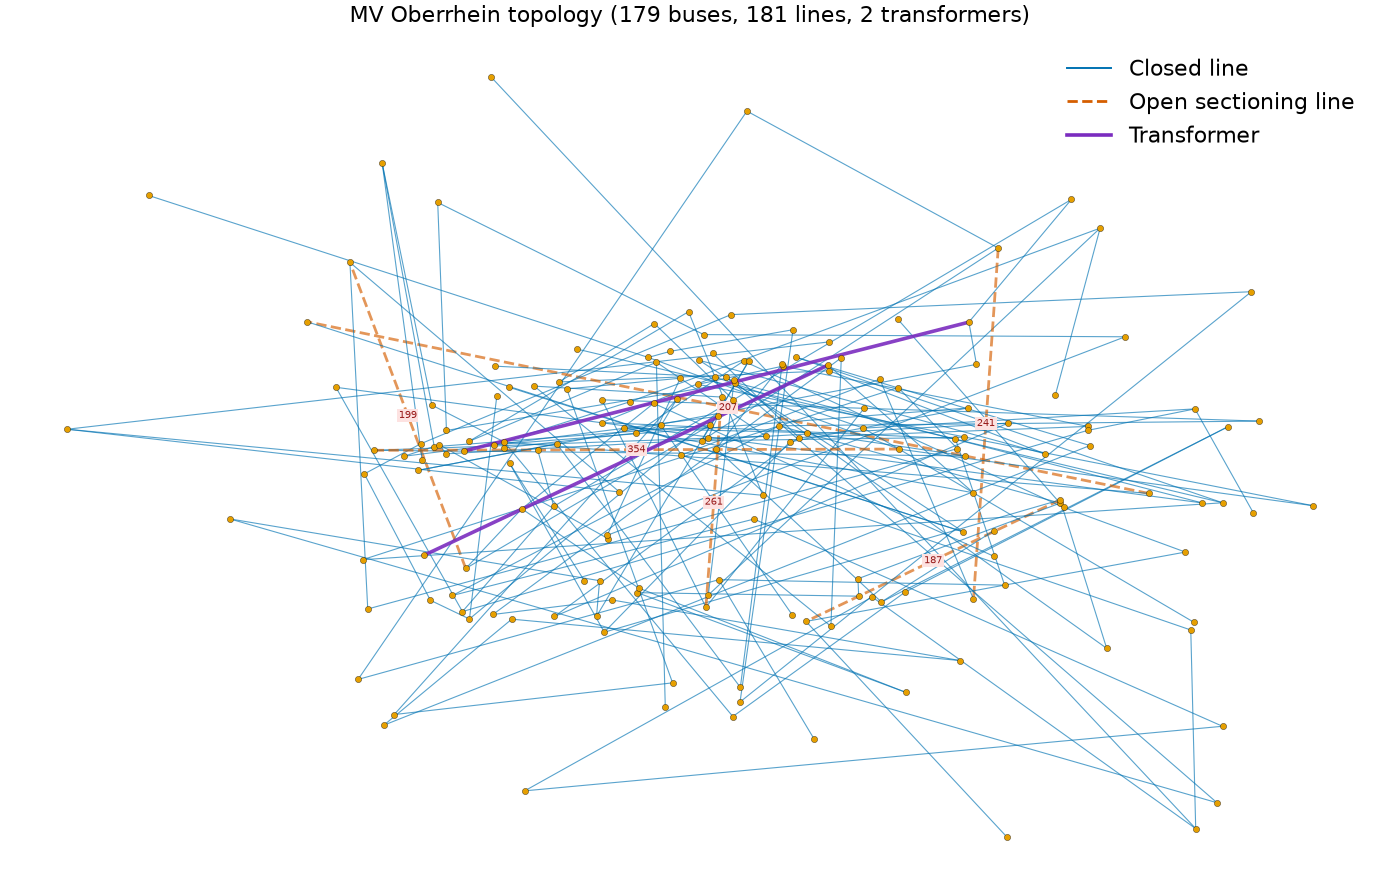

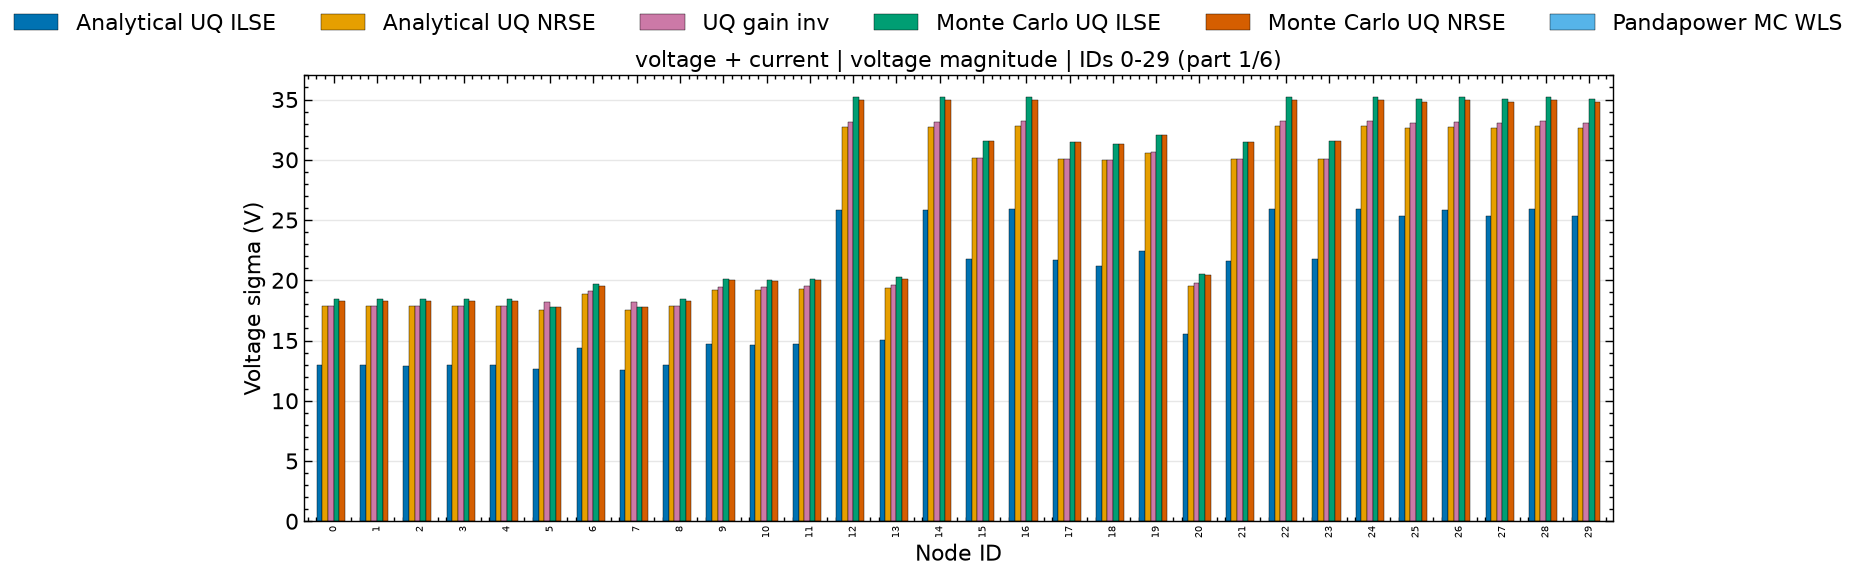

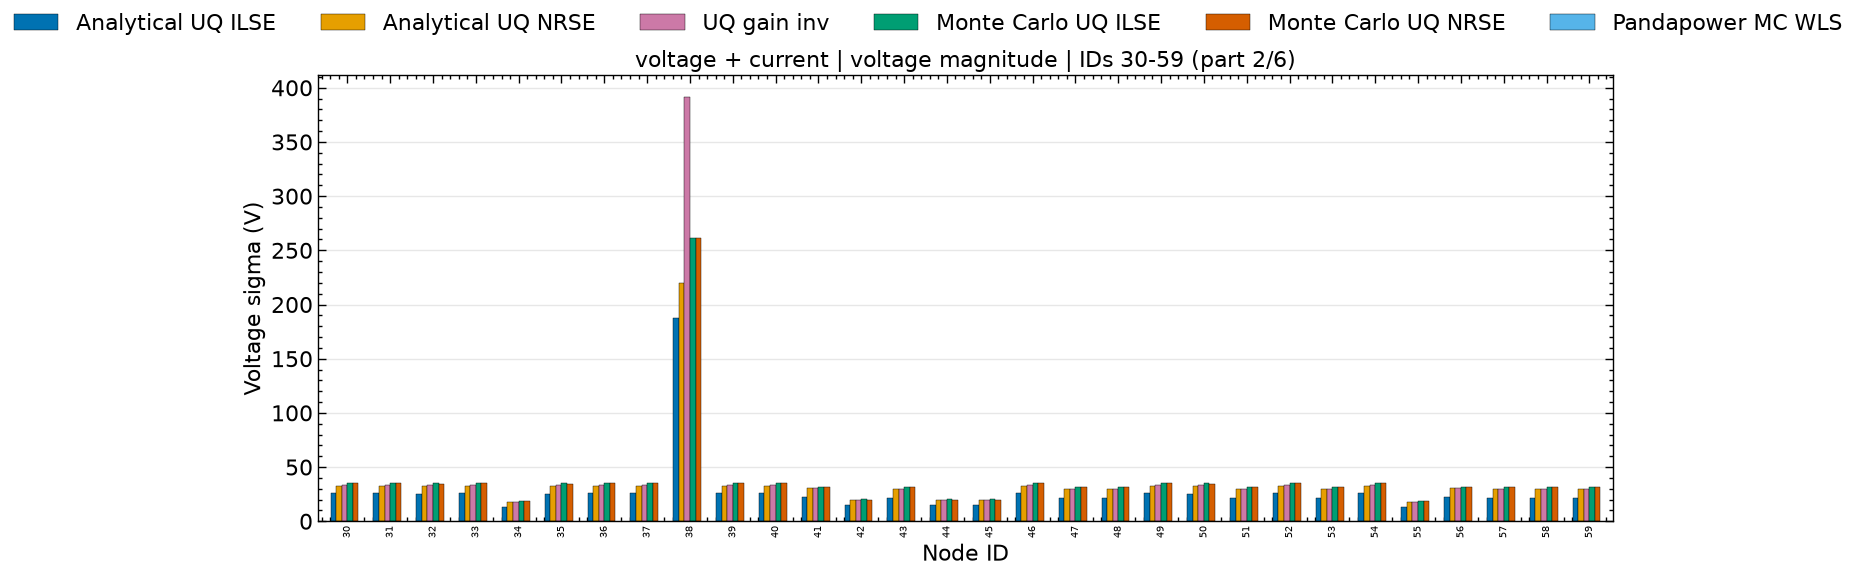

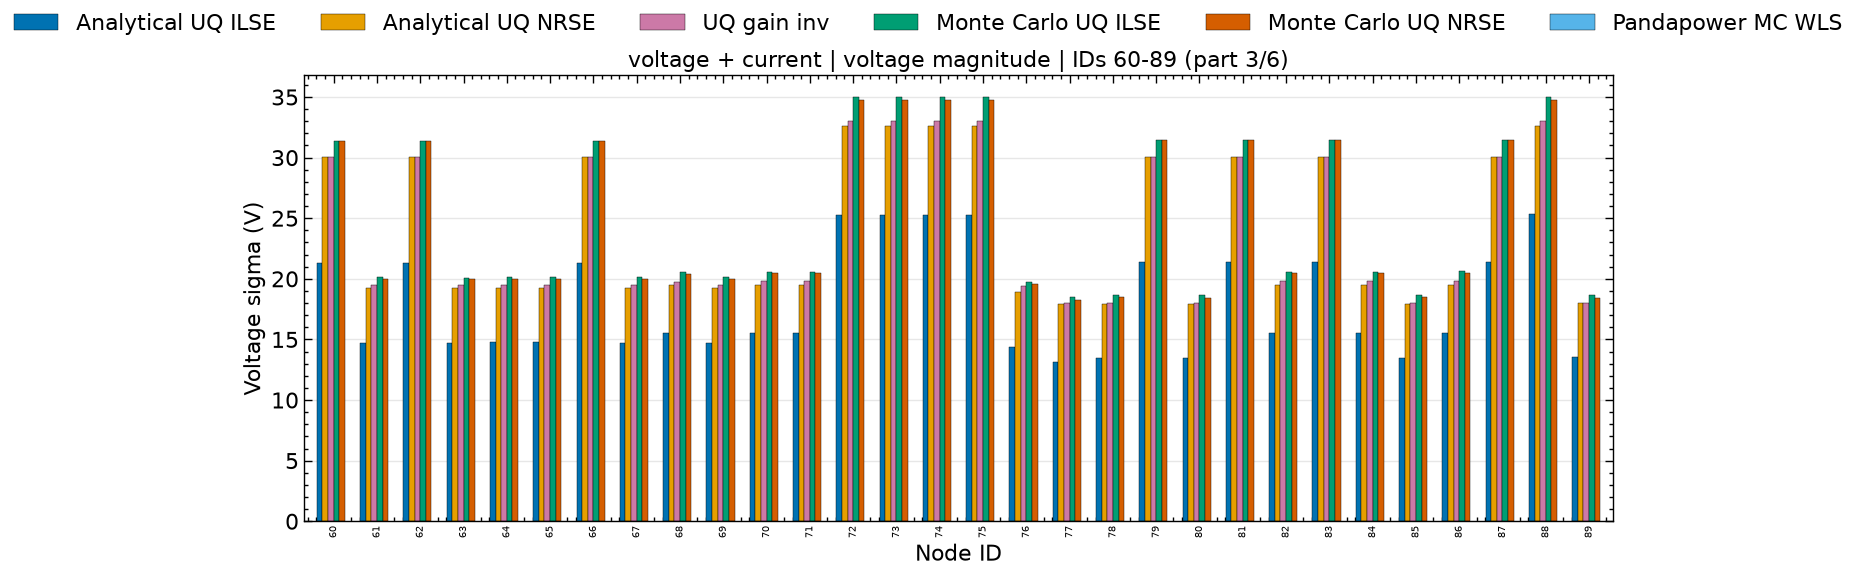

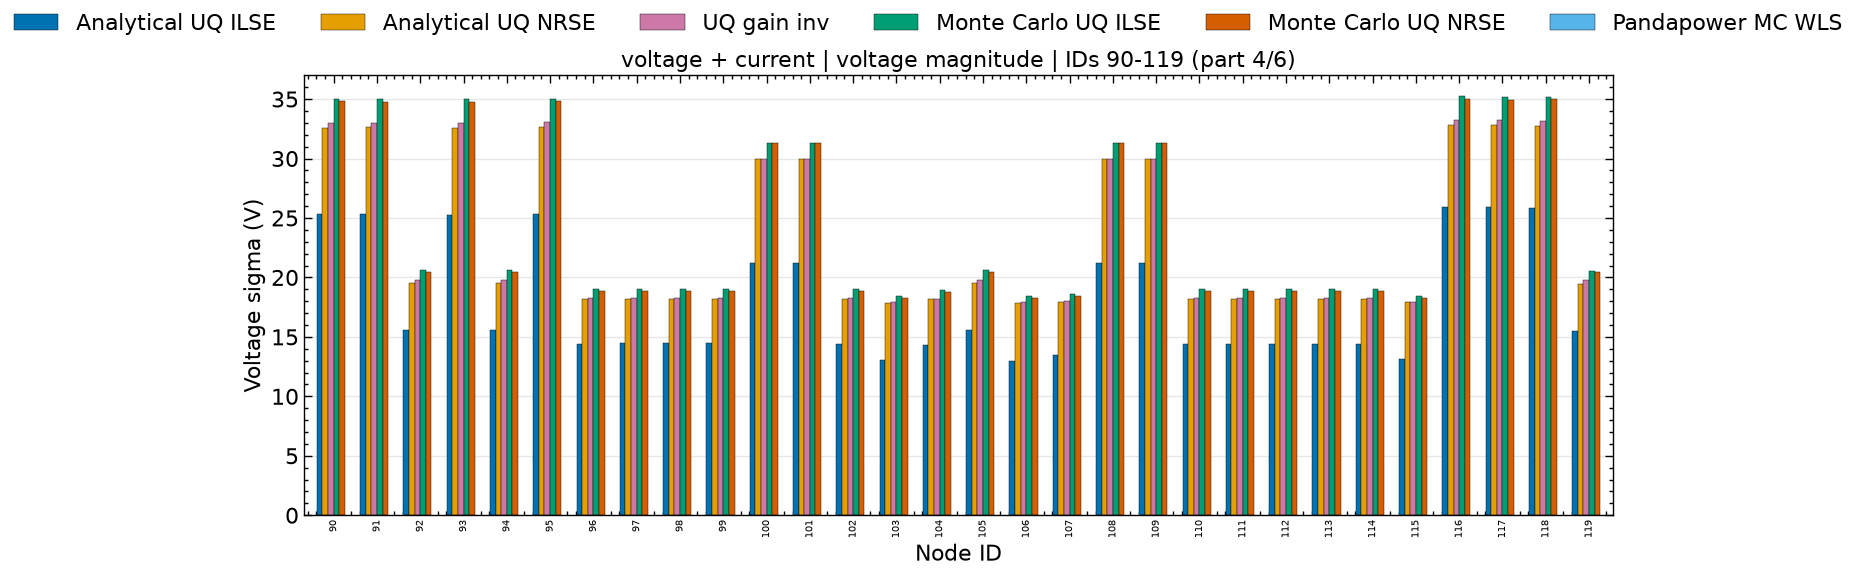

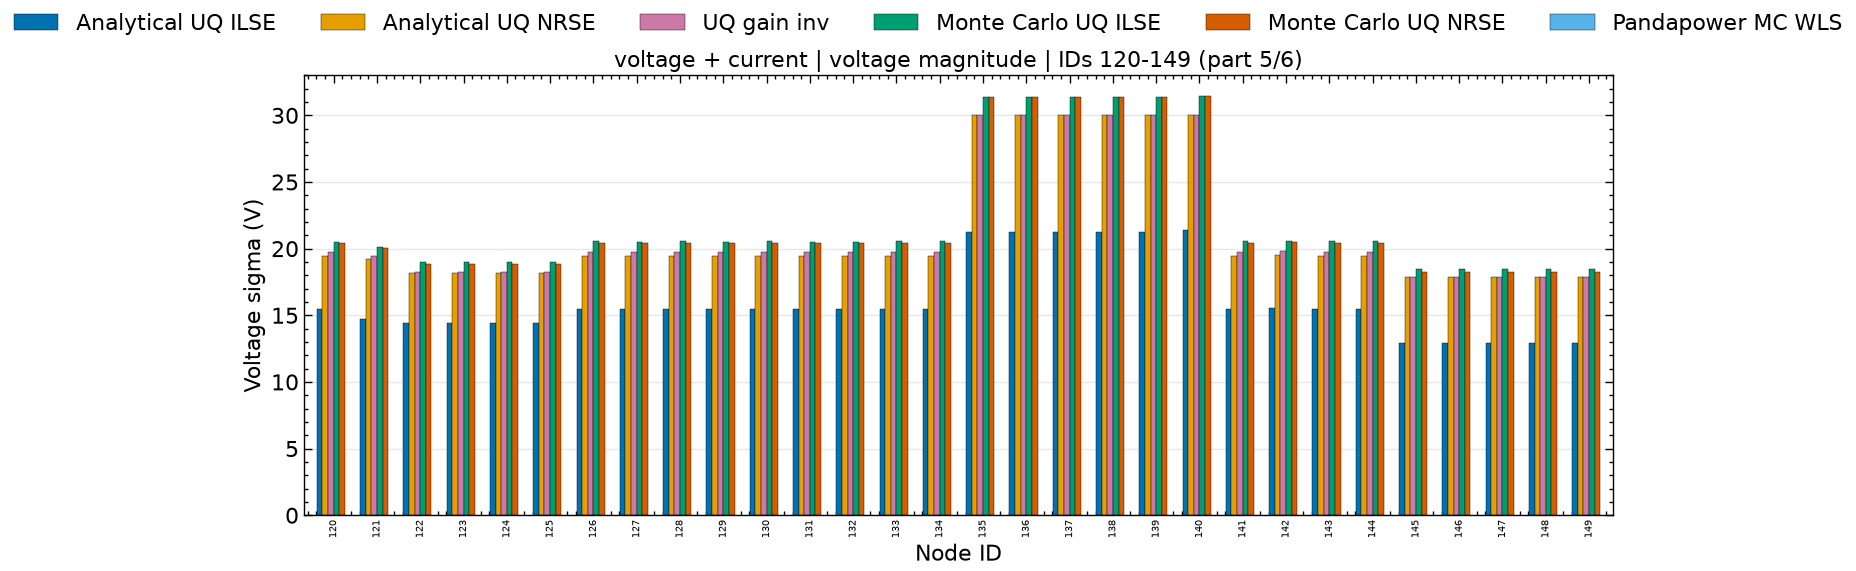

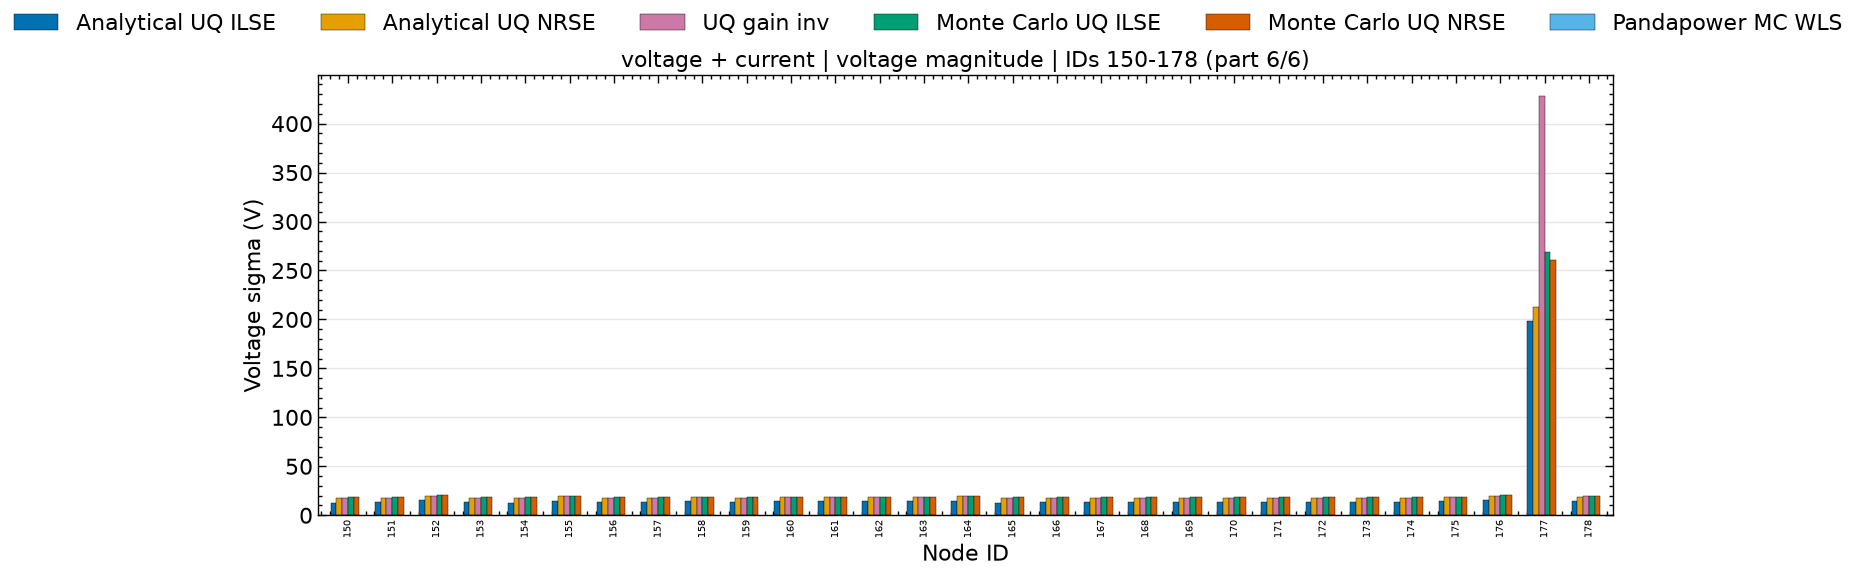

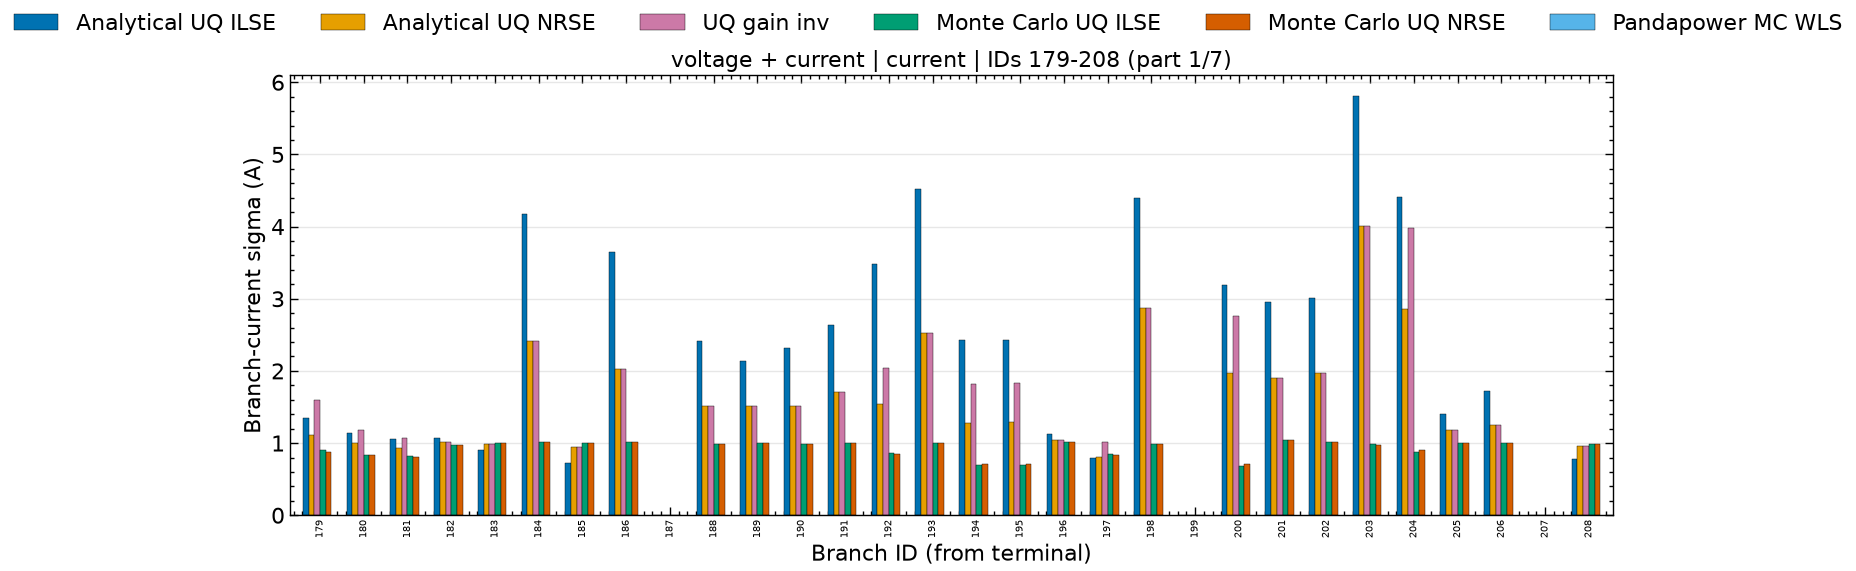

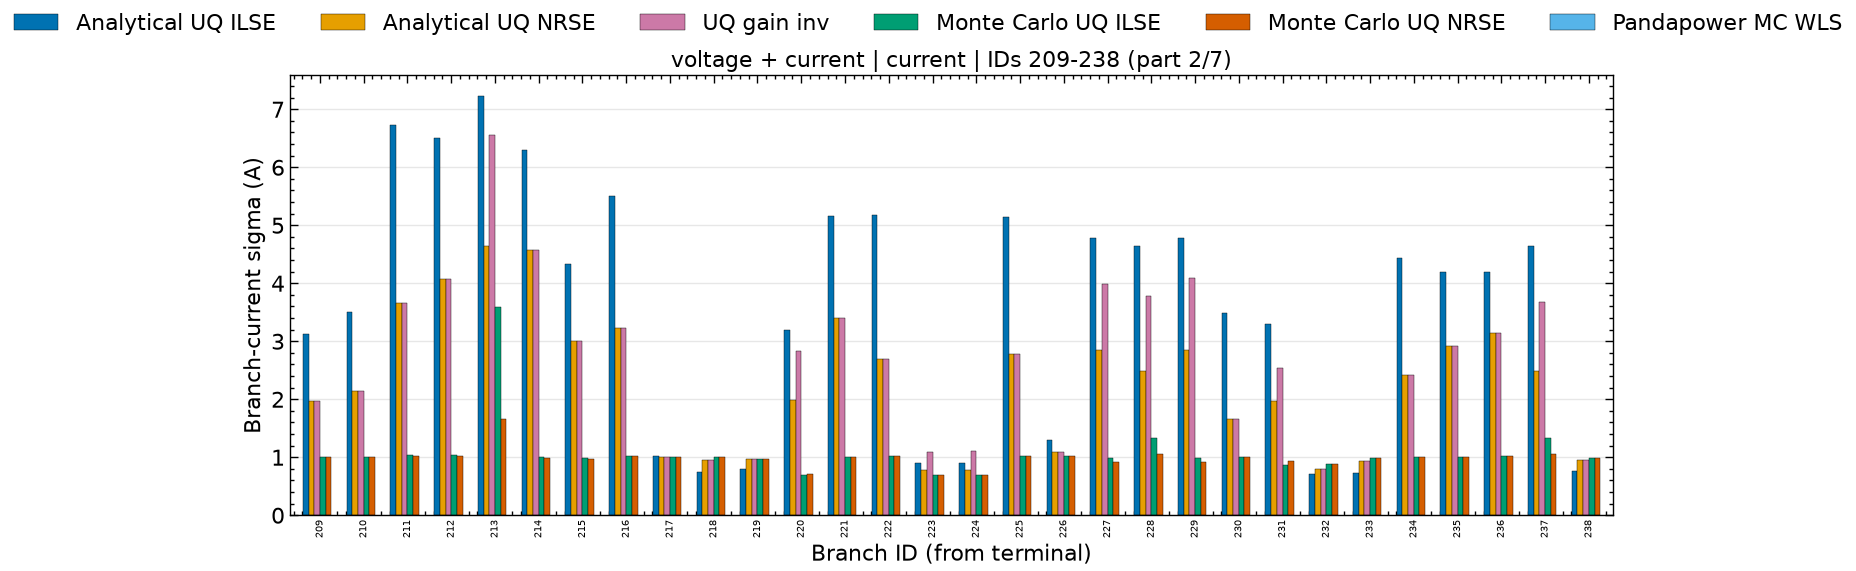

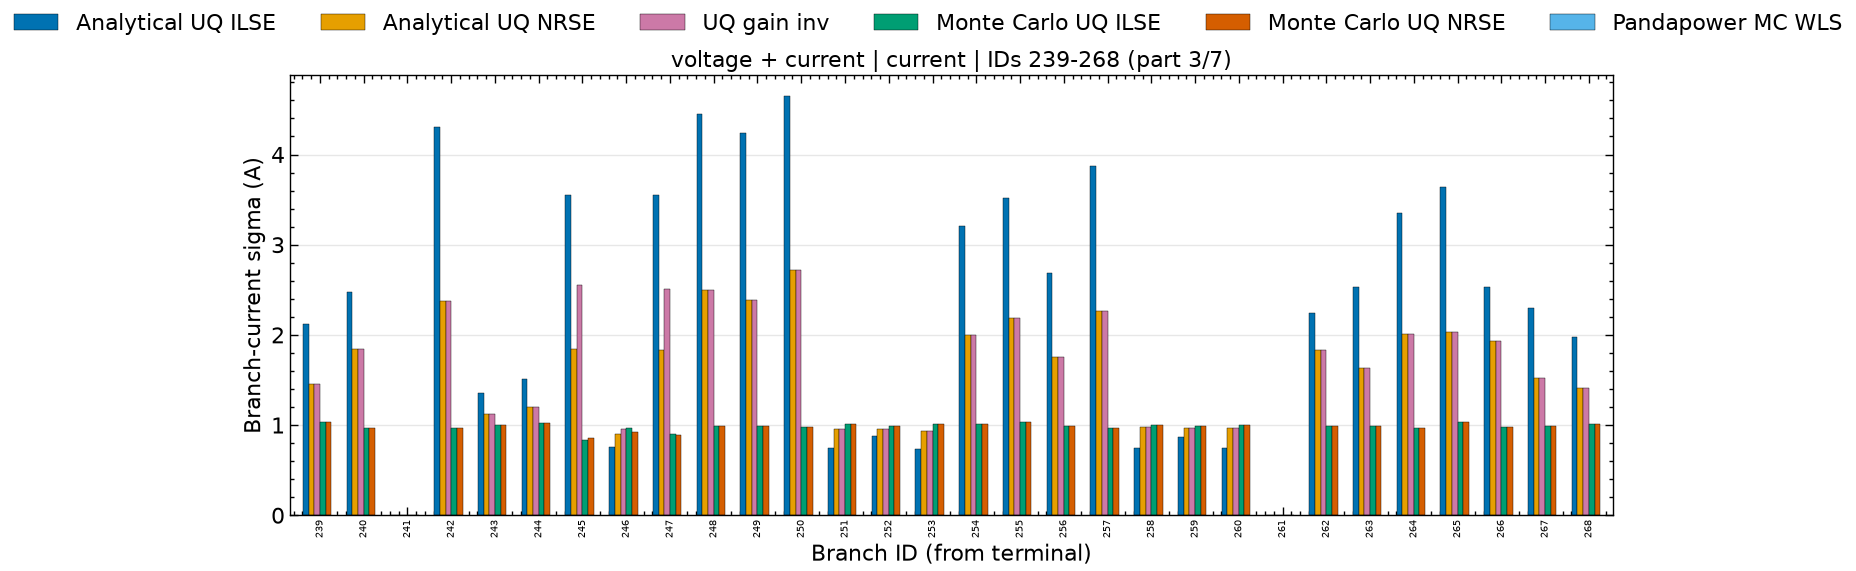

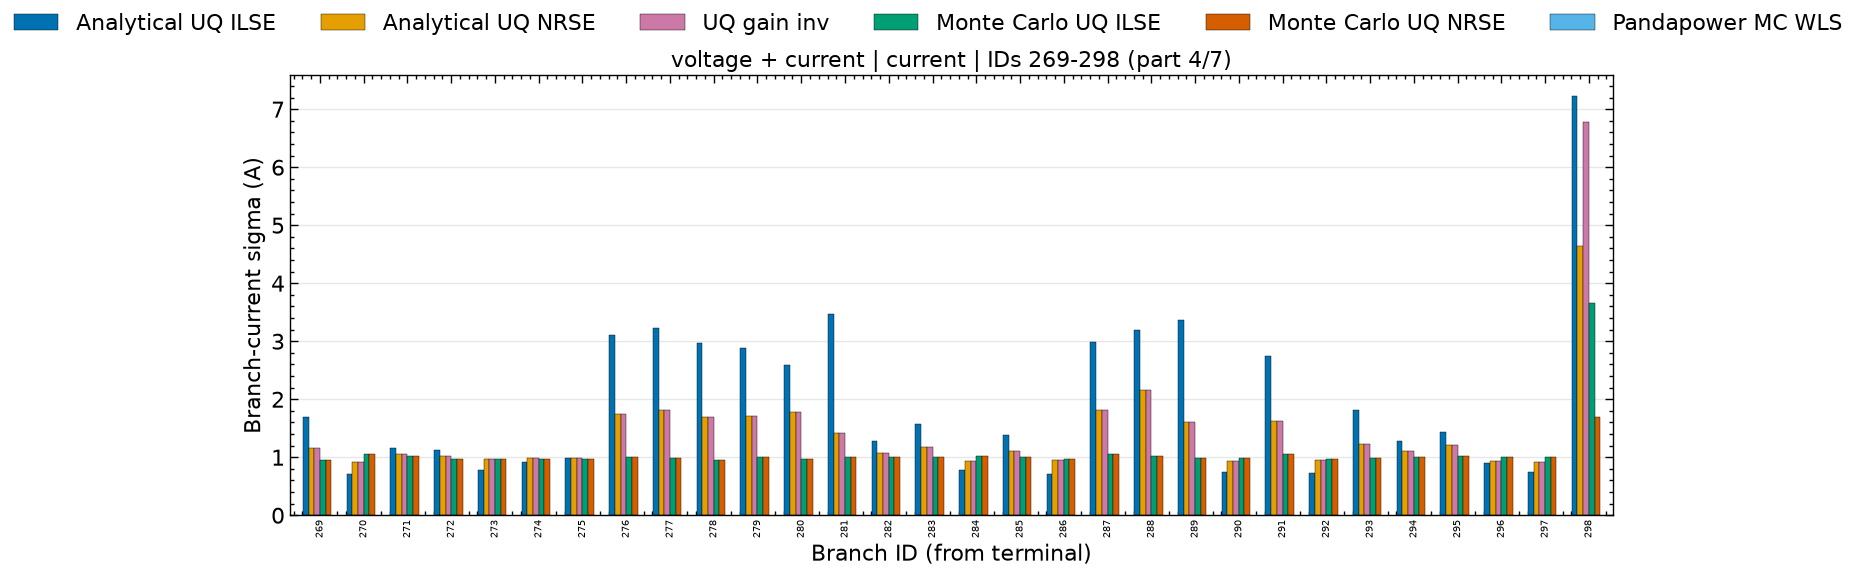

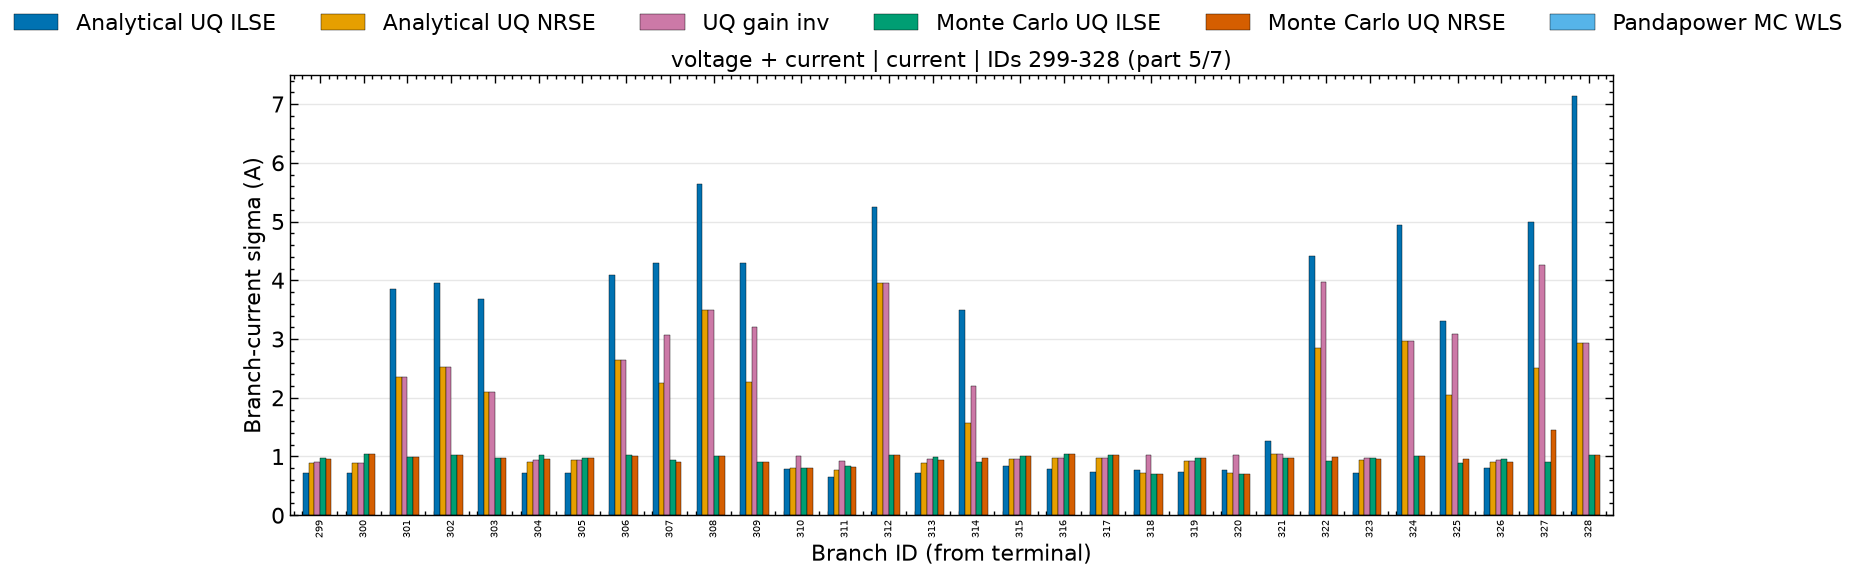

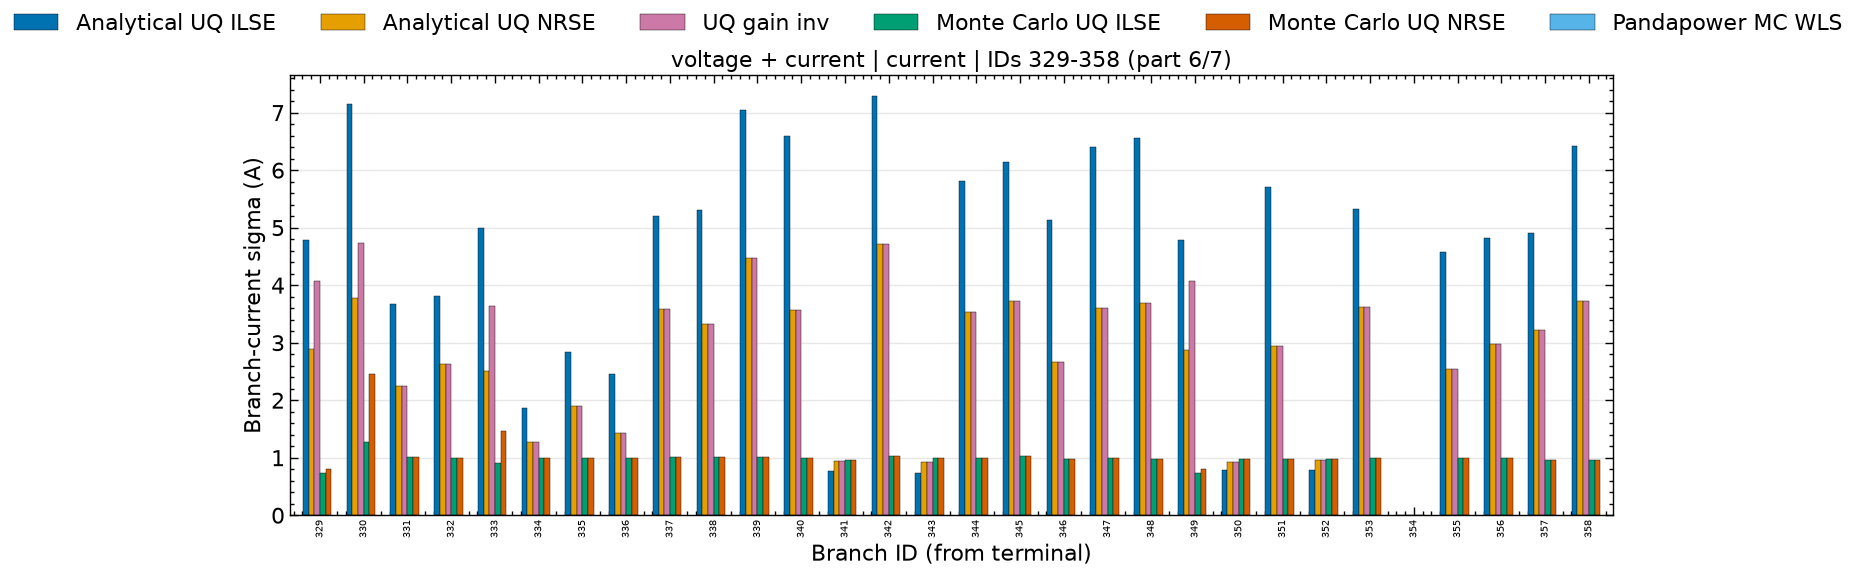

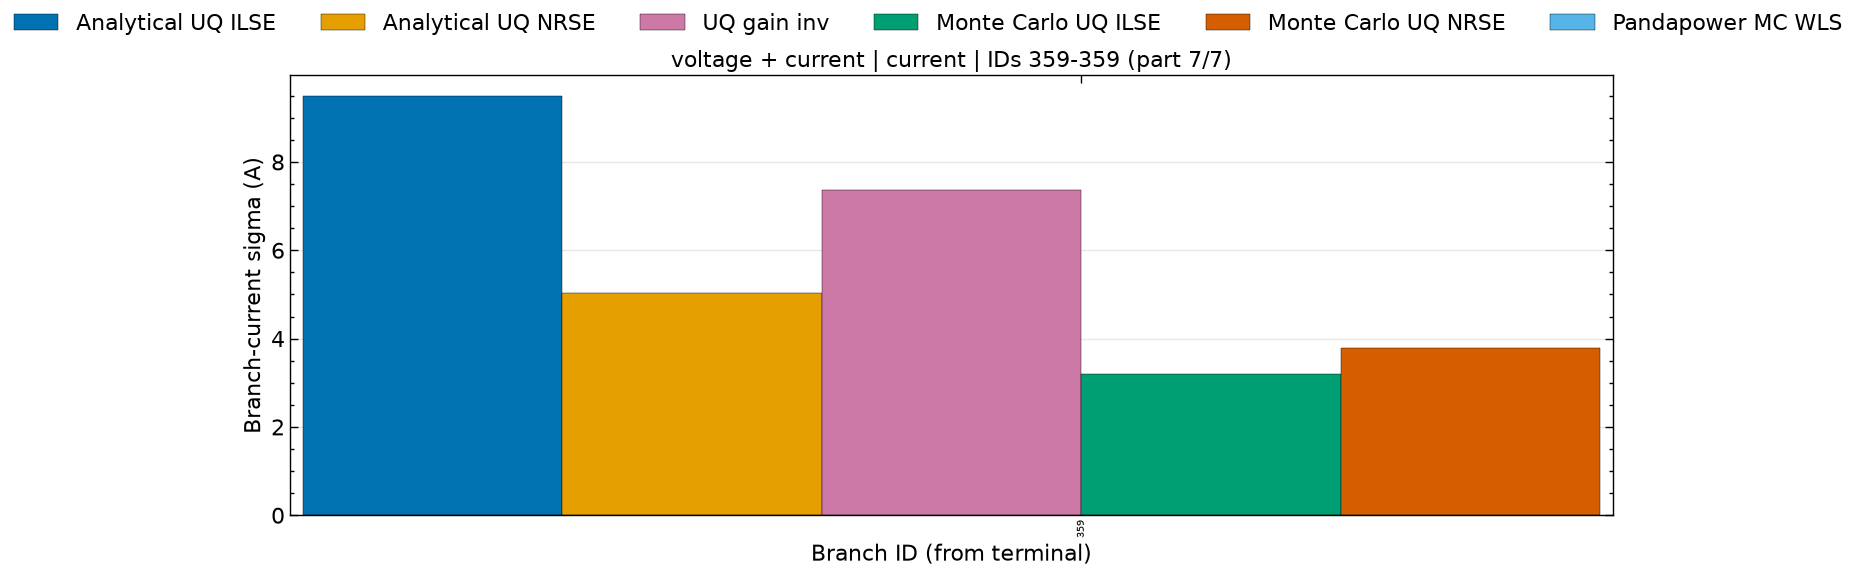

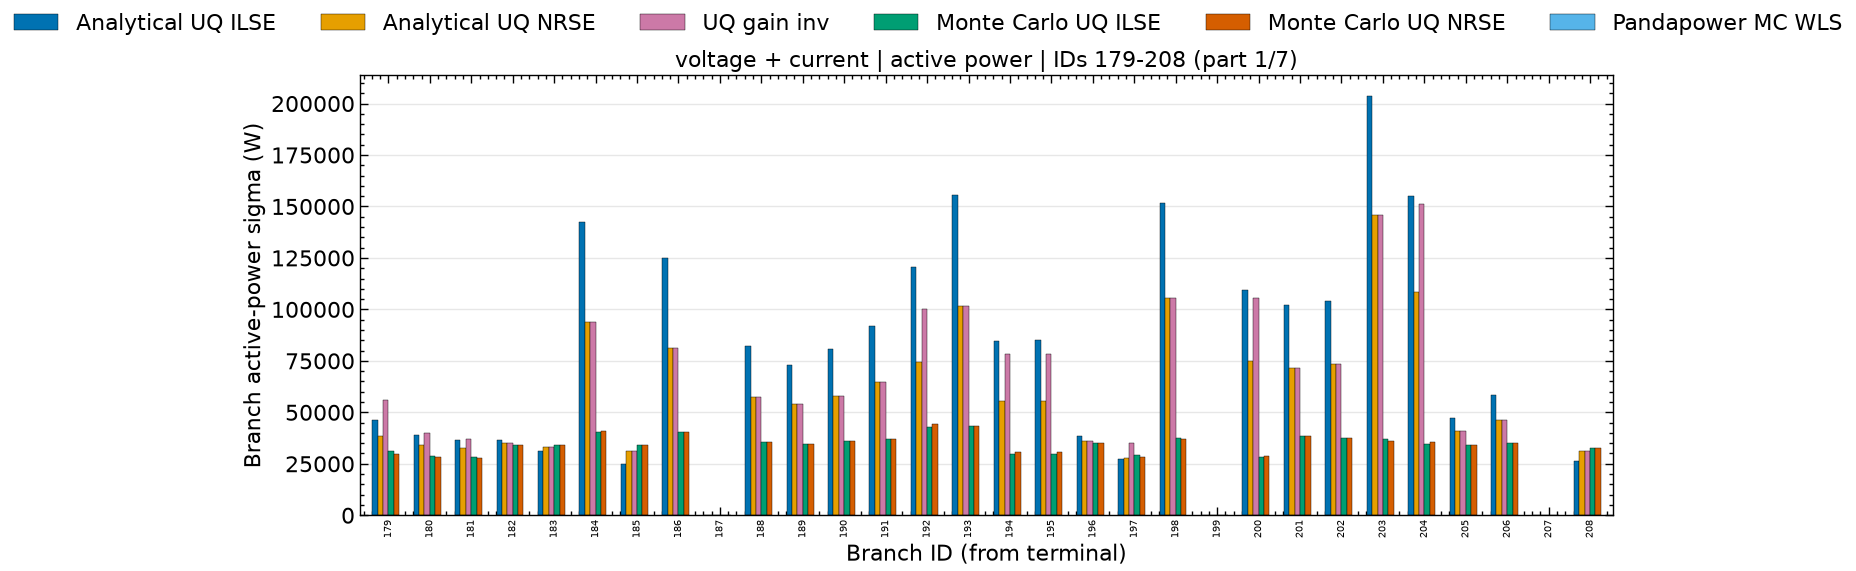

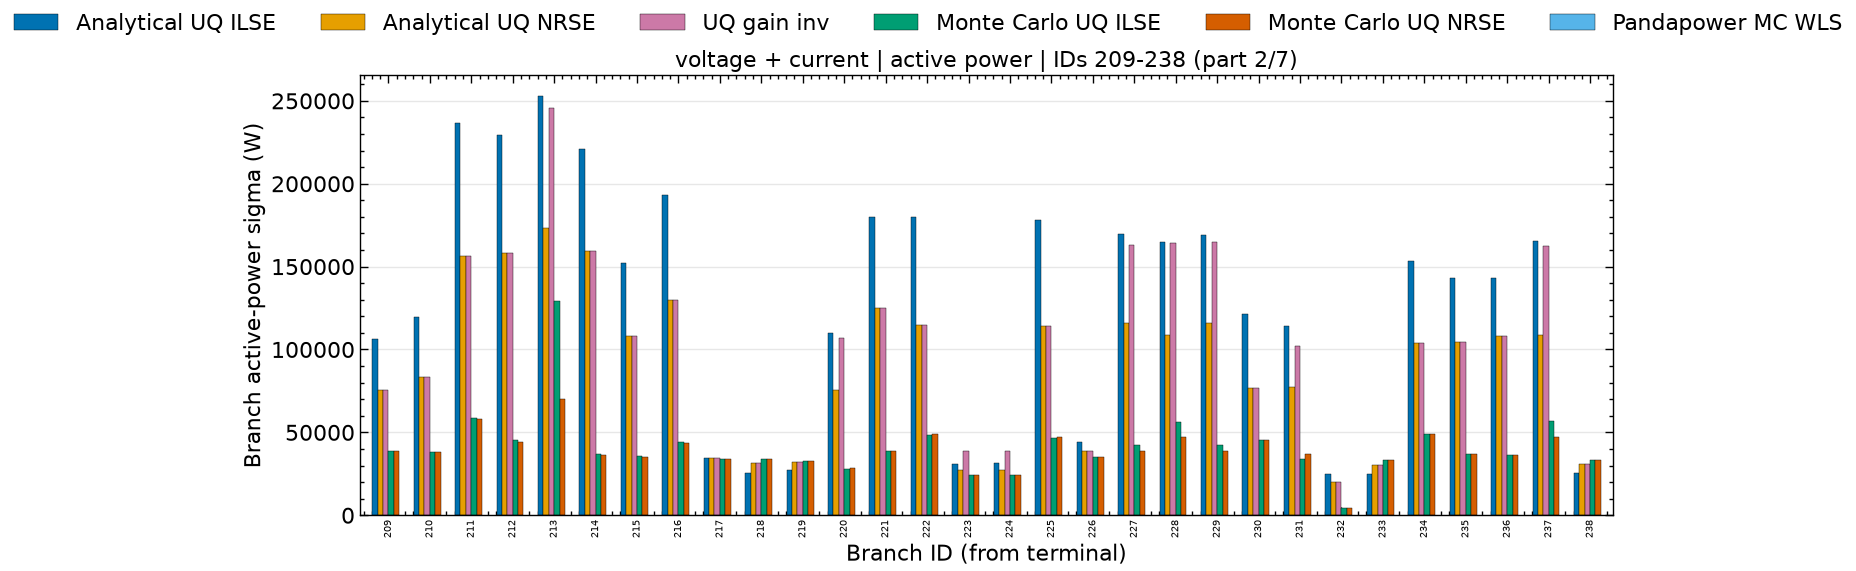

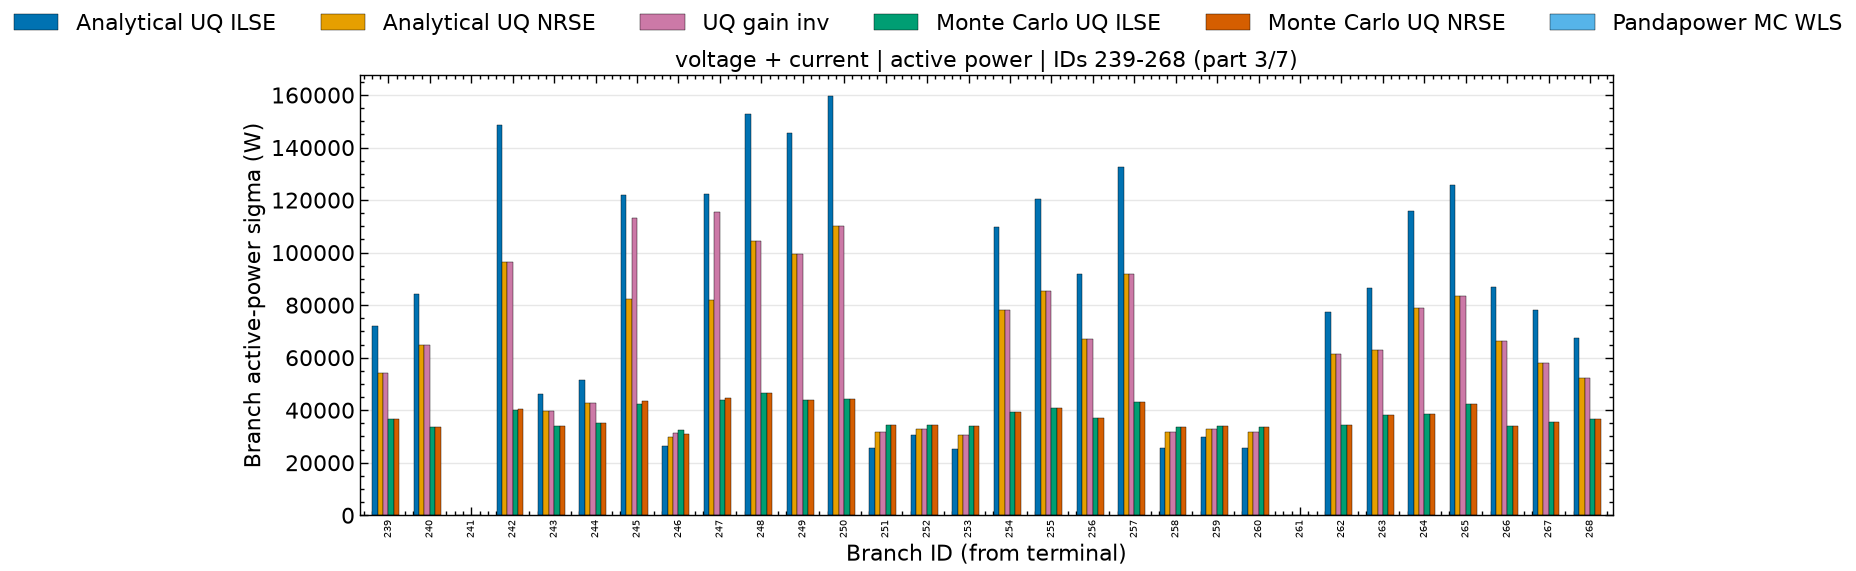

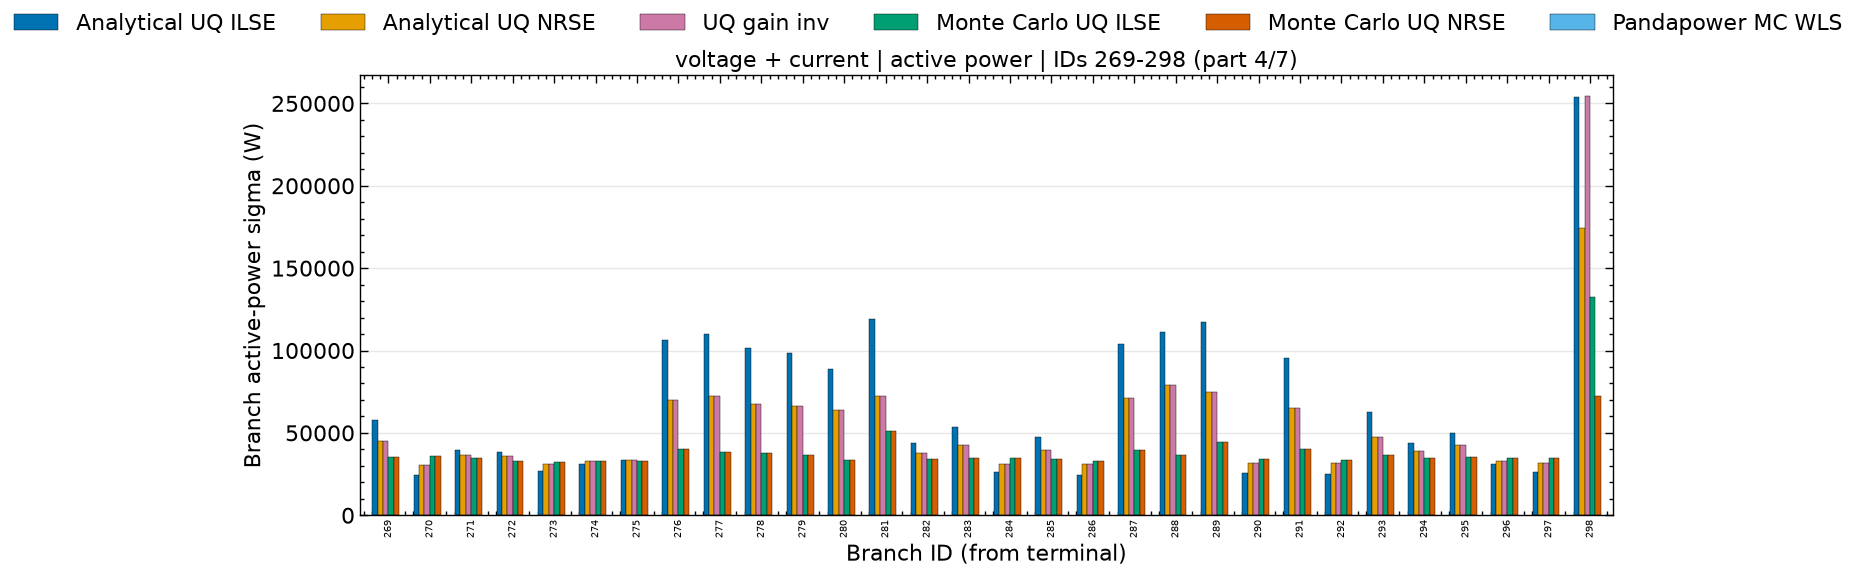

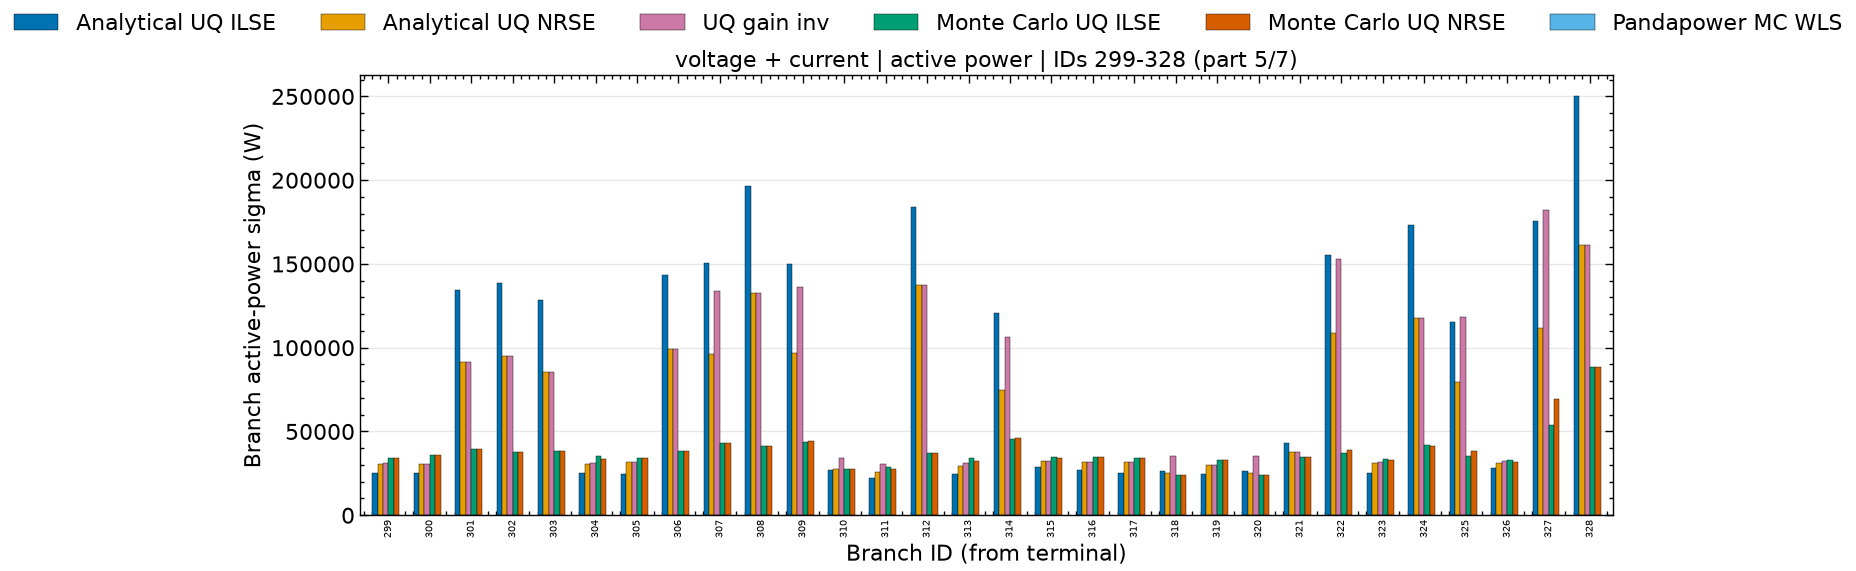

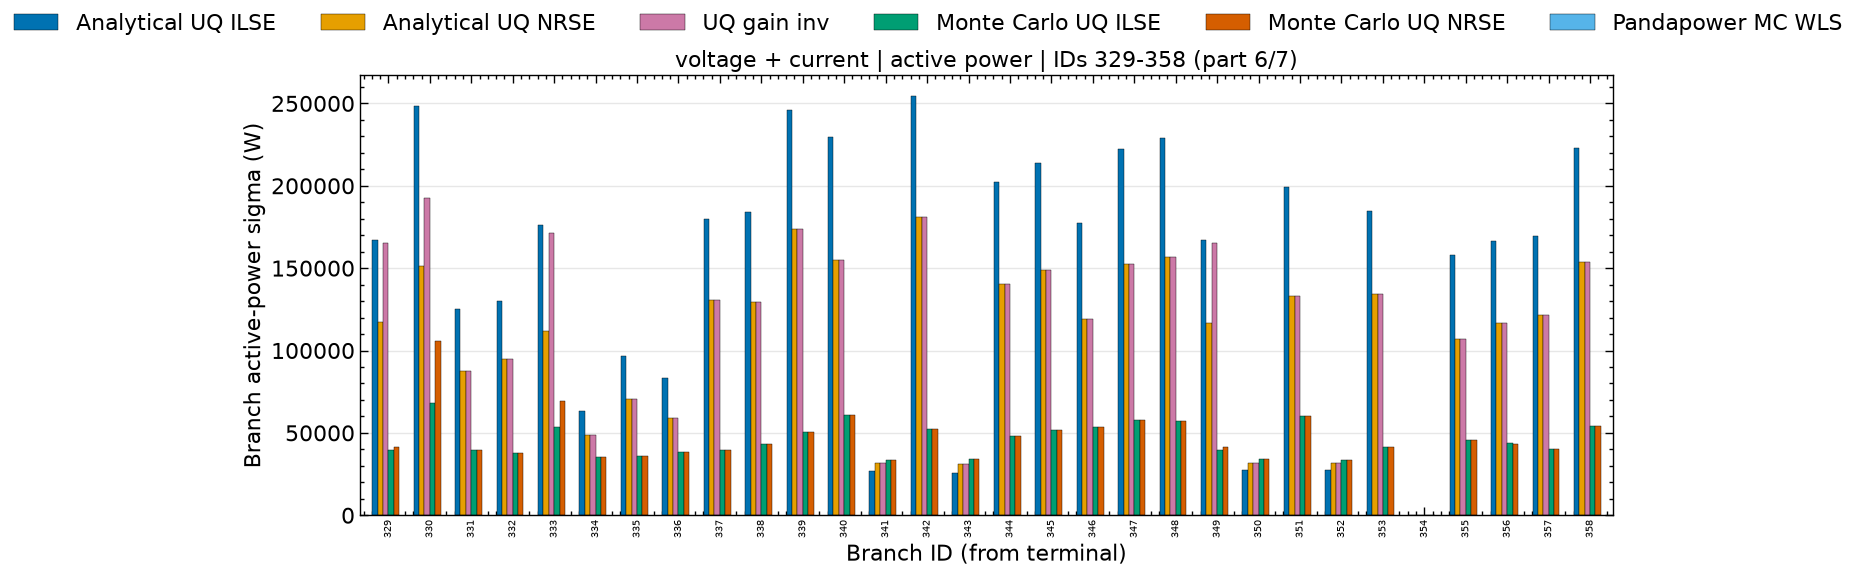

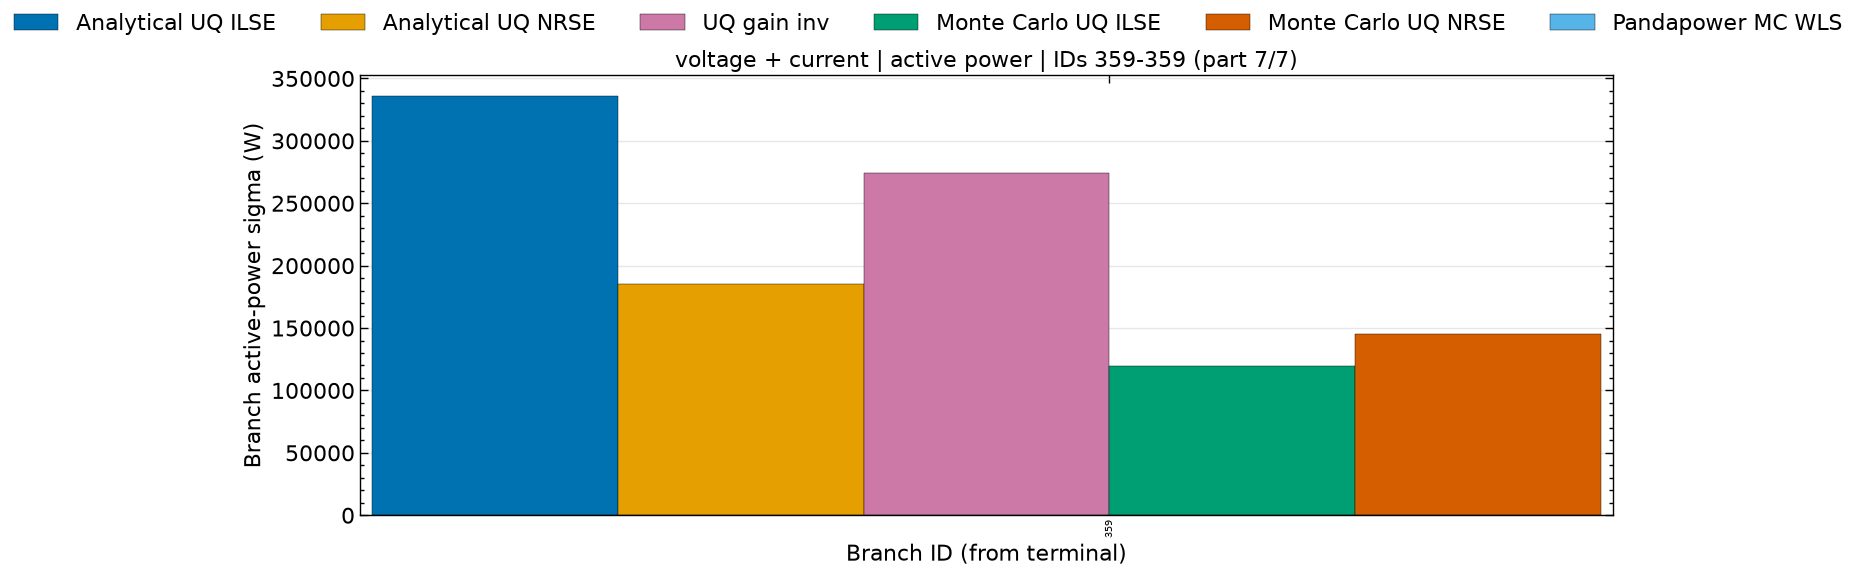

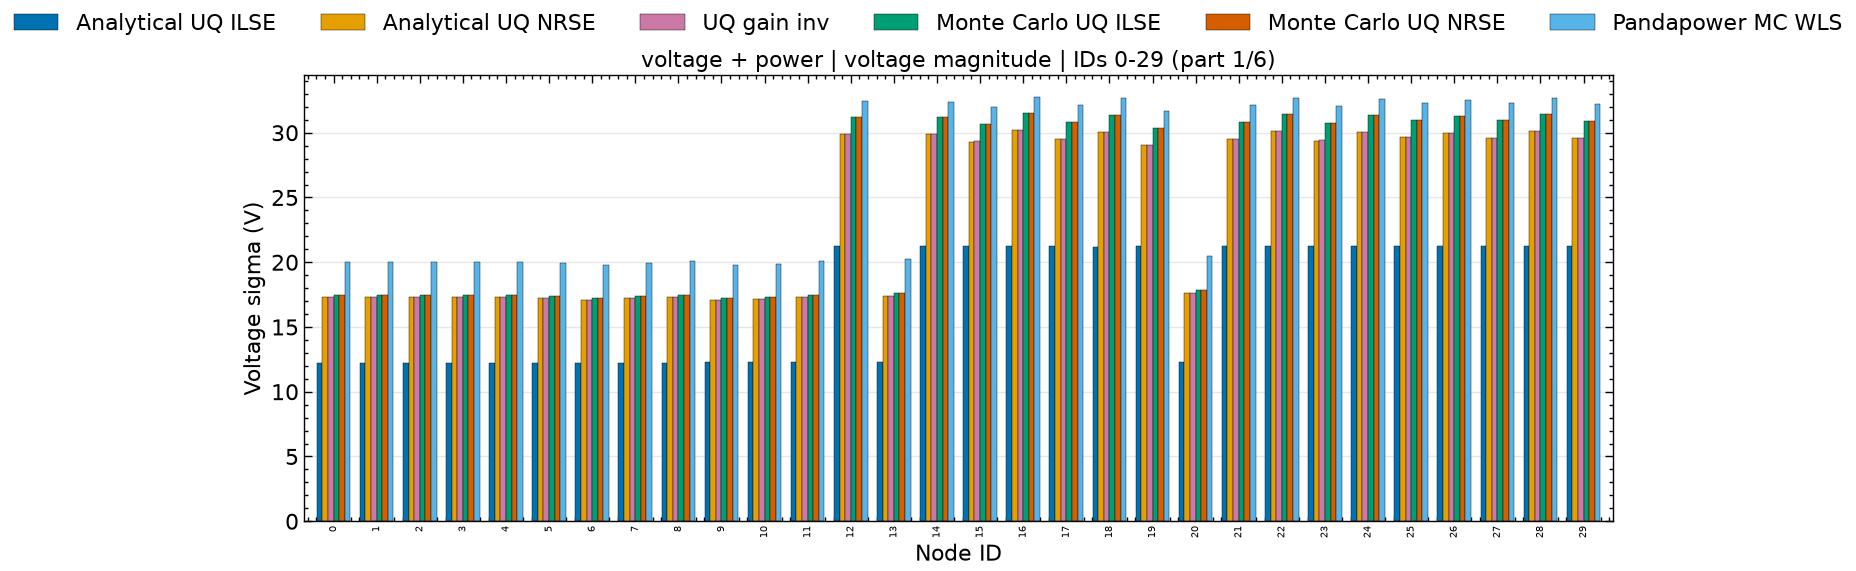

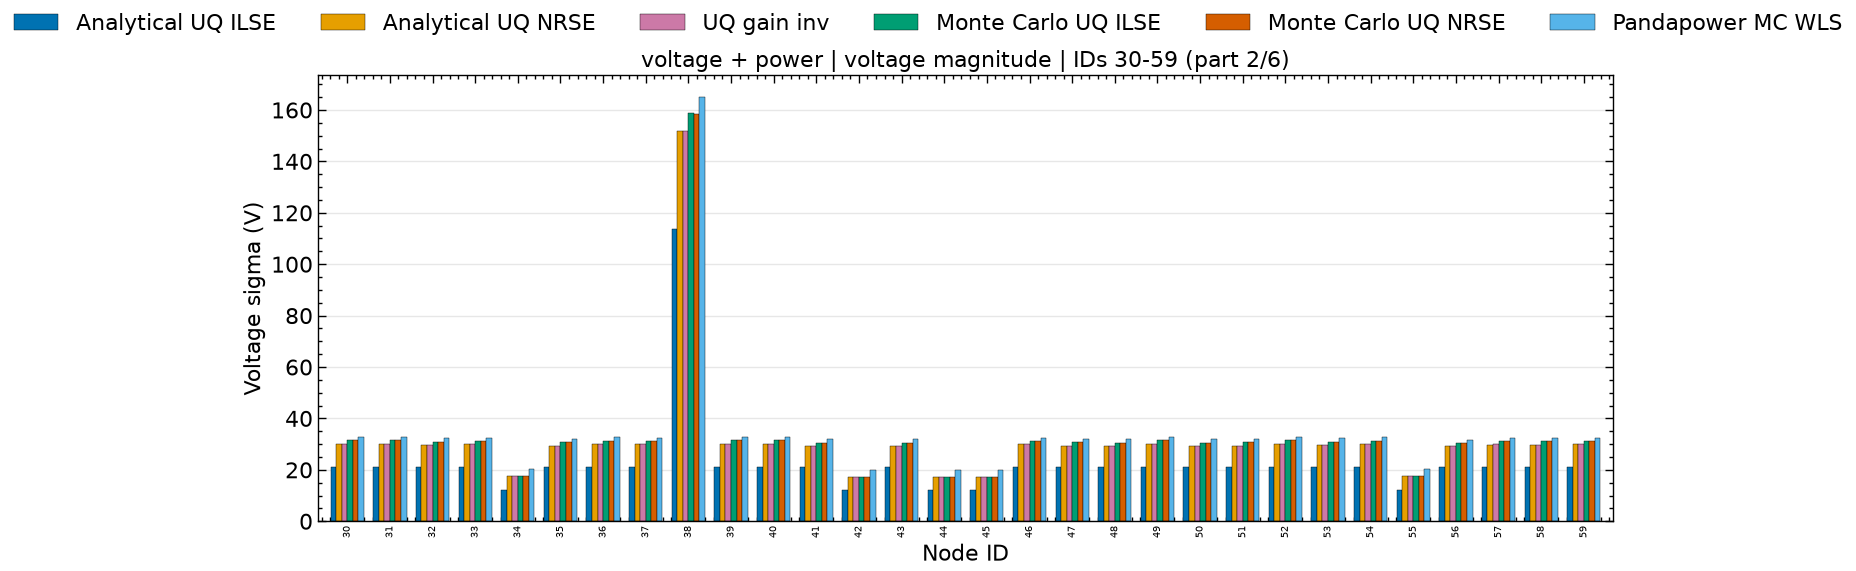

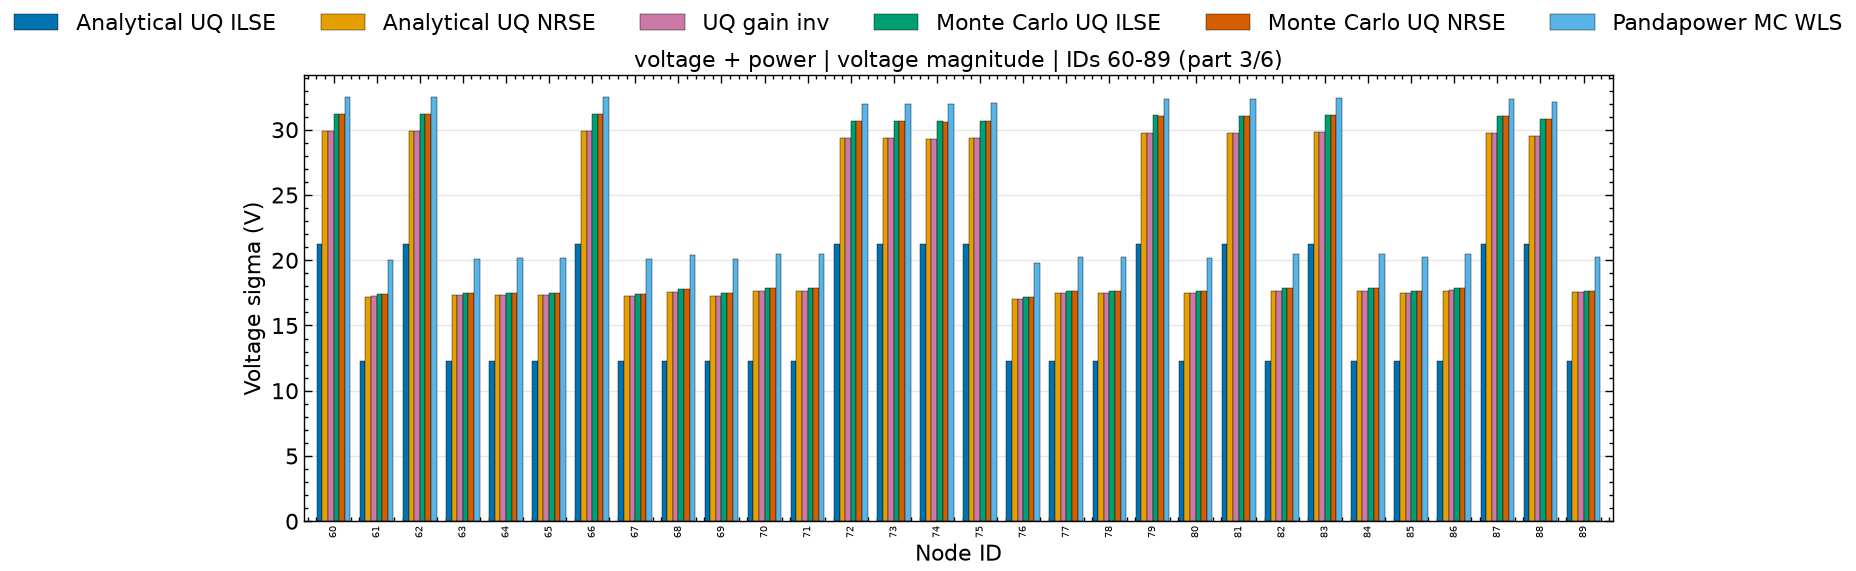

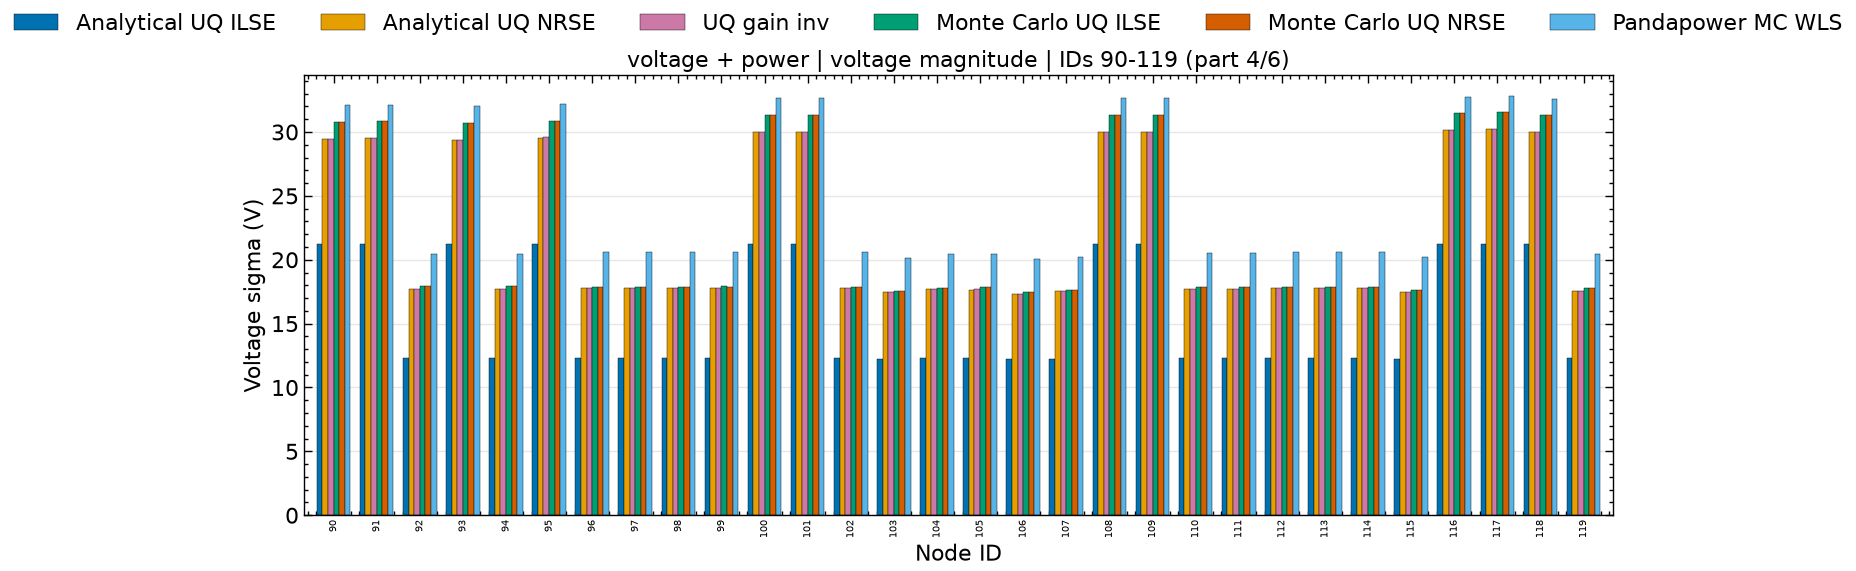

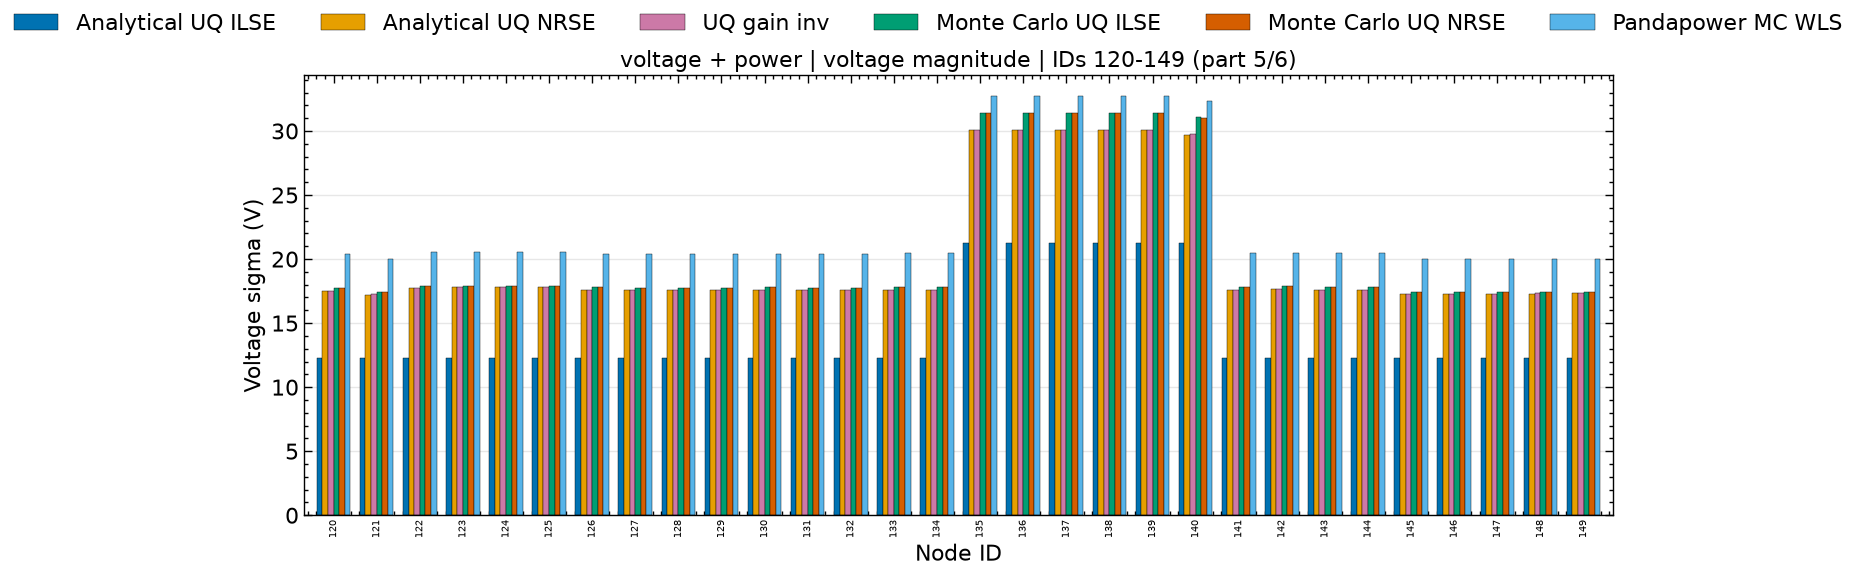

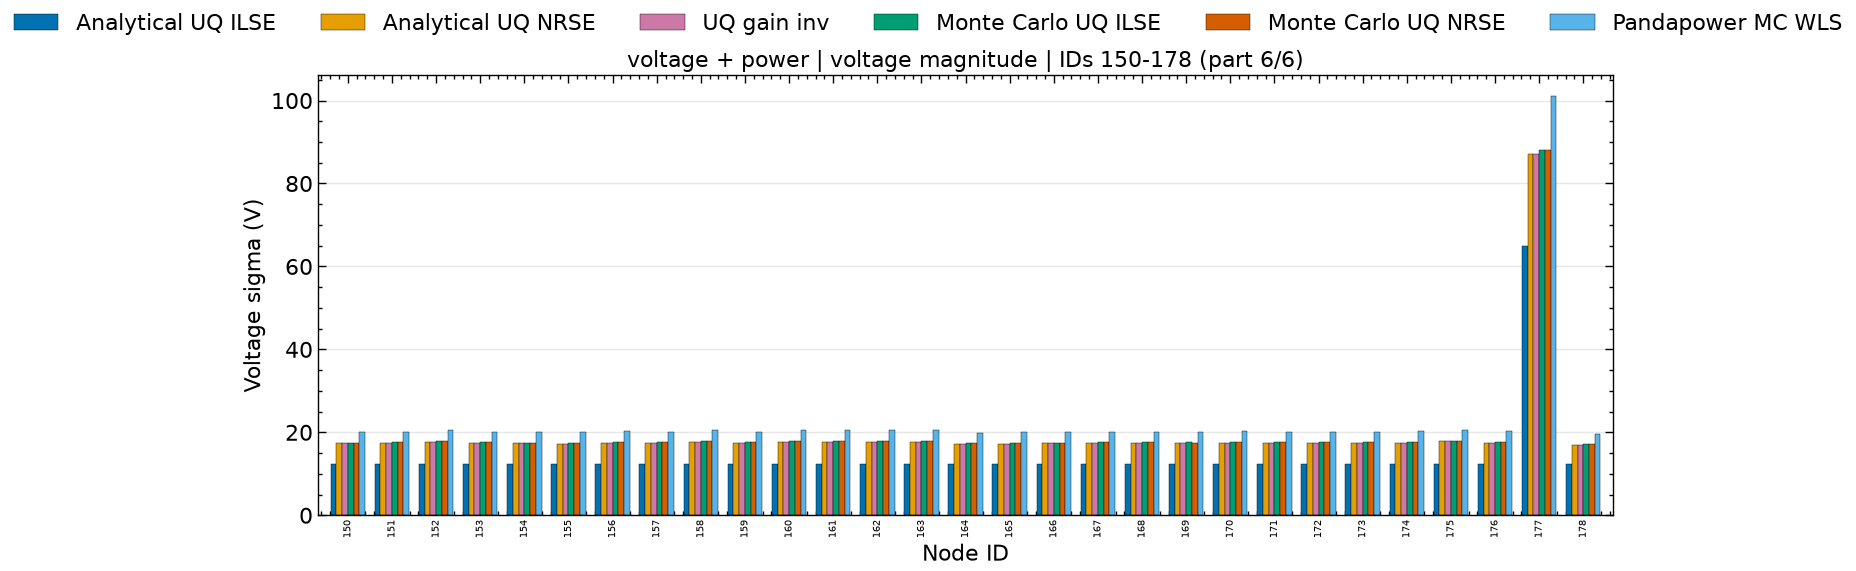

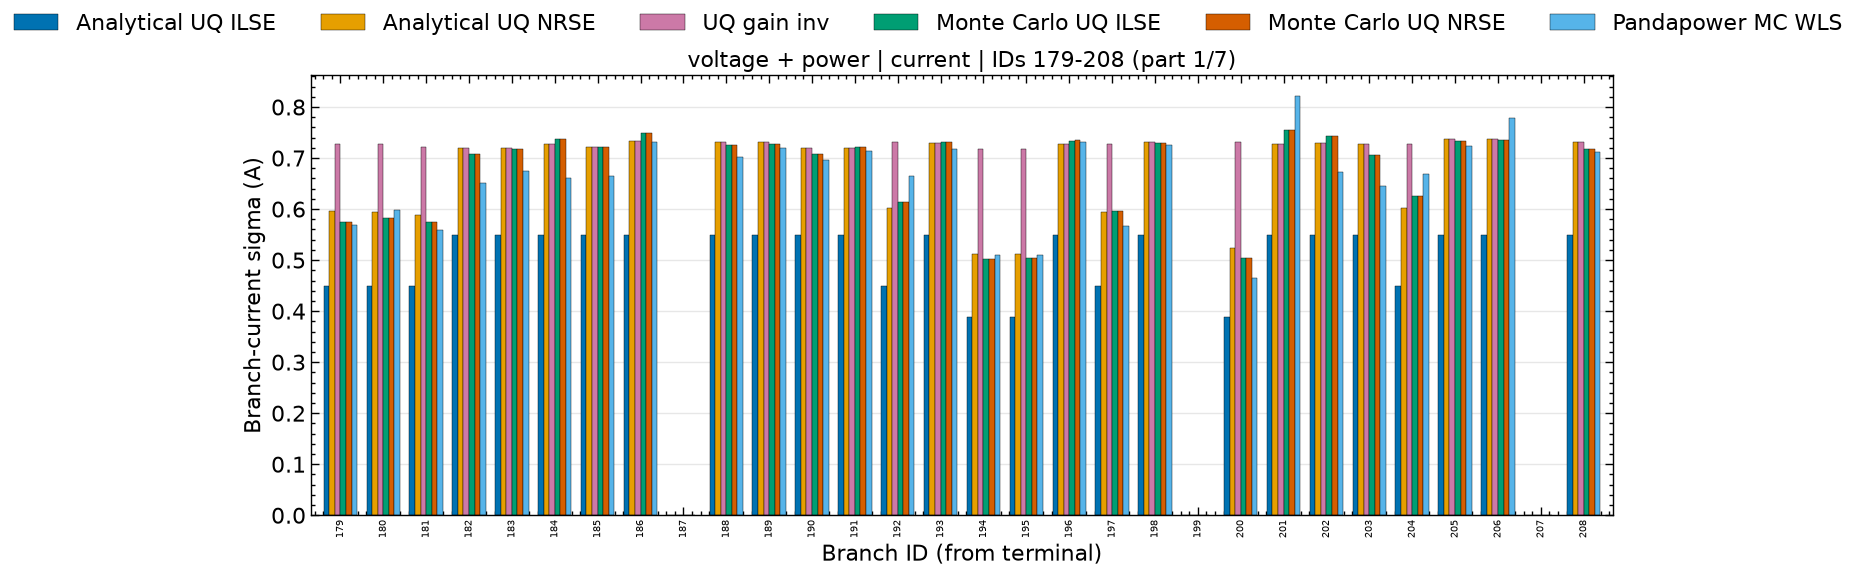

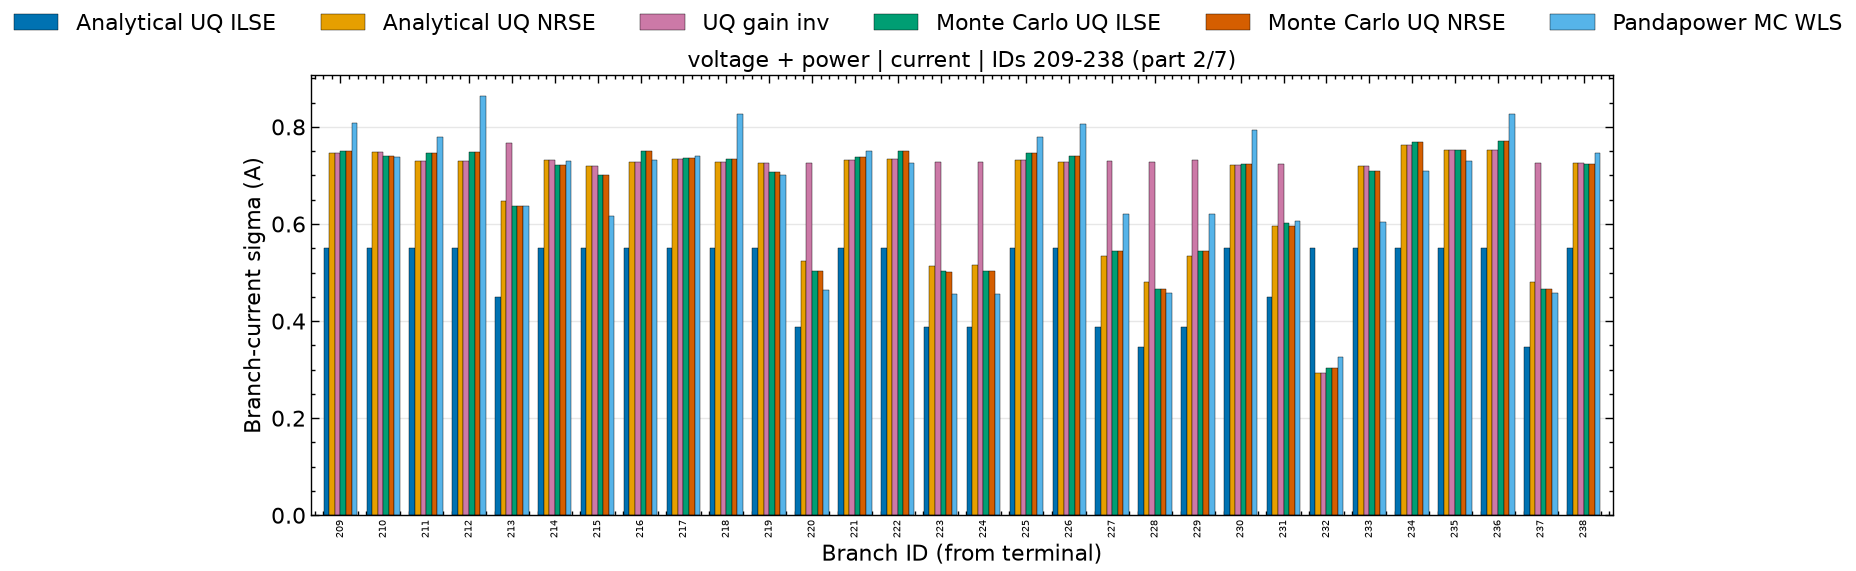

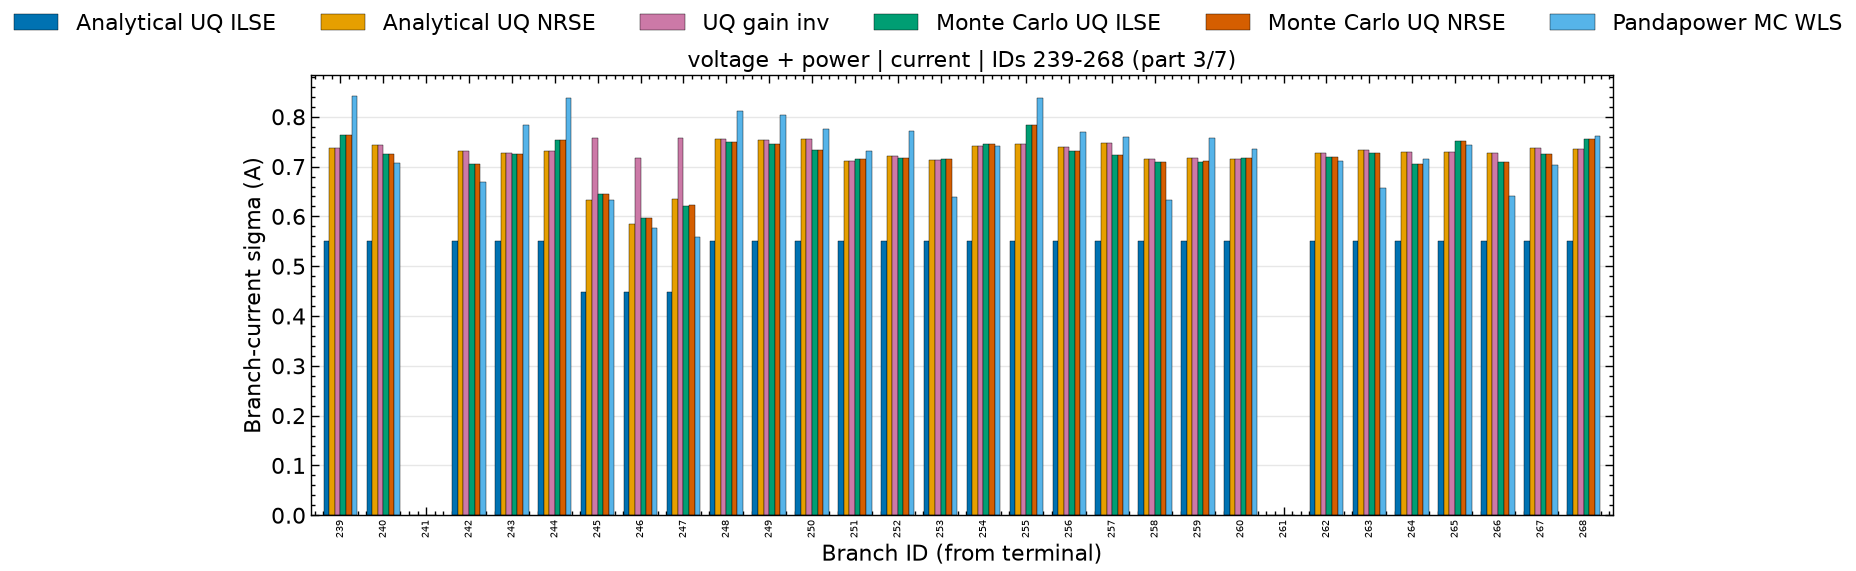

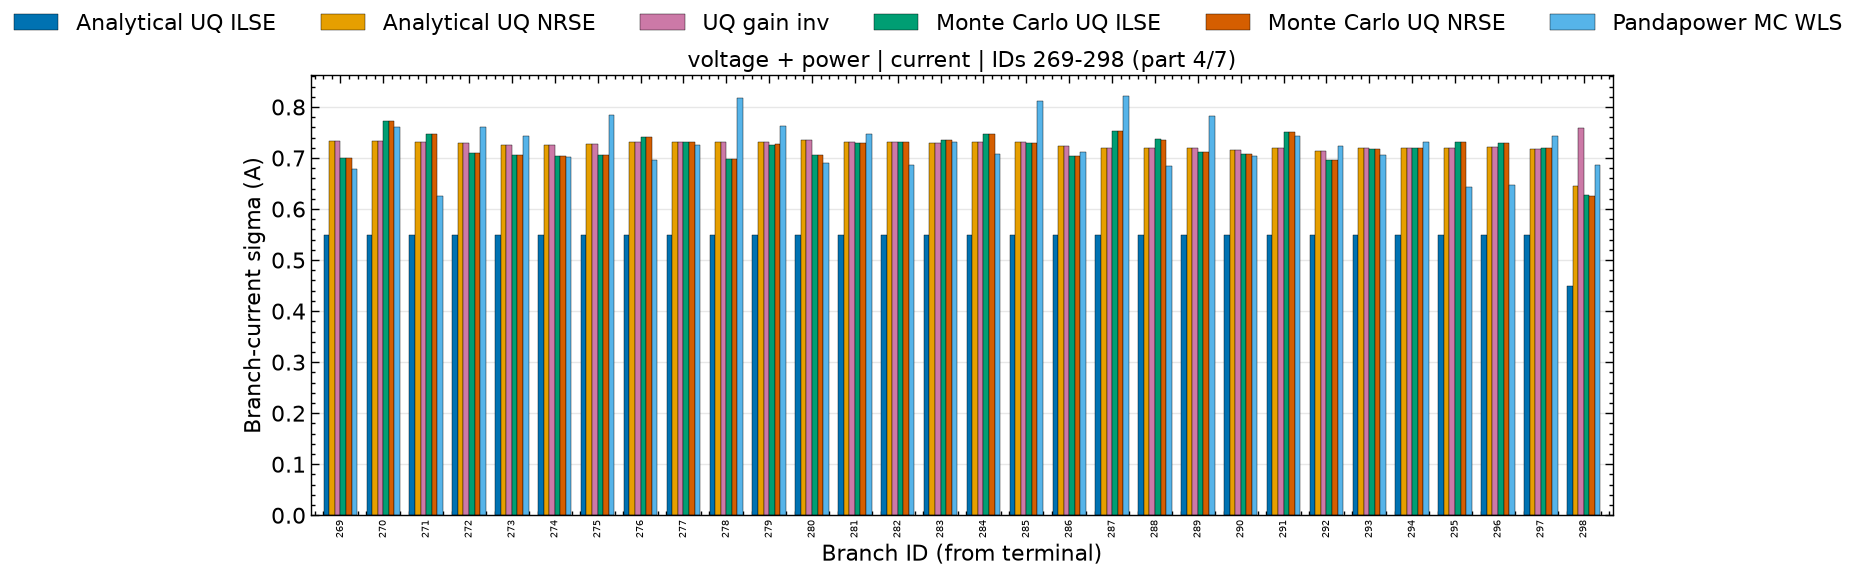

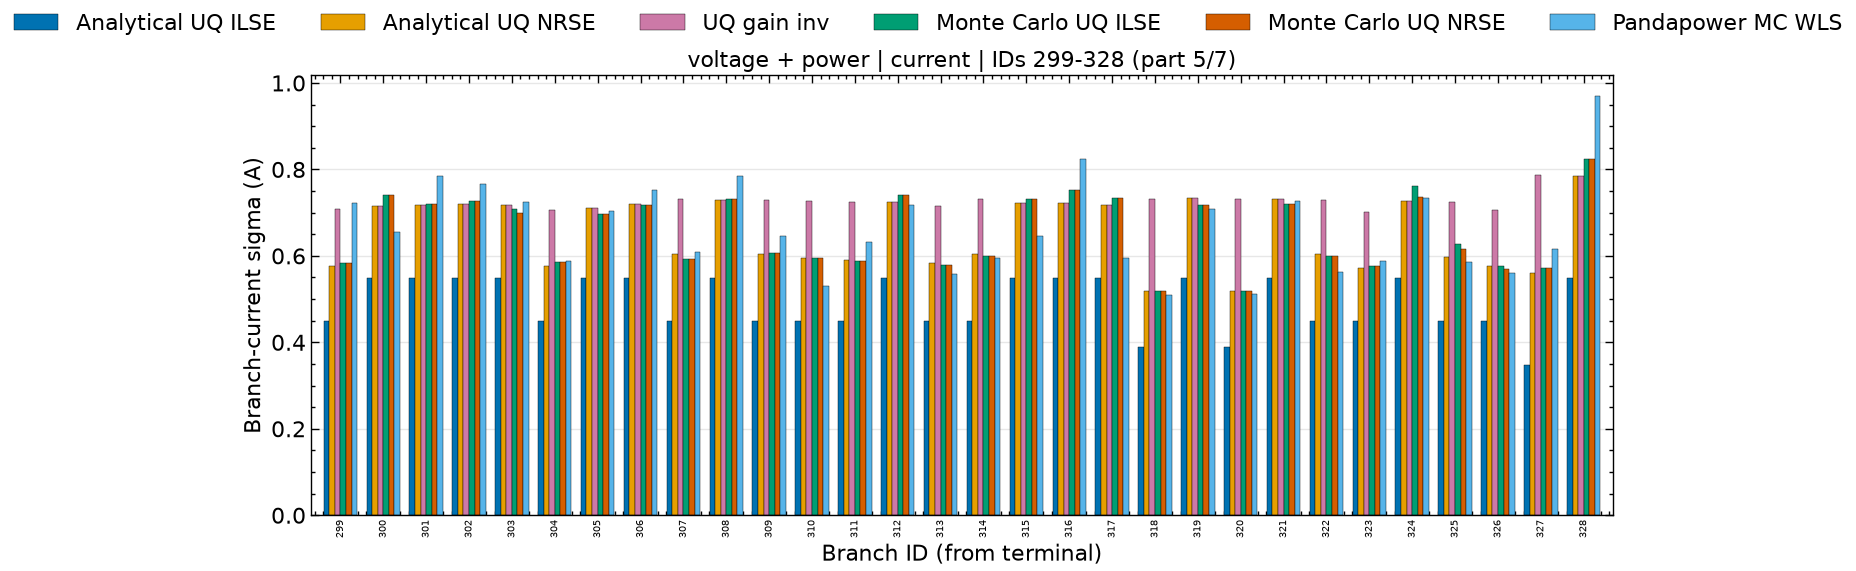

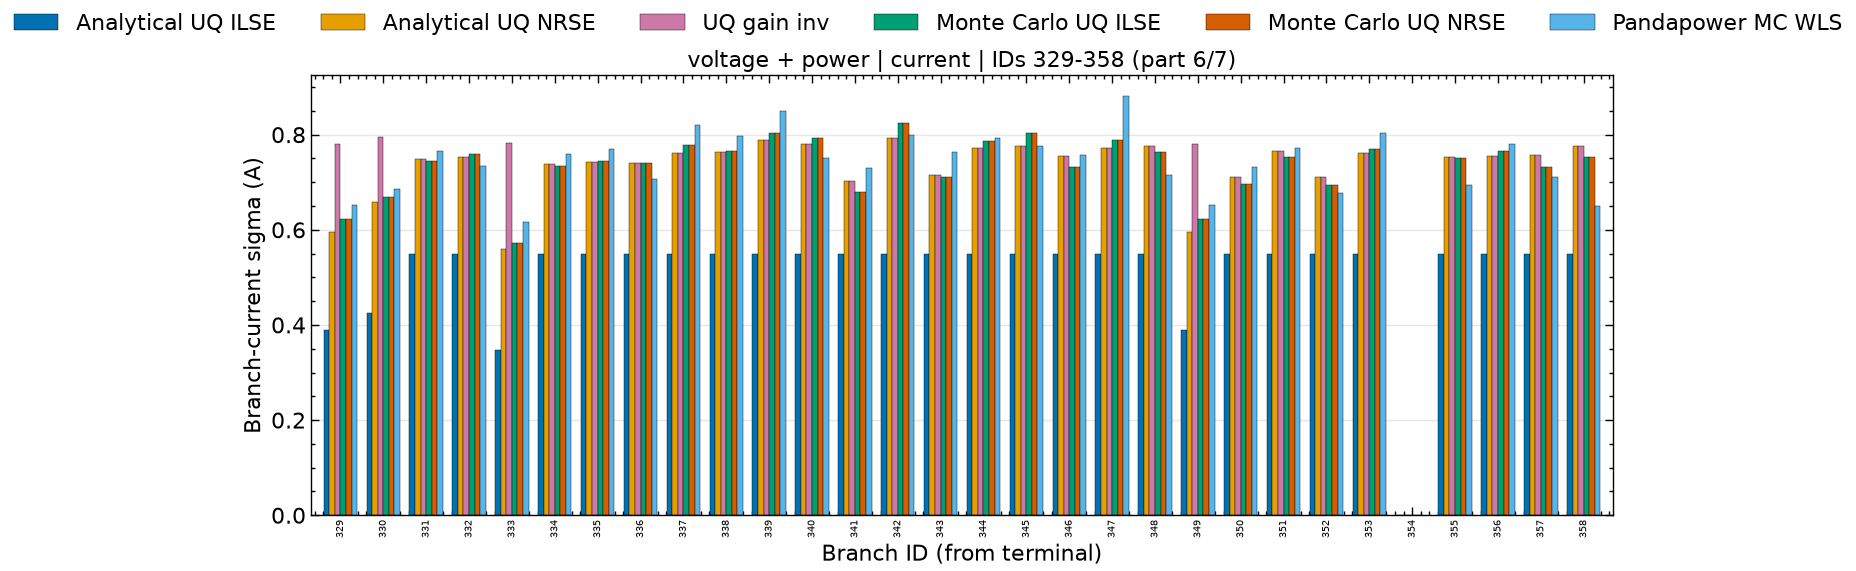

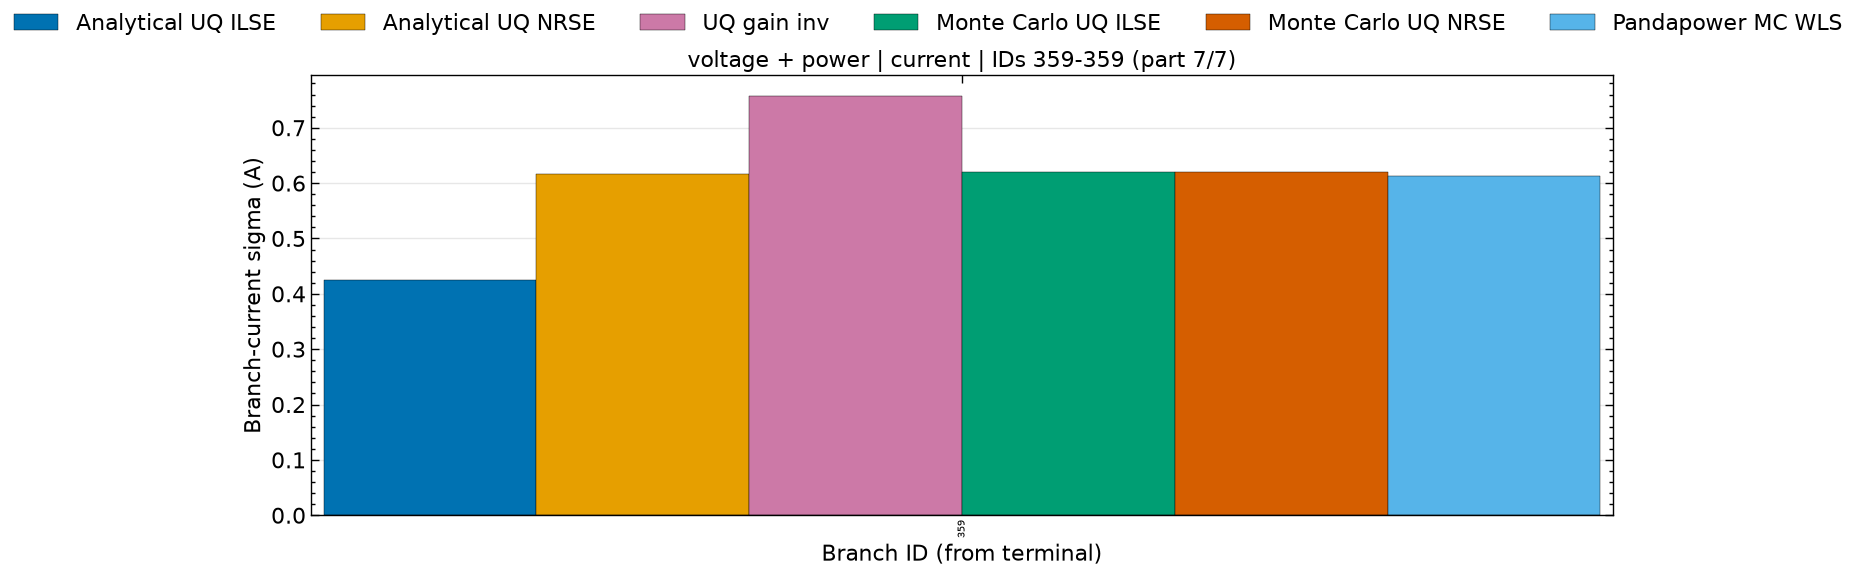

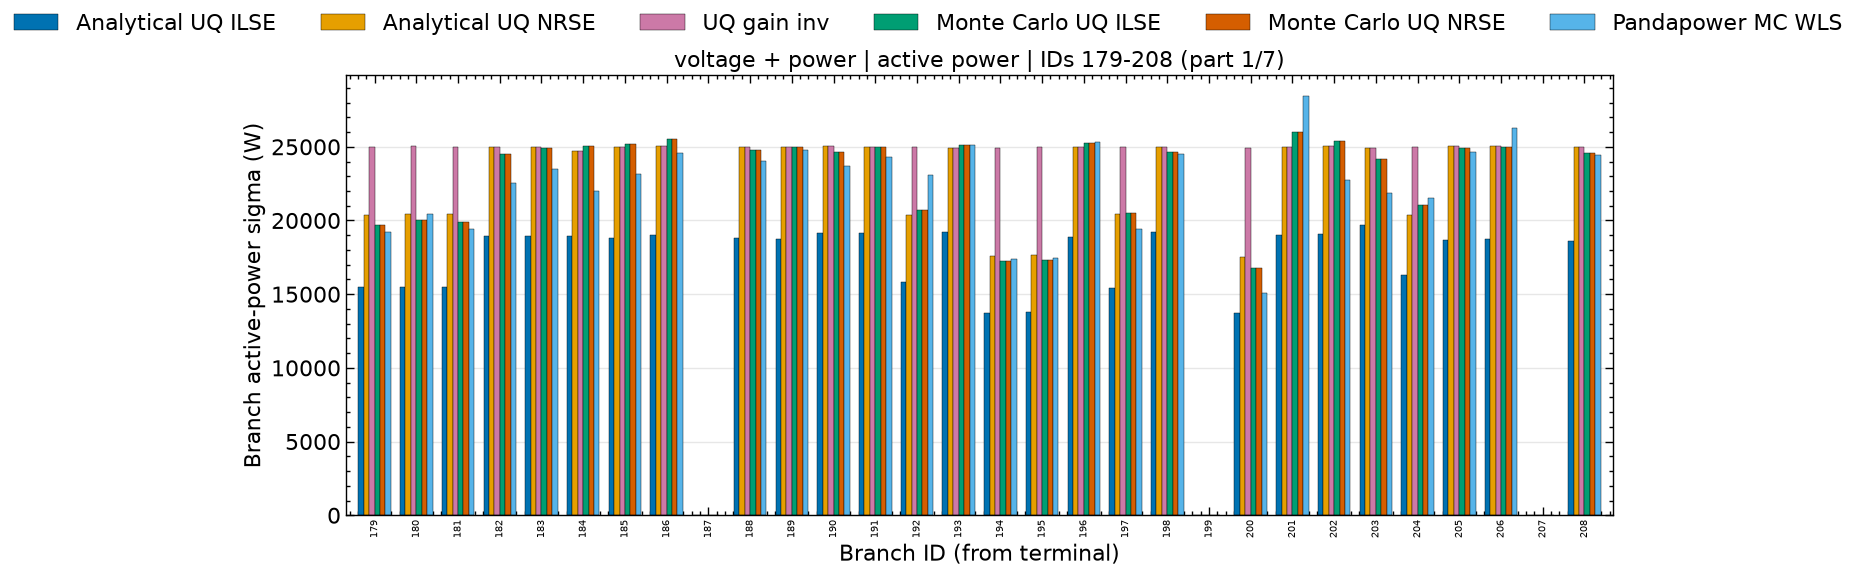

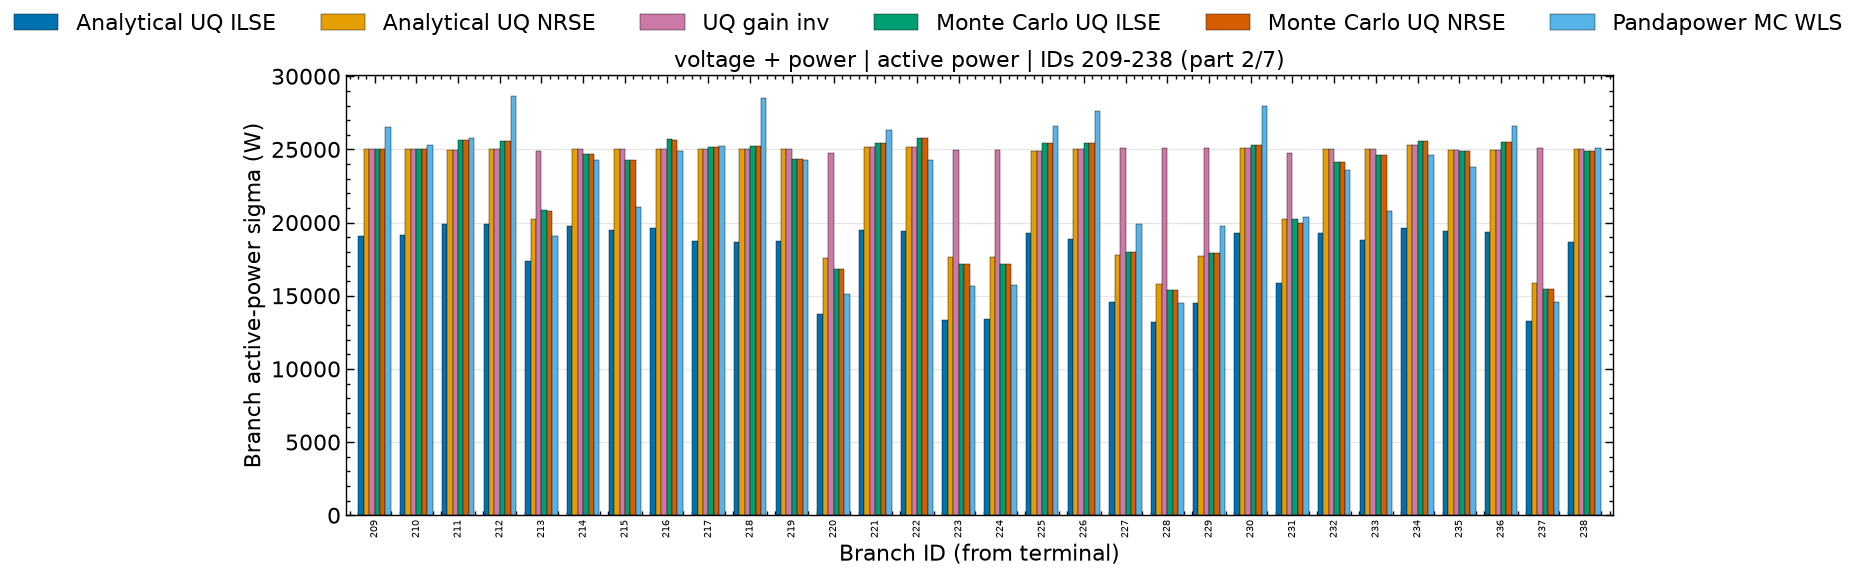

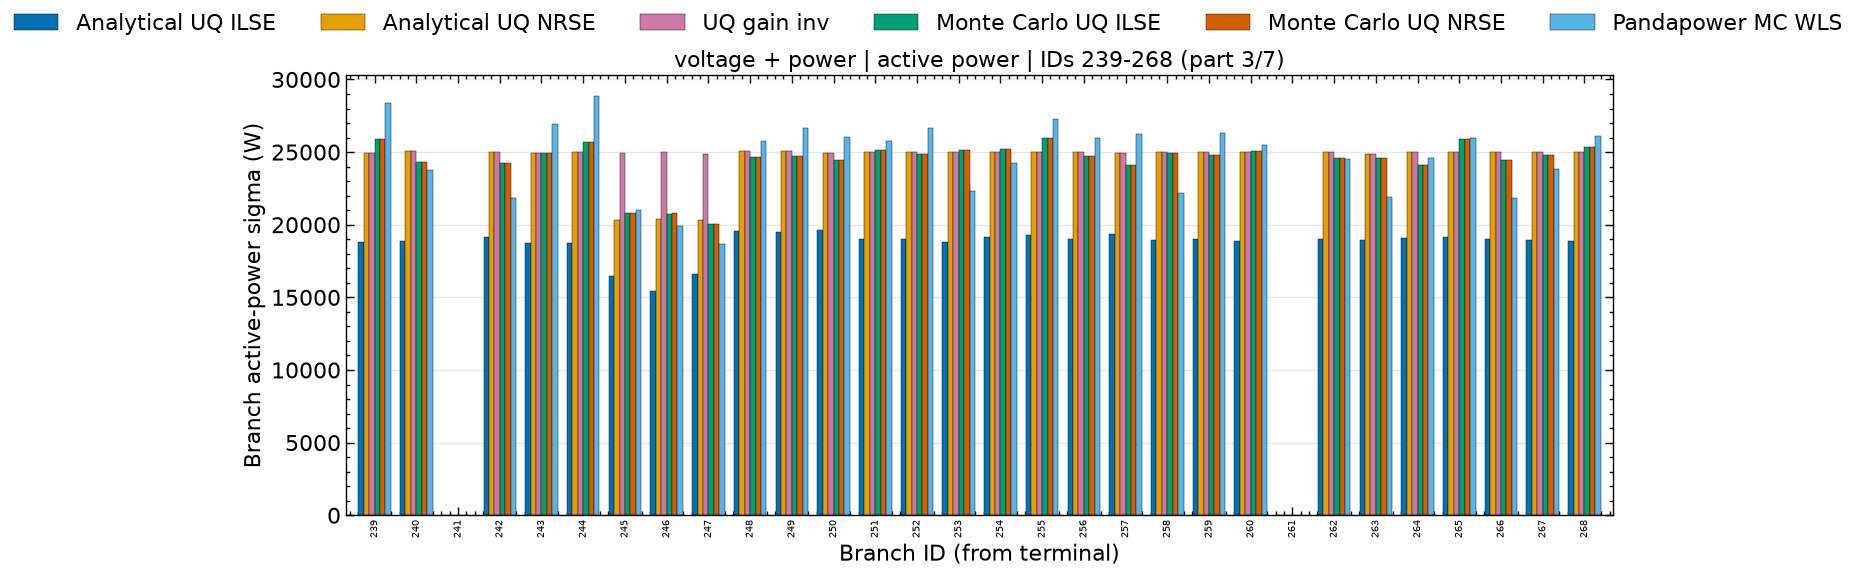

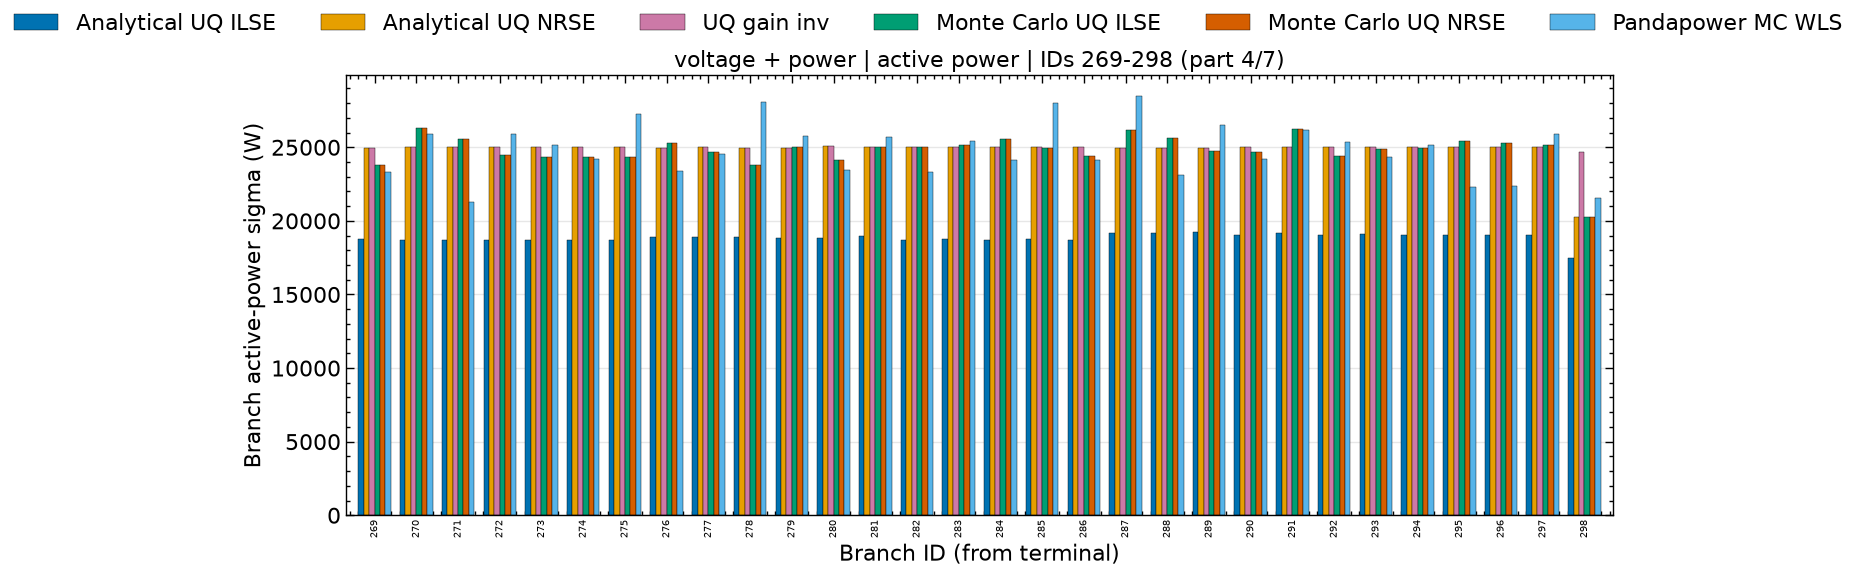

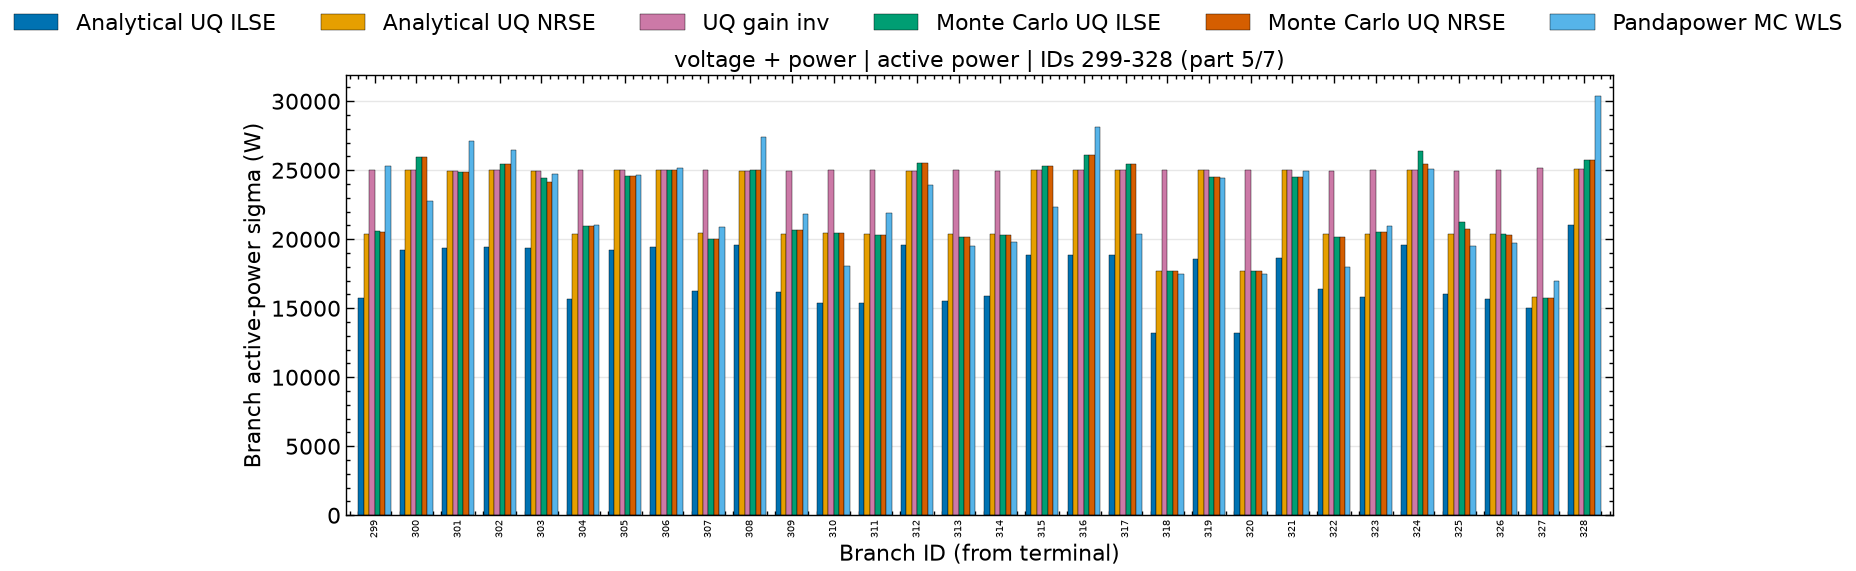

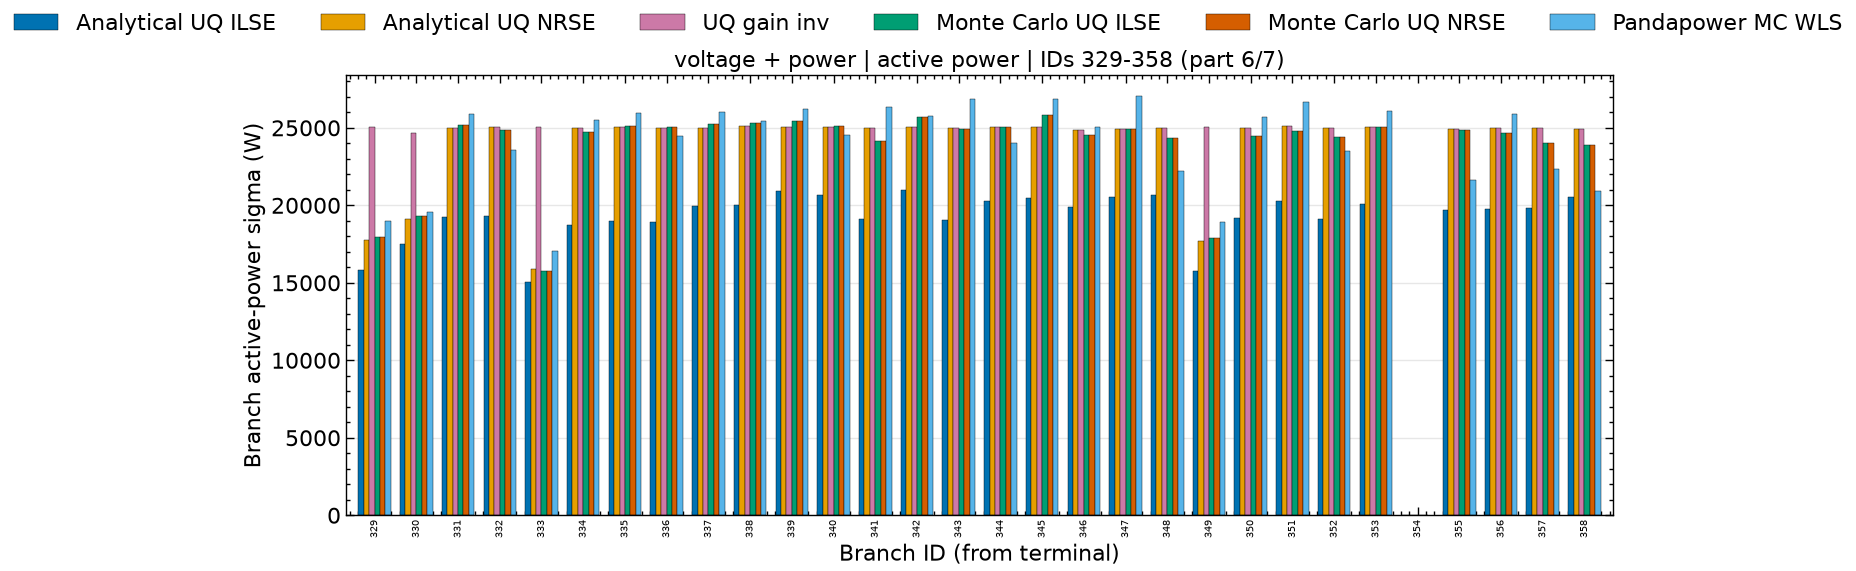

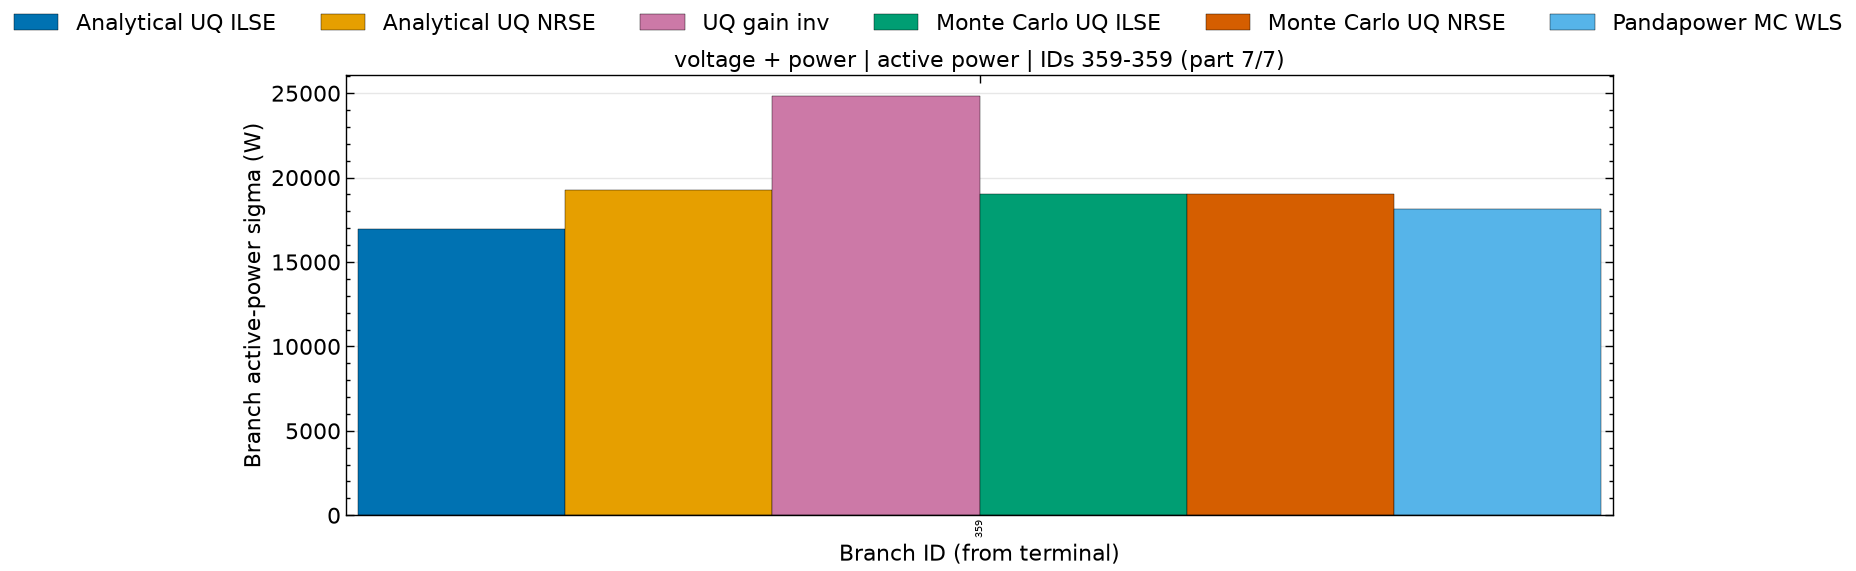

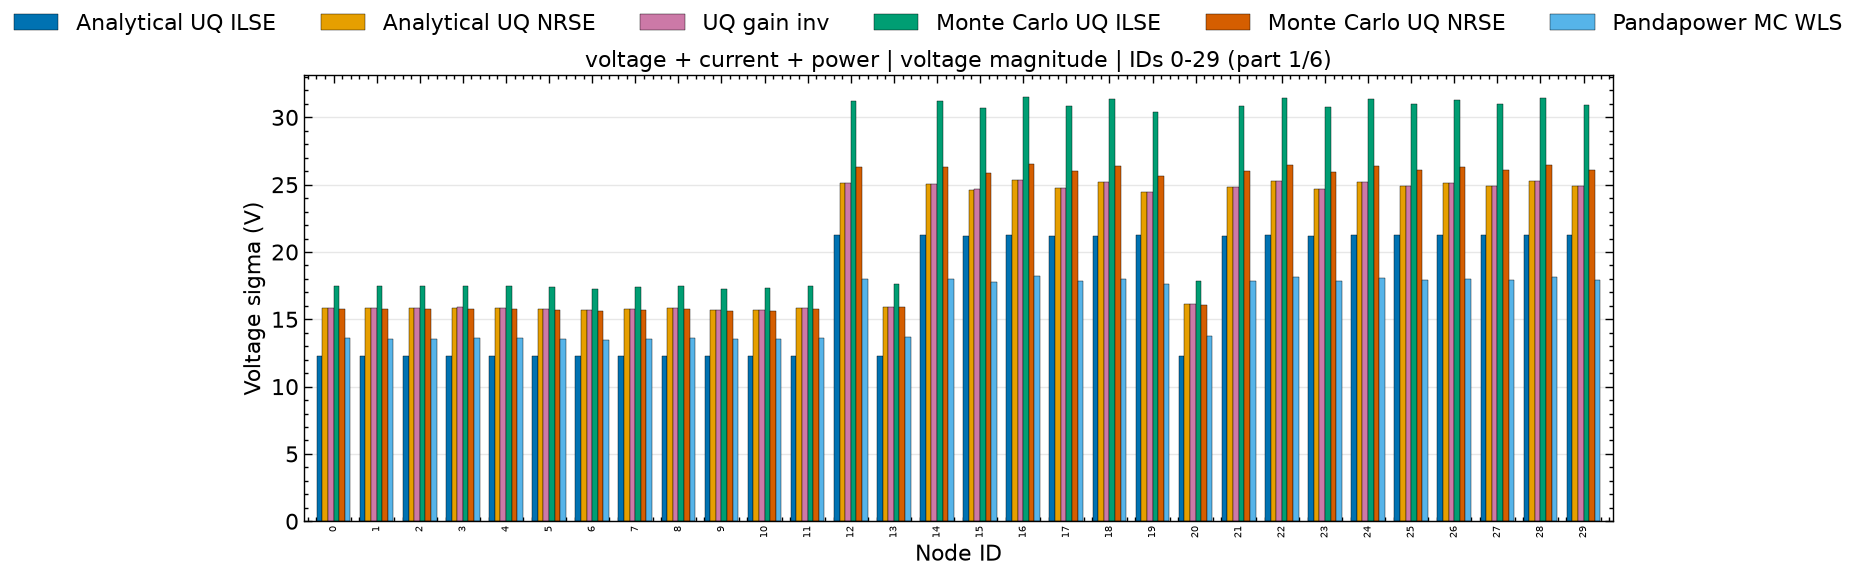

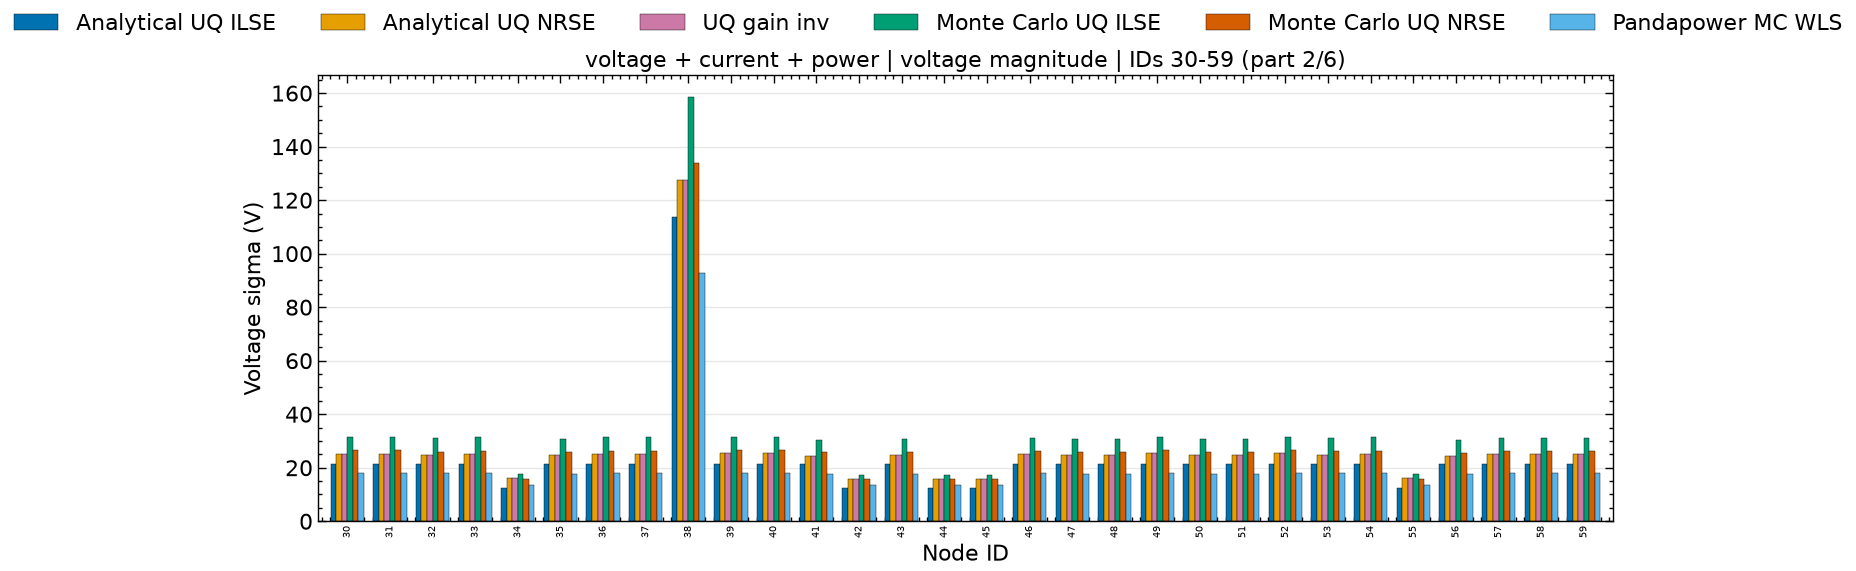

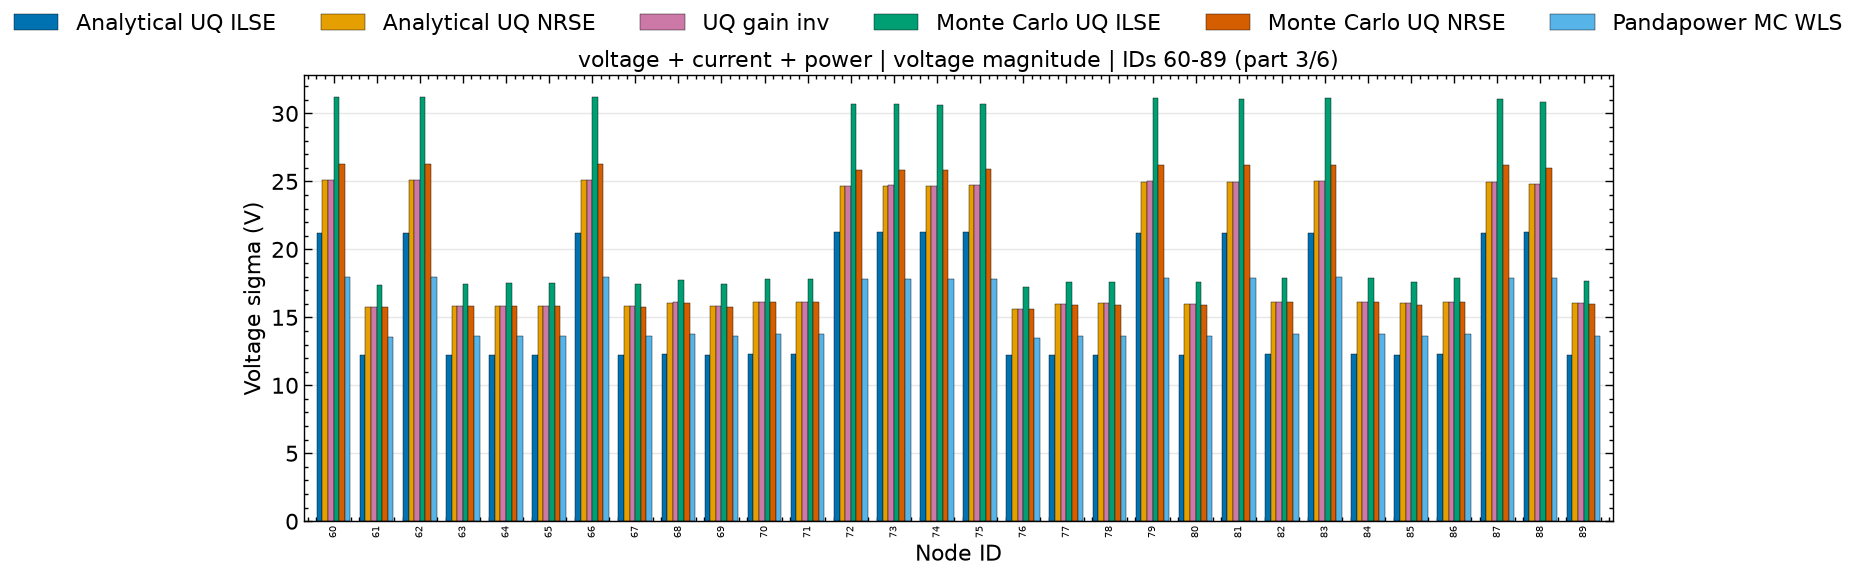

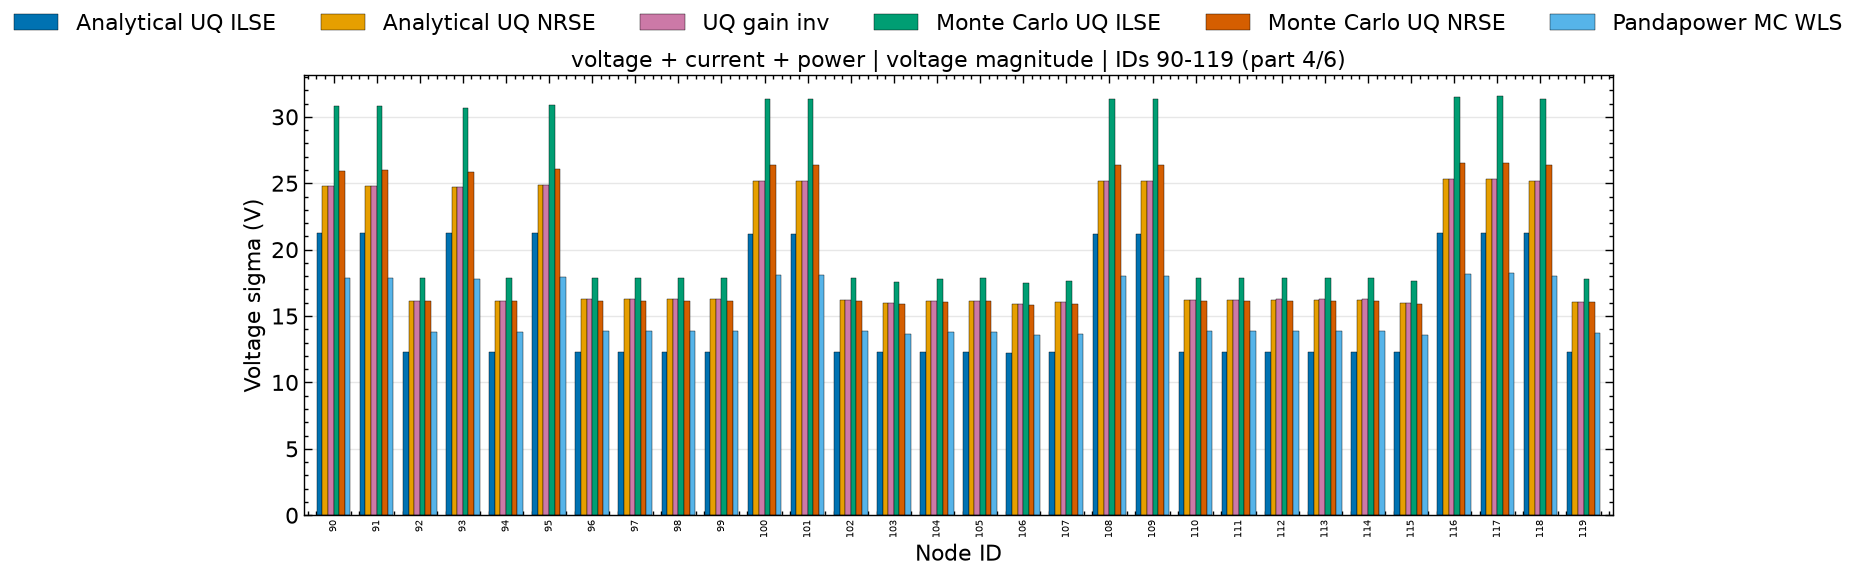

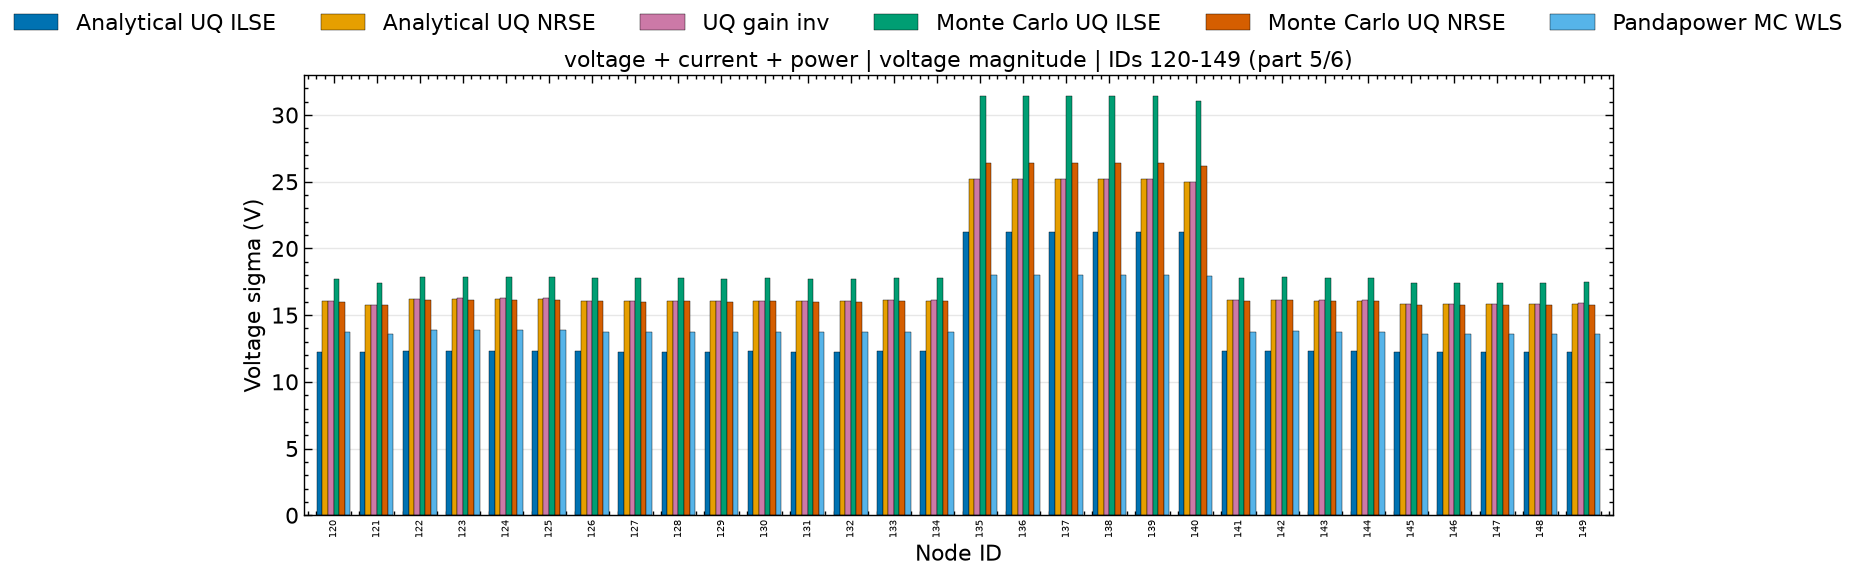

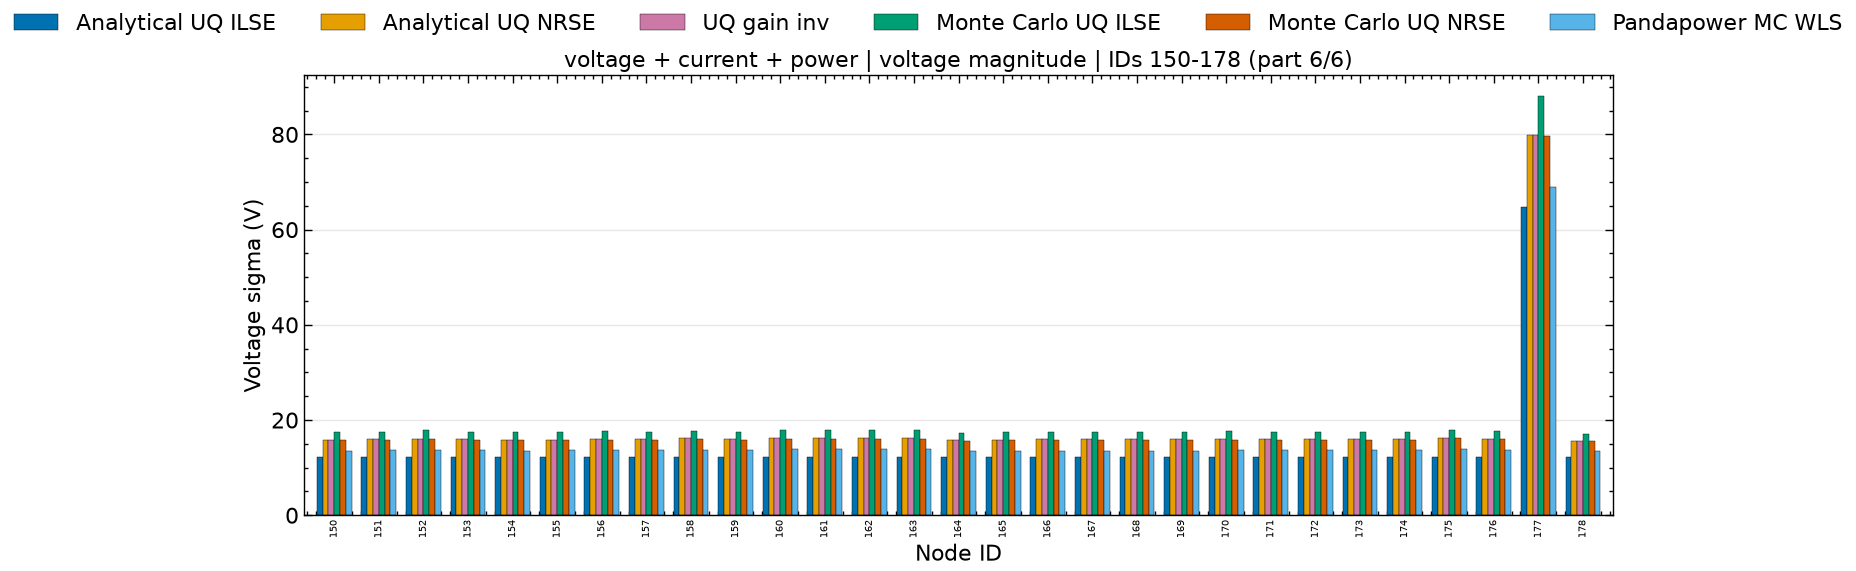

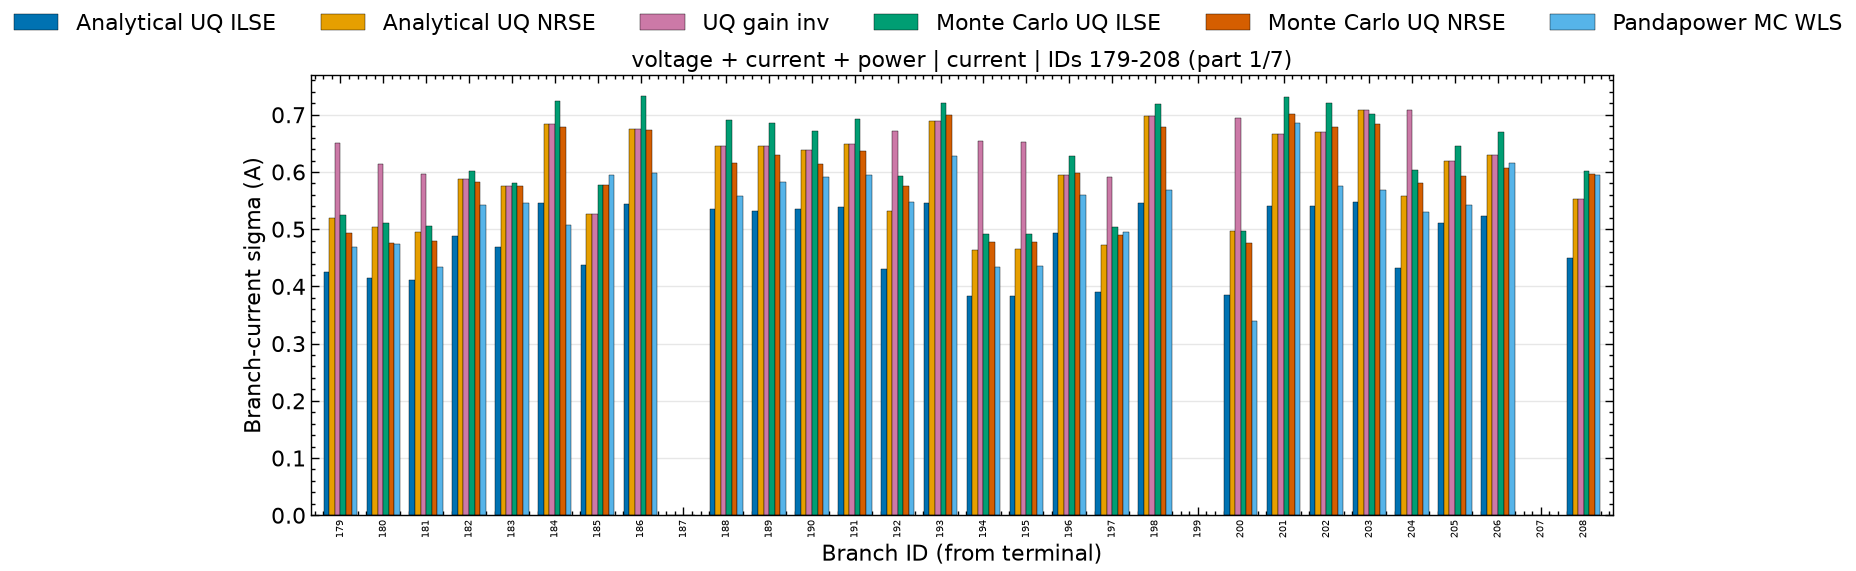

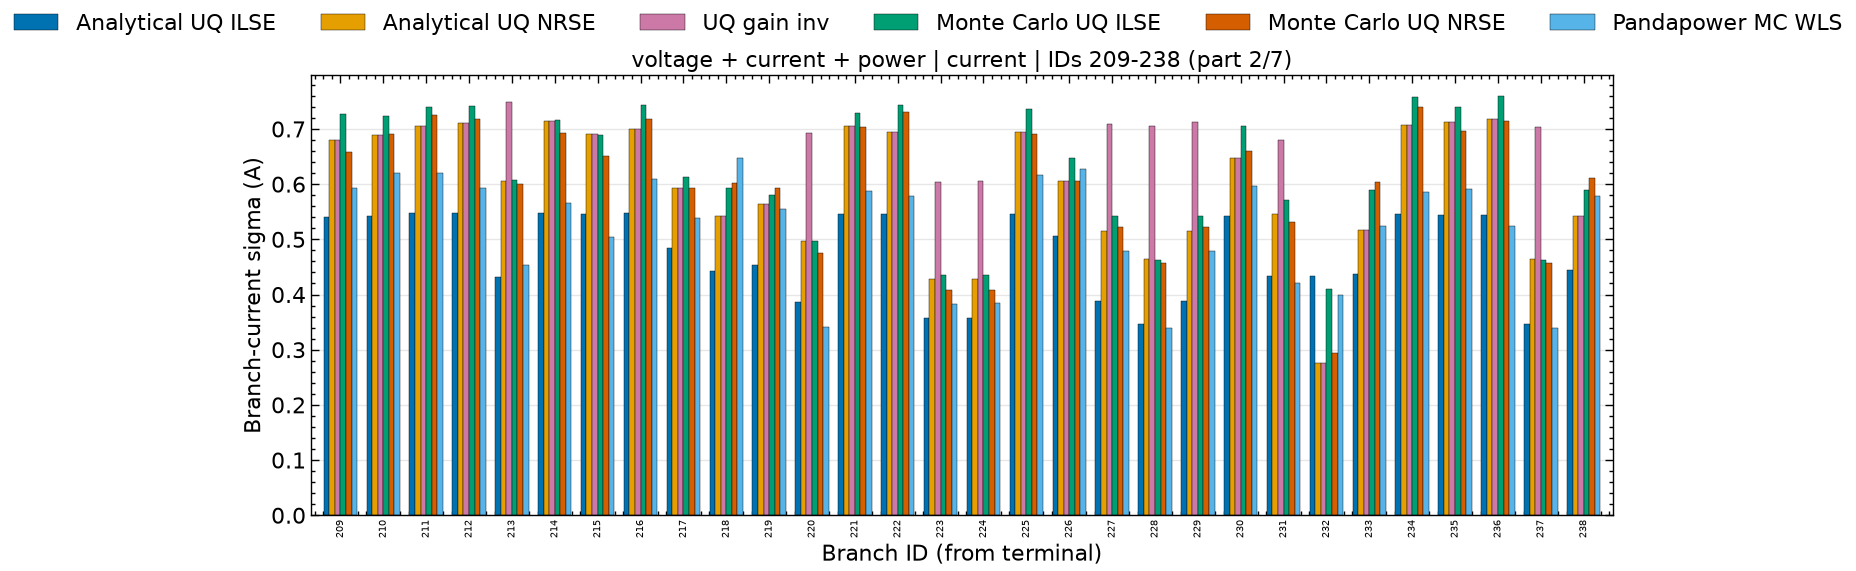

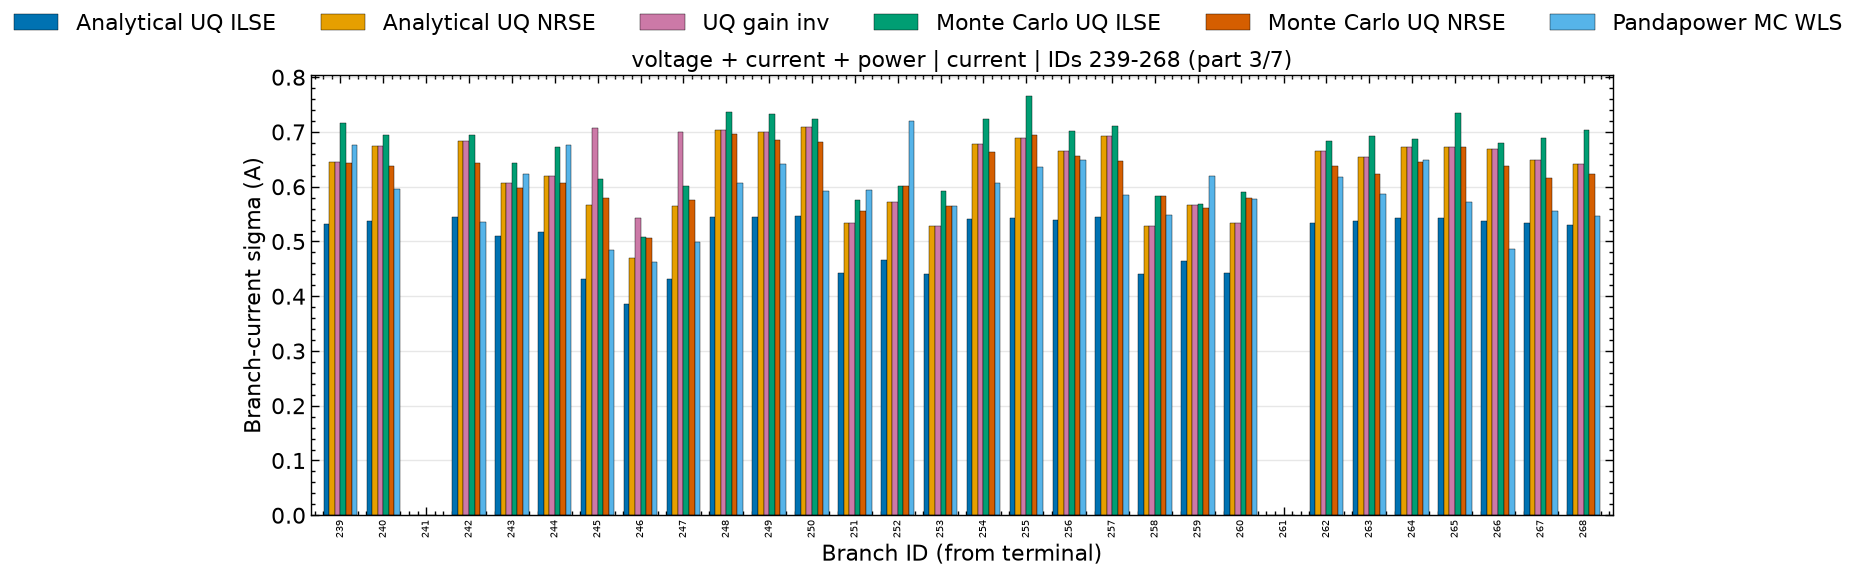

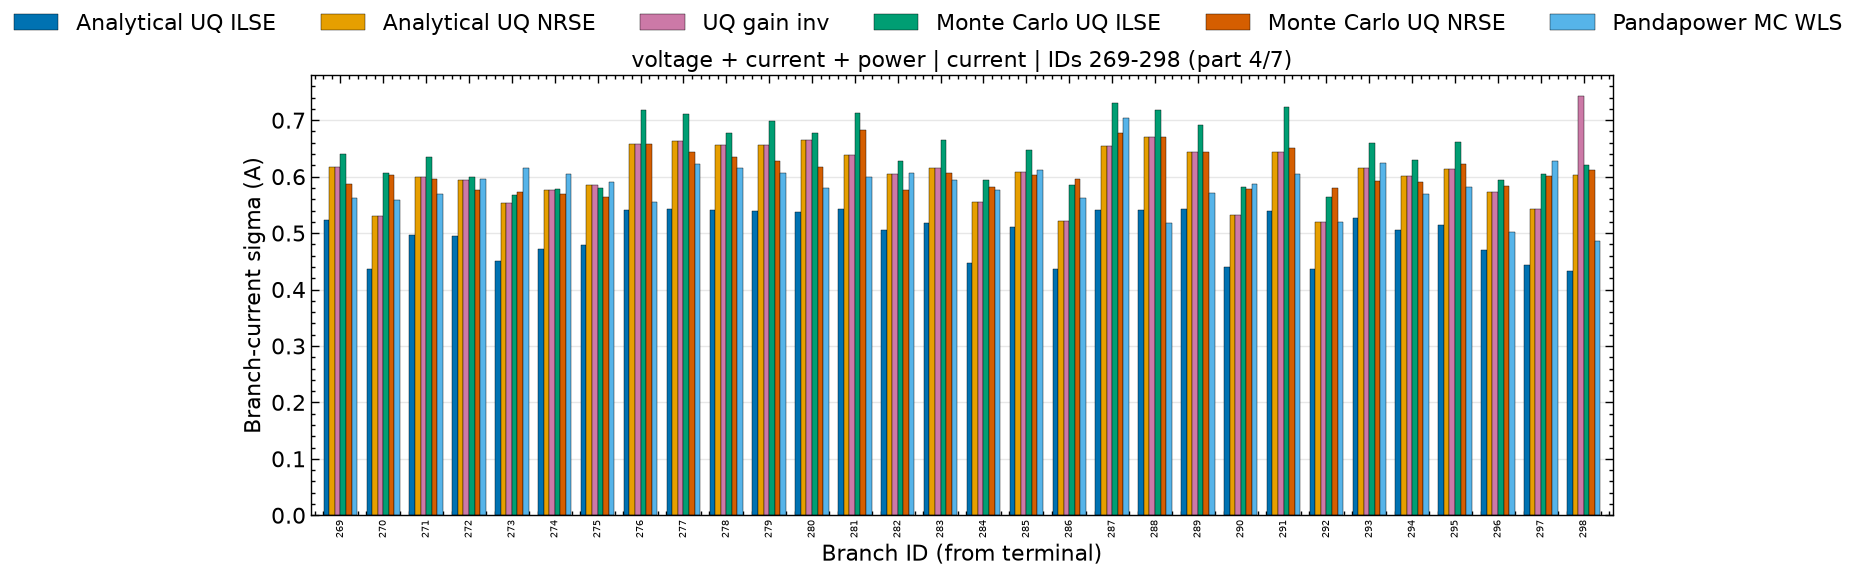

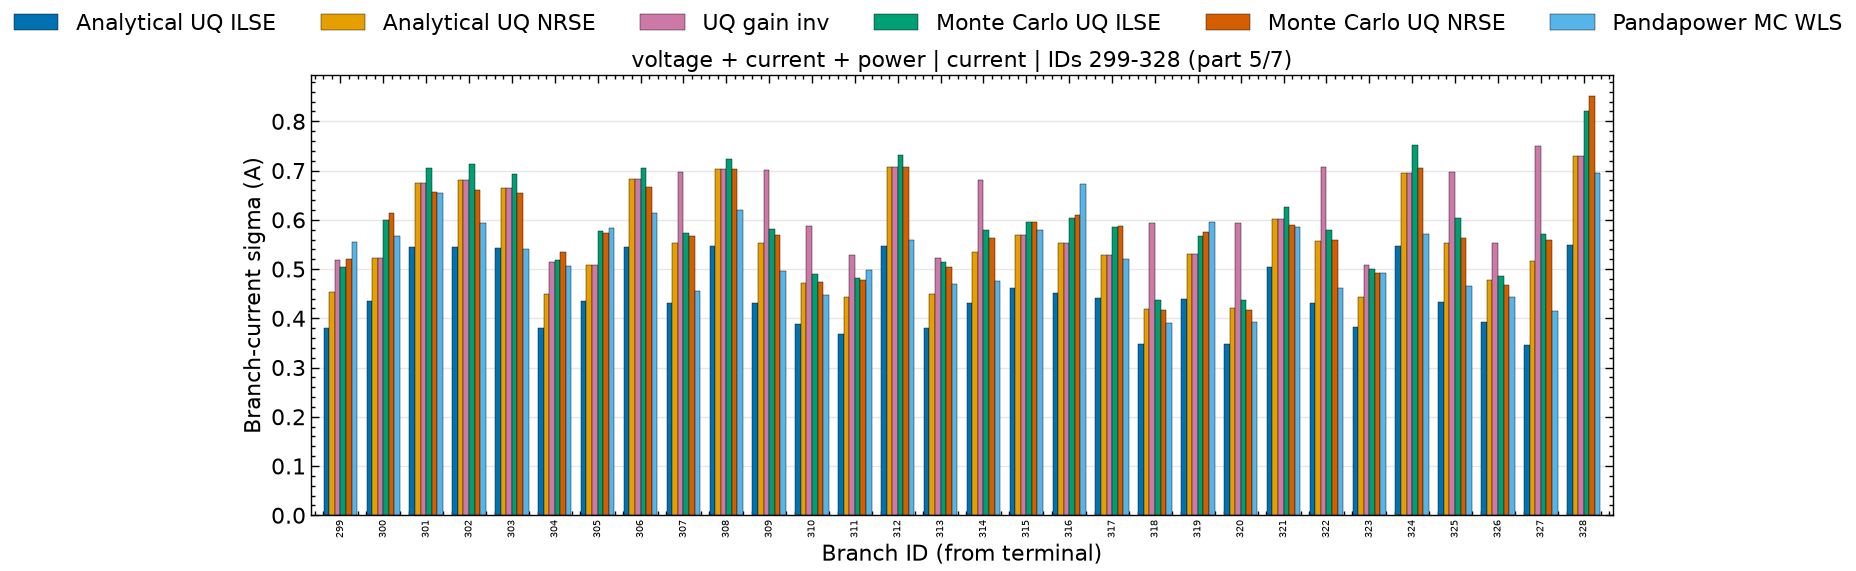

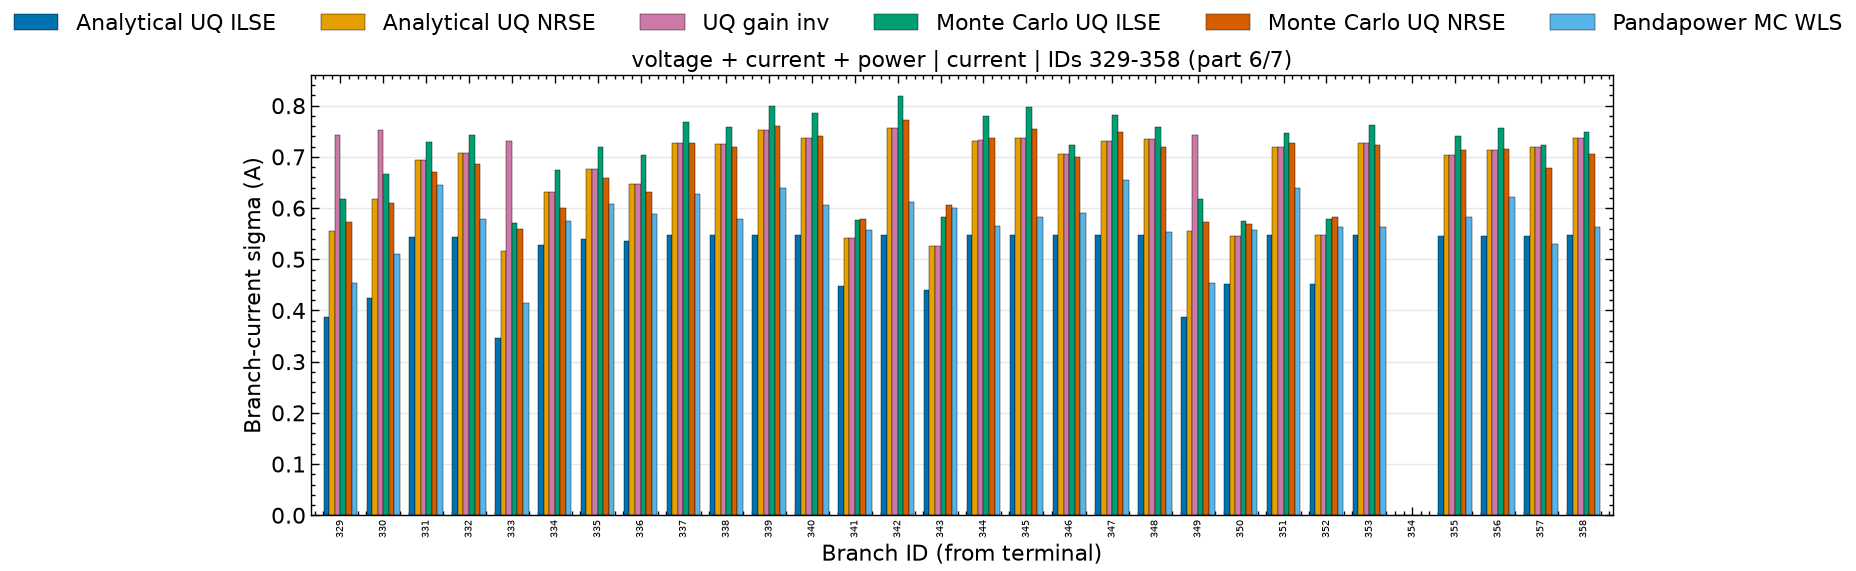

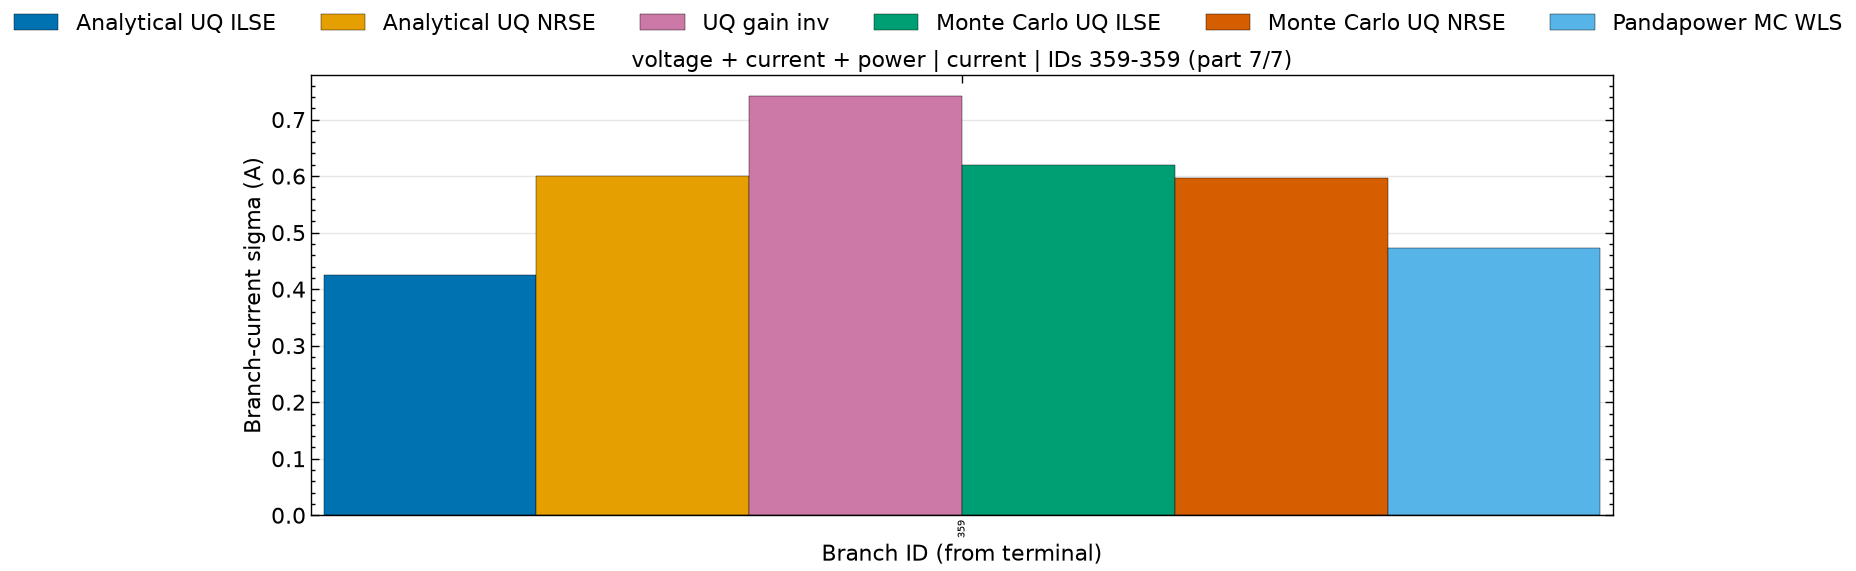

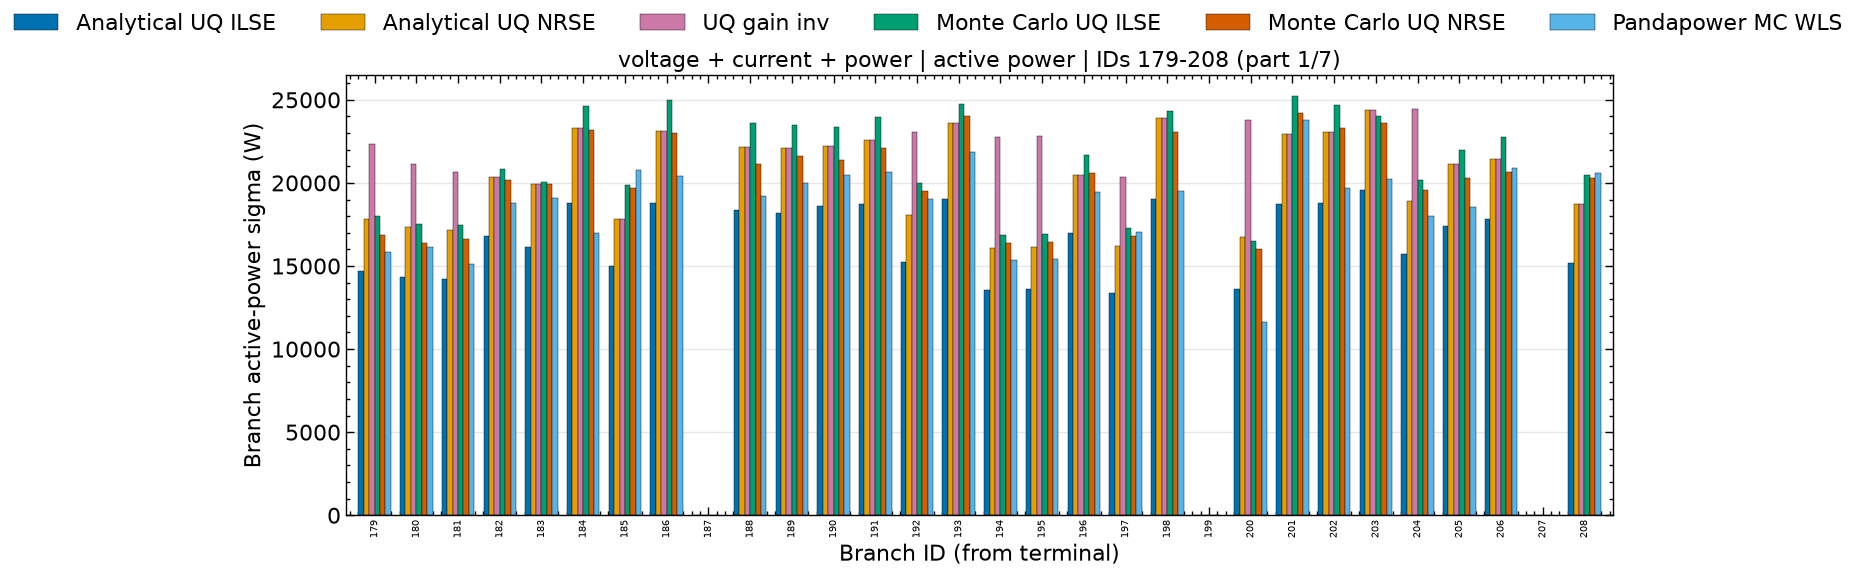

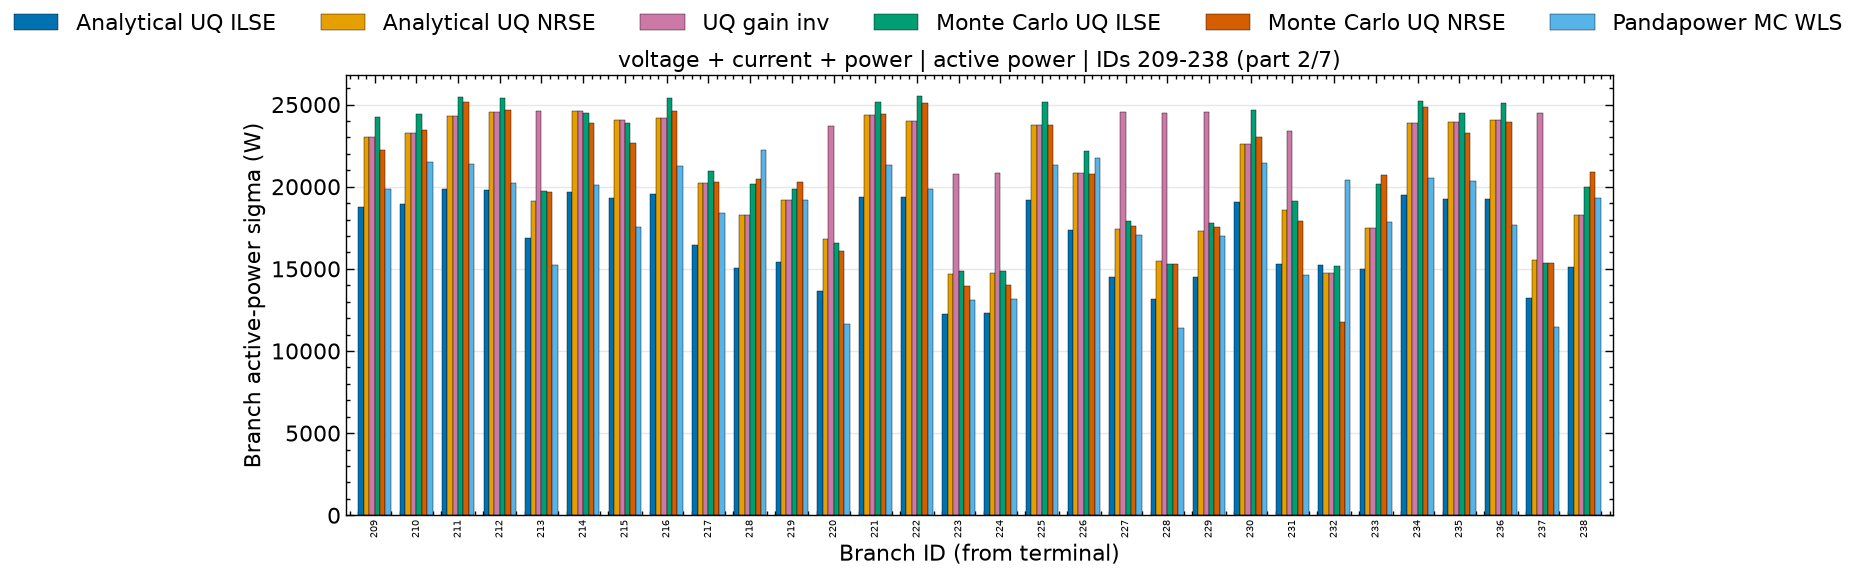

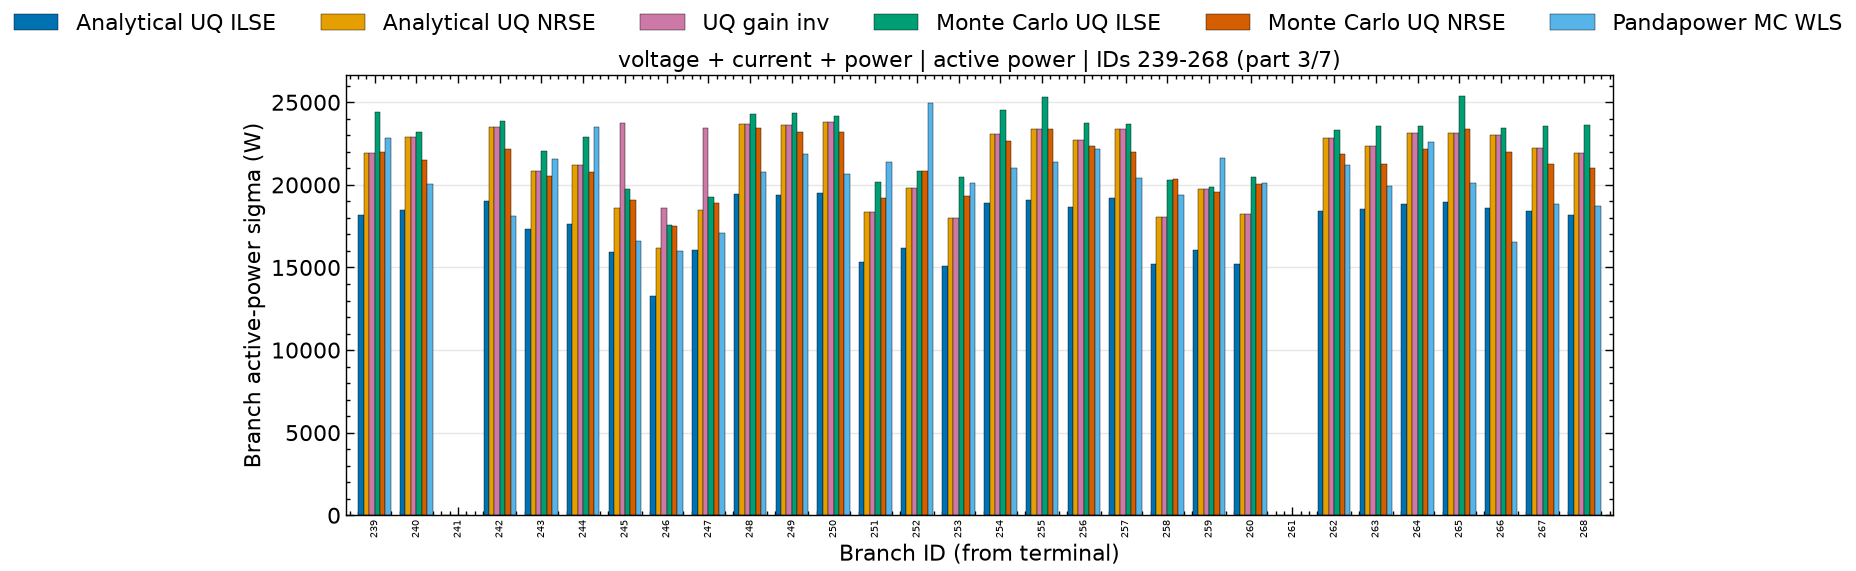

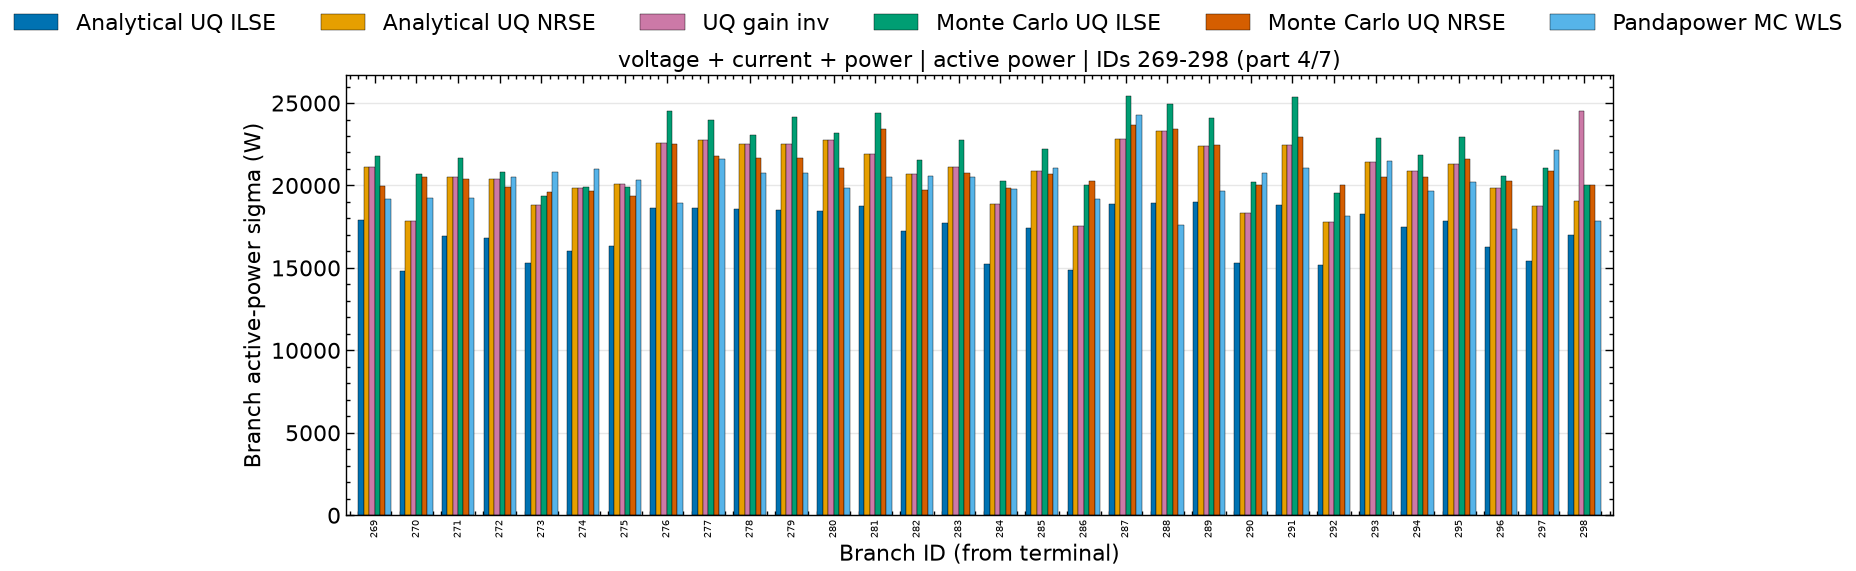

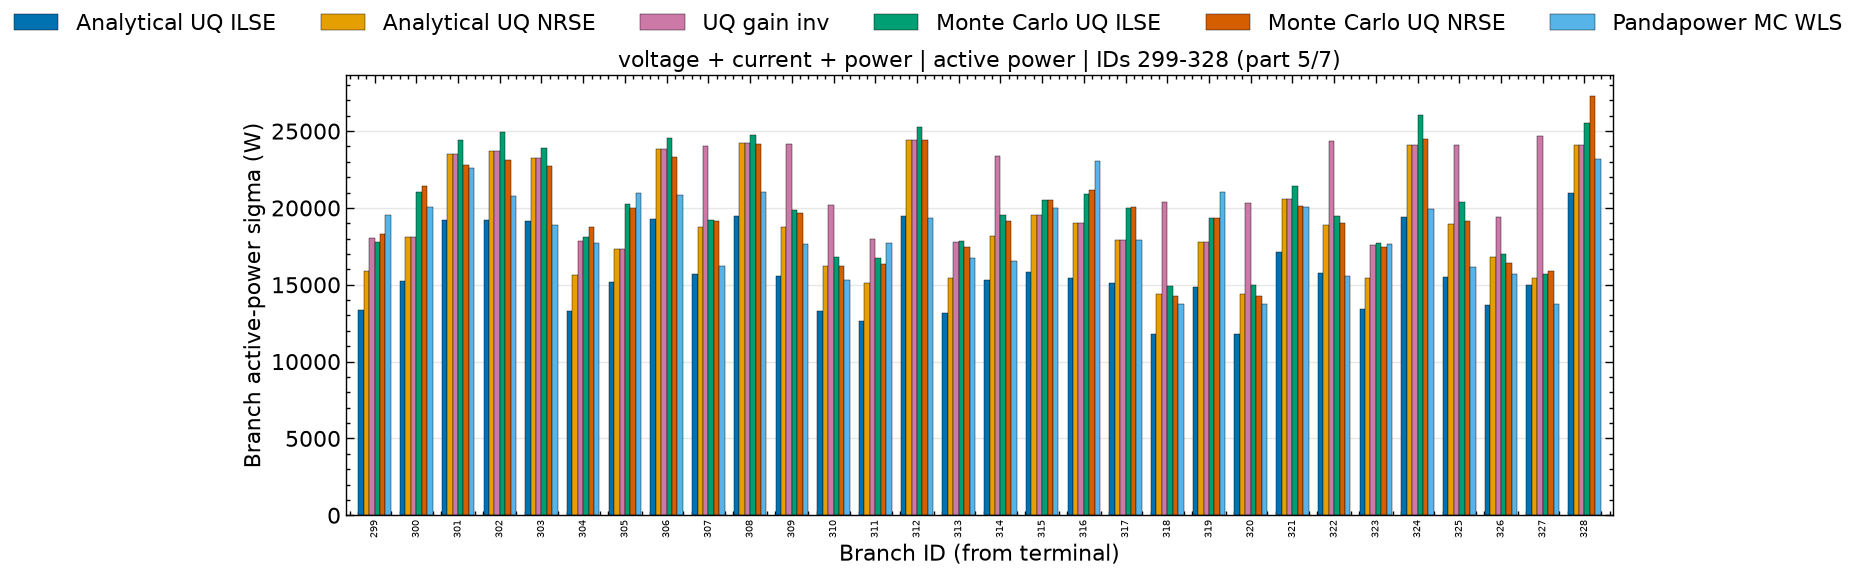

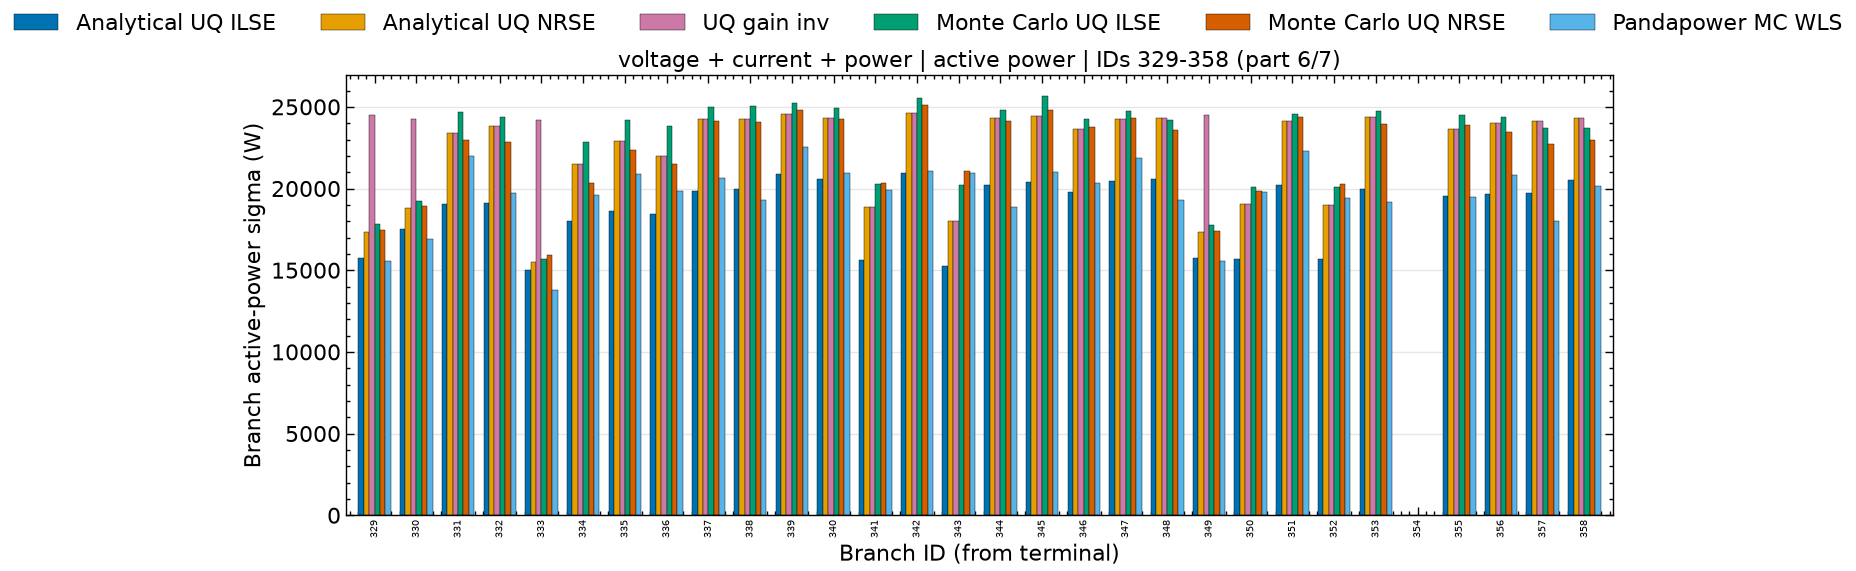

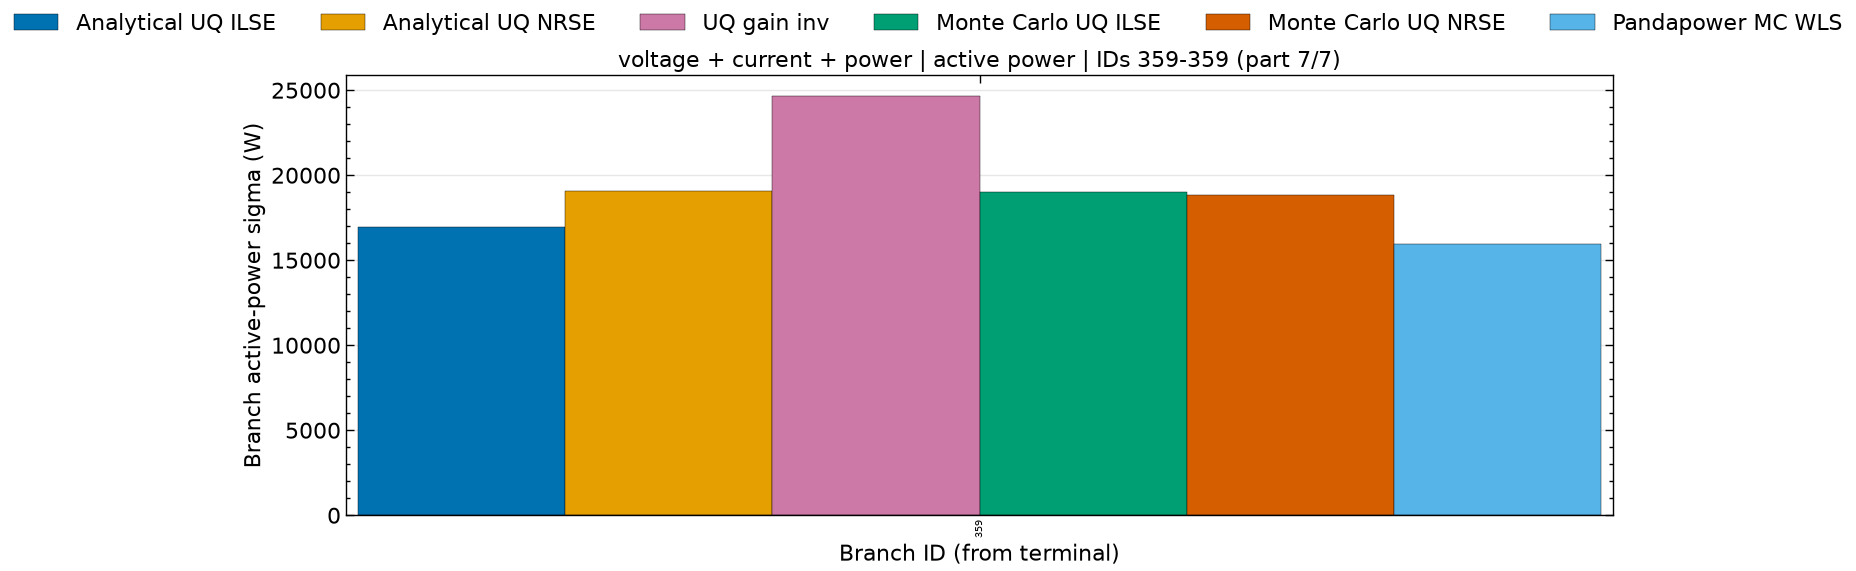

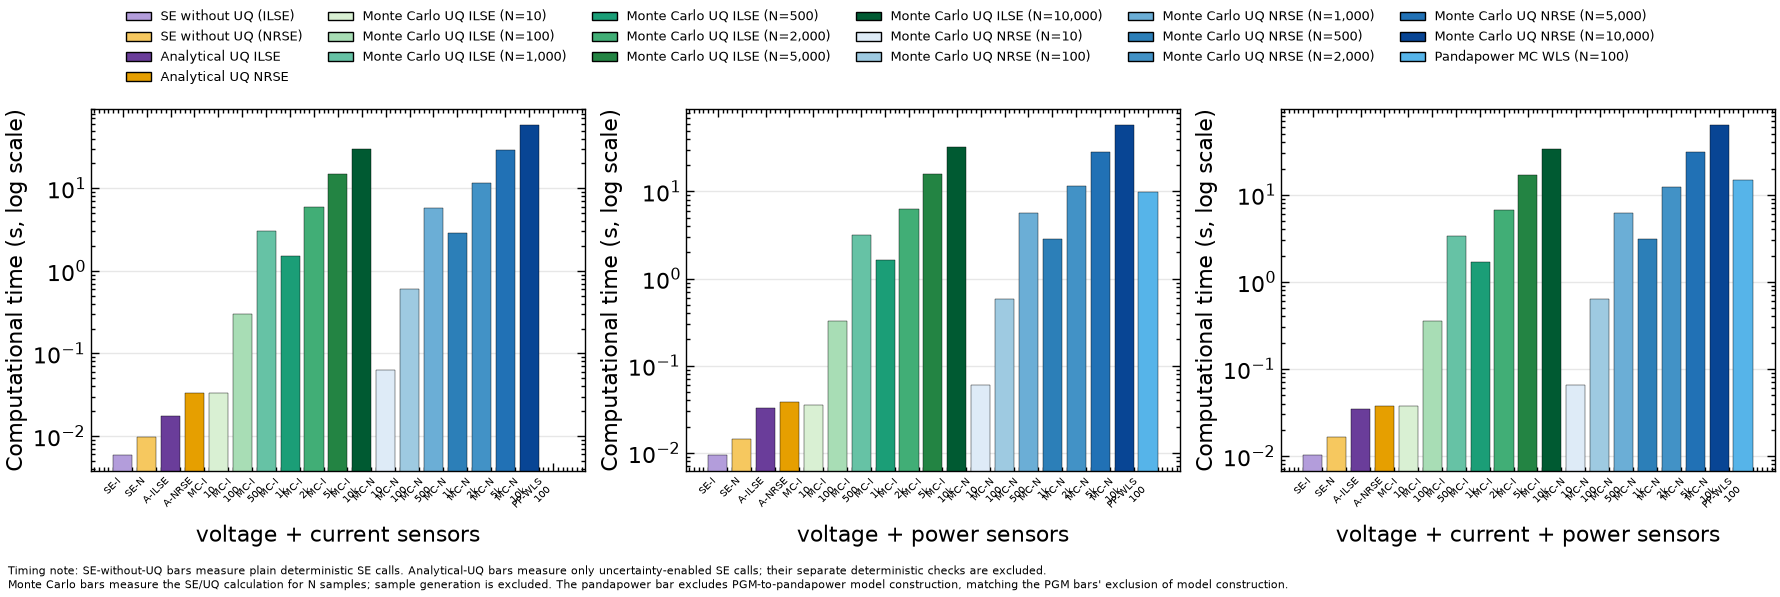

In [14]:
# ruff: noqa: E501
from pathlib import Path

from matplotlib.patches import Patch

try:
    import scienceplots  # noqa: F401
except ImportError:
    plot_style = ["default"]
else:
    plot_style = ["science", "notebook"]

method_columns = [
    ("Analytical UQ ILSE sigma", "Analytical UQ ILSE", "#0072B2"),
    ("Analytical UQ NRSE sigma", "Analytical UQ NRSE", "#E69F00"),
    ("UQ gain inv sigma", "UQ gain inv", "#CC79A7"),
    ("Monte Carlo UQ ILSE sigma", "Monte Carlo UQ ILSE", "#009E73"),
    ("Monte Carlo UQ NRSE sigma", "Monte Carlo UQ NRSE", "#D55E00"),
    ("Pandapower MC WLS sigma", "Pandapower MC WLS", "#56B4E9"),
]
plot_definitions = [
    ("node", "voltage magnitude", "Voltage sigma (V)", "Node ID", None),
    ("line", "current", "Branch-current sigma (A)", "Branch ID (from terminal)", "from"),
    ("line", "active power", "Branch active-power sigma (W)", "Branch ID (from terminal)", "from"),
]


def plot_sigma_bars(ax, filtered, plot_definition):
    _, _, ylabel, xlabel, _ = plot_definition
    positions = np.arange(len(filtered))
    bar_width = 0.13
    offsets = (np.arange(len(method_columns)) - (len(method_columns) - 1) / 2) * bar_width
    for offset, (column, label, color) in zip(offsets, method_columns, strict=True):
        ax.bar(
            positions + offset,
            filtered[column].to_numpy(),
            width=bar_width,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.3,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(filtered["id"].astype(str).tolist(), rotation=90, fontsize=7)
    ax.grid(axis="y", visible=True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)


figure_directory = output_directory / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

node_ids_for_plot = sorted(int(node_id) for node_id in base_input_data[ComponentType.node][AttributeType.id])
node_index = {node_id: index for index, node_id in enumerate(node_ids_for_plot)}
topology_edges = [
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node])) for row in base_input_data[ComponentType.line]
]
topology_edges.extend(
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node]))
    for row in base_input_data[ComponentType.transformer]
)
angles = np.linspace(0.0, 2.0 * np.pi, len(node_ids_for_plot), endpoint=False)
topology_coordinates = np.column_stack((np.cos(angles), np.sin(angles)))
for _ in range(180):
    displacement = topology_coordinates[:, None, :] - topology_coordinates[None, :, :]
    distances = np.maximum(np.linalg.norm(displacement, axis=2, keepdims=True), 0.08)
    topology_coordinates += 0.004 * np.sum(displacement / distances**3, axis=1)
    for from_node, to_node in topology_edges:
        from_index = node_index[from_node]
        to_index = node_index[to_node]
        edge_vector = topology_coordinates[to_index] - topology_coordinates[from_index]
        topology_coordinates[from_index] += 0.004 * edge_vector
        topology_coordinates[to_index] -= 0.004 * edge_vector
    topology_coordinates -= topology_coordinates.mean(axis=0)
    topology_coordinates /= max(np.max(np.abs(topology_coordinates)), 1.0)
topology_positions = {node_id: topology_coordinates[index] for index, node_id in enumerate(node_ids_for_plot)}
topology_line_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.line]}
topology_transformer_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.transformer]}
network_size_label = (
    f"{len(node_ids_for_plot)} buses, {len(topology_line_rows)} lines, {len(topology_transformer_rows)} transformers"
)
with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    topology_figure, topology_axis = plt.subplots(figsize=(14, 9))
    for line_id, row in topology_line_rows.items():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        x_values = [topology_positions[from_node][0], topology_positions[to_node][0]]
        y_values = [topology_positions[from_node][1], topology_positions[to_node][1]]
        is_closed = bool(row[AttributeType.from_status]) and bool(row[AttributeType.to_status])
        topology_axis.plot(
            x_values,
            y_values,
            color="#0072B2" if is_closed else "#D55E00",
            linestyle="-" if is_closed else "--",
            linewidth=0.8 if is_closed else 2.0,
            alpha=0.65,
        )
        if not is_closed:
            topology_axis.text(
                sum(x_values) / 2,
                sum(y_values) / 2,
                str(line_id),
                color="#991b1b",
                fontsize=7,
                ha="center",
                va="center",
                bbox={"facecolor": "#fde2e1", "edgecolor": "none", "pad": 1.2},
            )
    for row in topology_transformer_rows.values():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        topology_axis.plot(
            [topology_positions[from_node][0], topology_positions[to_node][0]],
            [topology_positions[from_node][1], topology_positions[to_node][1]],
            color="#7B2CBF",
            linewidth=2.6,
            alpha=0.9,
        )
    topology_axis.scatter(
        [topology_positions[node_id][0] for node_id in node_ids_for_plot],
        [topology_positions[node_id][1] for node_id in node_ids_for_plot],
        s=20,
        color="#E69F00",
        edgecolor="black",
        linewidth=0.25,
        zorder=3,
    )
    topology_axis.set_title(f"MV Oberrhein topology ({network_size_label})", pad=12)
    topology_axis.axis("off")
    topology_axis.legend(
        handles=[
            plt.Line2D([0], [0], color="#0072B2", linewidth=1.4, label="Closed line"),
            plt.Line2D([0], [0], color="#D55E00", linestyle="--", linewidth=2.0, label="Open sectioning line"),
            plt.Line2D([0], [0], color="#7B2CBF", linewidth=2.6, label="Transformer"),
        ],
        loc="upper right",
    )
    topology_figure.tight_layout()
    topology_figure.savefig(figure_directory / "mv_oberrhein_topology.pdf")
    topology_figure.savefig(figure_directory / "mv_oberrhein_topology.png", dpi=300)
    plt.show()
setting_slugs = {
    "voltage + current": "voltage_current",
    "voltage + power": "voltage_power",
    "voltage + current + power": "voltage_current_power",
}
plot_chunk_size = 30

with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    for setting in sensor_settings:
        for plot_definition in plot_definitions:
            component, quantity, _, _, terminal = plot_definition
            filtered = comparison[
                (comparison["sensor setting"] == setting)
                & (comparison["component"] == component)
                & (comparison["quantity"] == quantity)
            ].copy()
            if terminal is not None:
                filtered = filtered[filtered["terminal"] == terminal]
            filtered = filtered.sort_values("id").reset_index(drop=True)
            chunk_count = (len(filtered) + plot_chunk_size - 1) // plot_chunk_size
            quantity_slug = quantity.replace(" ", "_")
            for chunk_number, chunk_start in enumerate(
                range(0, len(filtered), plot_chunk_size),
                start=1,
            ):
                chunk = filtered.iloc[chunk_start : chunk_start + plot_chunk_size]
                chunk_end = chunk_start + len(chunk)
                figure, axis = plt.subplots(figsize=(14, 6))
                plot_sigma_bars(axis, chunk, plot_definition)
                axis.set_title(
                    f"{setting} | {quantity} | IDs {int(chunk['id'].iloc[0])}-{int(chunk['id'].iloc[-1])} "
                    f"(part {chunk_number}/{chunk_count})"
                )
                handles, labels = axis.get_legend_handles_labels()
                figure.legend(handles, labels, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 0.98))
                figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.91))
                figure_path = figure_directory / (
                    f"mv_oberrhein_{setting_slugs[setting]}_{component}_{quantity_slug}_part_{chunk_number:02d}"
                )
                figure.savefig(figure_path.with_suffix(".pdf"))
                figure.savefig(figure_path.with_suffix(".png"), dpi=300)
                plt.show()
                plt.close(figure)

monte_carlo_baseline_sample_count = 1_000
timing_sample_counts = [
    *monte_carlo_timing_sample_counts[:2],
    monte_carlo_baseline_sample_count,
    *monte_carlo_timing_sample_counts[2:],
]
timing_sample_labels = dict(zip(timing_sample_counts, ["10", "100", "500", "1k", "2k", "5k", "10k"], strict=True))
timing_ilse_colors = ["#D9F0D3", "#A8DDB5", "#66C2A5", "#1B9E77", "#41AE76", "#238443", "#005A32"]
timing_nrse_colors = ["#DEEBF7", "#9ECAE1", "#6BAED6", "#2C7FB8", "#4292C6", "#2171B5", "#084594"]
timing_method_columns = (
    [
        ("SE without UQ (ILSE)", "SE-I", "#B39DDB"),
        ("SE without UQ (NRSE)", "SE-N", "#F6C85F"),
        ("Analytical UQ ILSE", "A-ILSE", "#6A3D9A"),
        ("Analytical UQ NRSE", "A-NRSE", "#E69F00"),
    ]
    + [
        (f"Monte Carlo UQ ILSE (N={sample_count:,})", f"MC-I\n{timing_sample_labels[sample_count]}", color)
        for sample_count, color in zip(timing_sample_counts, timing_ilse_colors, strict=True)
    ]
    + [
        (f"Monte Carlo UQ NRSE (N={sample_count:,})", f"MC-N\n{timing_sample_labels[sample_count]}", color)
        for sample_count, color in zip(timing_sample_counts, timing_nrse_colors, strict=True)
    ]
    + [(f"Pandapower MC WLS (N={pandapower_sample_count:,})", f"PP-WLS\n{pandapower_sample_count}", "#56B4E9")]
)

with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    timing_figure, timing_axes = plt.subplots(1, 3, figsize=(18, 6))
    for axis, setting in zip(timing_axes, sensor_settings, strict=True):
        values = [
            deterministic_seconds[setting, "Analytical UQ ILSE"],
            deterministic_seconds[setting, "Analytical UQ NRSE"],
            analytical_seconds[setting, "Analytical UQ ILSE"],
            analytical_seconds[setting, "Analytical UQ NRSE"],
            *[
                monte_carlo_seconds[setting, "Analytical UQ ILSE"]
                if sample_count == monte_carlo_baseline_sample_count
                else monte_carlo_scaling_seconds[setting, "Analytical UQ ILSE", sample_count]
                for sample_count in timing_sample_counts
            ],
            *[
                monte_carlo_seconds[setting, "Analytical UQ NRSE"]
                if sample_count == monte_carlo_baseline_sample_count
                else monte_carlo_scaling_seconds[setting, "Analytical UQ NRSE", sample_count]
                for sample_count in timing_sample_counts
            ],
            pandapower_results[setting].seconds,
        ]
        labels = [label for _, label, _ in timing_method_columns]
        colors = [color for _, _, color in timing_method_columns]
        axis.bar(np.arange(len(values)), values, color=colors, edgecolor="black", linewidth=0.3)
        axis.set_xlabel(f"{setting} sensors")
        axis.set_ylabel("Computational time (s, log scale)")
        axis.set_yscale("log")
        axis.set_xticks(np.arange(len(values)))
        axis.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        axis.grid(axis="y", visible=True, alpha=0.3)
        axis.set_axisbelow(True)
    timing_legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=method_name) for method_name, _, color in timing_method_columns
    ]
    timing_figure.legend(
        handles=timing_legend_handles,
        loc="upper center",
        ncol=6,
        fontsize=9,
        bbox_to_anchor=(0.5, 1.0),
    )
    timing_figure.text(
        0.01,
        0.01,
        "Timing note: SE-without-UQ bars measure plain deterministic SE calls. Analytical-UQ bars measure only uncertainty-enabled SE calls; their separate deterministic checks are excluded.\nMonte Carlo bars measure the SE/UQ calculation for N samples; sample generation is excluded. The pandapower bar excludes PGM-to-pandapower model construction, matching the PGM bars' exclusion of model construction.",
        ha="left",
        va="bottom",
        fontsize=8,
    )
    timing_figure.tight_layout(rect=(0.0, 0.06, 1.0, 0.84))
    timing_figure.savefig(figure_directory / "mv_oberrhein_uq_computational_time.pdf")
    timing_figure.savefig(figure_directory / "mv_oberrhein_uq_computational_time.png", dpi=300)
    plt.show()

## Interpretation

Monte Carlo UQ NRSE is the reference and is therefore not ranked. Accuracy runs from most to least accurate using median APE as the primary metric and mean APE to break a within-row tie. The overall order uses mean ordinal rank across the category/layout combinations where every method is available, then first-place finishes and average median APE as tie-breakers.

The PGM reference uses 1,000 attempted samples; Pandapower MC WLS uses 100. Its sigma estimates therefore have different finite-sample variability. The mean and P90 APE columns remain important checks for outliers, while mean sAPE is bounded for zero-reference cases and Spearman rho measures rank similarity rather than numerical closeness.

Pandapower MC WLS uses the native `pandapower.networks.mv_oberrhein(scenario="load")` network. The helper verifies its component alignment and electrical parameters against the PGM model before adding measurements; the PGM-to-pandapower converter fallback is not used in this notebook.

Pandapower MC WLS is unavailable for the voltage-plus-current layout because pandapower WLS does not consume the current-angle channel and the remaining measurements are under-observable. Those rows have zero finite output pairs and are excluded from the overall five-method ranking; they are not interpreted as zero uncertainty.

### Overall accuracy ranking (6 fully supported category/layout combinations)

1. **Analytical UQ NRSE** — mean rank 1.50; 3 first-place finishes; mean of the row-level median APE values 1.78%.
2. **Monte Carlo UQ ILSE** — mean rank 2.00; 3 first-place finishes; mean of the row-level median APE values 2.67%.
3. **UQ gain inv** — mean rank 2.50; 0 first-place finishes; mean of the row-level median APE values 2.38%.
4. **Pandapower MC WLS** — mean rank 4.33; 0 first-place finishes; mean of the row-level median APE values 20.66%.
5. **Analytical UQ ILSE** — mean rank 4.67; 0 first-place finishes; mean of the row-level median APE values 26.81%.

### Category- and layout-specific accuracy ranking

Each line is most accurate to least accurate; parentheses give median APE against Monte Carlo UQ NRSE.

- **Voltage sigmas; voltage + current:** **Monte Carlo UQ ILSE** (0.81%), **Analytical UQ NRSE** (3.71%), **UQ gain inv** (4.23%), **Analytical UQ ILSE** (26.01%).
- **Voltage sigmas; voltage + power:** **Monte Carlo UQ ILSE** (0.03%), **Analytical UQ NRSE** (1.88%), **UQ gain inv** (1.88%), **Analytical UQ ILSE** (30.04%), **Pandapower MC WLS** (41.85%).
- **Voltage sigmas; voltage + current + power:** **Analytical UQ NRSE** (0.51%), **UQ gain inv** (0.55%), **Monte Carlo UQ ILSE** (6.47%), **Analytical UQ ILSE** (24.96%), **Pandapower MC WLS** (56.20%).
- **Current sigmas; voltage + current:** **Monte Carlo UQ ILSE** (0.00%), **Analytical UQ NRSE** (71.89%), **UQ gain inv** (80.22%), **Analytical UQ ILSE** (183.55%).
- **Current sigmas; voltage + power:** **Monte Carlo UQ ILSE** (0.01%), **Analytical UQ NRSE** (1.70%), **UQ gain inv** (2.15%), **Pandapower MC WLS** (4.72%), **Analytical UQ ILSE** (24.94%).
- **Current sigmas; voltage + current + power:** **Analytical UQ NRSE** (2.88%), **UQ gain inv** (4.03%), **Monte Carlo UQ ILSE** (5.25%), **Pandapower MC WLS** (8.90%), **Analytical UQ ILSE** (21.01%).
- **Power sigmas; voltage + current:** **Monte Carlo UQ ILSE** (0.07%), **Analytical UQ NRSE** (13.28%), **UQ gain inv** (17.35%), **Analytical UQ ILSE** (29.49%).
- **Power sigmas; voltage + power:** **Monte Carlo UQ ILSE** (0.00%), **Analytical UQ NRSE** (1.44%), **UQ gain inv** (2.07%), **Pandapower MC WLS** (4.78%), **Analytical UQ ILSE** (30.78%).
- **Power sigmas; voltage + current + power:** **Analytical UQ NRSE** (2.24%), **UQ gain inv** (3.59%), **Monte Carlo UQ ILSE** (4.24%), **Pandapower MC WLS** (7.51%), **Analytical UQ ILSE** (29.11%).

For every voltage-plus-current row, Pandapower MC WLS is **unavailable and unranked**. The four listed methods are still ranked against the same Monte Carlo UQ NRSE reference.